# Data Integrity, Risk and the Cost of Carelessness

## The universe, and why these five

| Asset | Exchange | Currency | Role in the design |
|---|---|---|---|
| `CBA.AX` | ASX | AUD | Domestic financials; heavy fully-franked dividends |
| `BHP.AX` | ASX | AUD | Domestic materials; dividends **and** the 2015 South32 demerger |
| `MSFT` | NASDAQ | **USD** | Different exchange **and** currency — satisfies the brief's constraint |
| `GLD` | NYSE Arca | **USD** | Non-equity real asset; no distributions |
| `BTC-USD` | 24/7 crypto | **USD** | No trading calendar at all; extreme tails |

**What this selection was trying to make possible.** Section A2 asks whether each
correction *bites*. A universe of five ASX large-caps would answer "no" to the currency
step, "no" to the differing-calendar step, and "barely" to the annualisation step — three
of the eight corrections would be vacuous, and the correlation matrix would collapse
toward a single factor. This set was chosen so that some corrections move the numbers
violently, others provably do not, and the difference is *demonstrable* either way.

**What a different choice would have prevented.** Dropping `BTC-USD` would remove the
only asset whose trading calendar genuinely conflicts with the others, and would remove
the annualisation-factor question entirely. Dropping `GLD` would remove the clean control
case — an asset for which the dividend adjustment provably does nothing.

## Scope, conventions and how to read this notebook

**Conventions used throughout.** Monetary values are in **Australian dollars (AUD)**;
the two USD-denominated assets are converted at the daily `AUDUSD=X` spot rate before
any return is computed. Dates follow ISO 8601. The risk-free rate is the **RBA Interbank
Overnight Cash Rate** (Reserve Bank of Australia, table F1) — an *Australian* cash rate,
because the portfolio's base currency is AUD. Annualisation uses the **observed**
number of trading days per asset, not an assumed 252; § A2 Step 7 shows why that
distinction is not cosmetic.

**Reading order.** Each section states what it must establish, runs a short block of
code, and then reads the output immediately beneath it. The waterfall table in § A2 is
the central deliverable of Part A.

**Reproducibility.** Prices were retrieved once by `fetch_data.py` and cached to `data/`.
The exact retrieval date, ticker list and library versions are recorded in
`data/download_metadata.json` and printed in § A1. Random seeds are fixed in § 0.

---
## 0. Setup

Imports, configuration, and every helper function reused later. Nothing below this
section re-implements a statistic — each is defined once here and called throughout,
so that a formula corrected in one place is corrected everywhere.

In [1]:
import warnings, json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 25882
rng = np.random.default_rng(SEED)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}")

python 3.13.9 | pandas 2.3.3 | numpy 2.3.5


In [2]:
# House plotting theme -- applied to every figure so the notebook reads as one document.
NAVY, ORANGE, RED, TEAL, GREY, GOLD = (
    "#1F3B63", "#E8833A", "#C0392B", "#2A9D8F", "#8A94A6", "#C8A83E")
SERIES = [NAVY, ORANGE, TEAL, GOLD, RED]

plt.rcParams.update({
    "figure.figsize": (11, 4.6), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "-",
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "legend.frameon": False, "font.size": 10,
})

def finish(ax, title, xlabel, ylabel, legend=True):
    "Every figure gets a title and both axis labels -- checklist item R9."
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best", fontsize=9)
    plt.tight_layout()
    return ax

In [3]:
# ---- Configuration: every parameter the notebook uses, in one place ----
DATA    = Path("data")
ASSETS  = ["CBA.AX", "BHP.AX", "MSFT", "GLD", "BTC-USD"]
AUD_ASSETS = ["CBA.AX", "BHP.AX"]            # already in the base currency
USD_ASSETS = ["MSFT", "GLD", "BTC-USD"]      # need conversion at AUDUSD=X
FX_TICKER  = "AUDUSD=X"

BASE_CCY   = "AUD"
REBALANCE  = "Q"         # period alias used by A4; the choice is justified there
CONF       = [0.95, 0.99]
TRADING_DAYS_ASSUMED = 252               # the conventional assumption we will test

print(f"{len(ASSETS)} assets | base {BASE_CCY} | rebalance {REBALANCE} | seed {SEED}")

5 assets | base AUD | rebalance Q | seed 25882


### Core statistics, defined once

The four headline statistics recur in every section: A2 recomputes them after each
correction, A3 reports them per asset, A4 reports them for the benchmark, and both
extensions compare against them. They are therefore defined here and never rewritten.

Two choices are deliberate and are revisited in § A2:

- `periods_per_year` **measures** the observation frequency from the index rather than
  assuming 252. For an asset that trades every calendar day this matters a great deal.
- `ann_return` is **geometric** (CAGR), not the arithmetic mean annualised. For a
  volatile series the two differ by roughly $\sigma^2/2$, which for Bitcoin is not small.

In [4]:
def periods_per_year(idx) -> float:
    "Observed observations per year -- NOT an assumed 252."
    span_years = (idx[-1] - idx[0]).days / 365.25
    return len(idx) / span_years

def to_level(r: pd.Series, initial: float = 1.0) -> pd.Series:
    "Cumulative wealth index from simple returns."
    return initial * (1 + r).cumprod()

def ann_return(r: pd.Series, periods: float | None = None) -> float:
    "Geometric annualised return (CAGR) from simple returns."
    r = r.dropna()
    periods = periods or periods_per_year(r.index)
    total = float((1 + r).prod())
    return total ** (periods / len(r)) - 1

def ann_vol(r: pd.Series, periods: float | None = None) -> float:
    "Annualised volatility by the square root of time."
    r = r.dropna()
    periods = periods or periods_per_year(r.index)
    return float(r.std(ddof=1) * np.sqrt(periods))

In [5]:
def sharpe(r: pd.Series, rf_annual: float = 0.0, periods: float | None = None) -> float:
    "Annualised Sharpe ratio, excess of a stated annual risk-free rate."
    r = r.dropna()
    periods = periods or periods_per_year(r.index)
    rf_per_period = (1 + rf_annual) ** (1 / periods) - 1
    excess = r - rf_per_period
    if excess.std(ddof=1) == 0:
        return np.nan
    return float(excess.mean() / excess.std(ddof=1) * np.sqrt(periods))

def drawdown_series(r: pd.Series) -> pd.Series:
    "Proportional drawdown from the running peak of the wealth index."
    level = to_level(r)
    return level / level.cummax() - 1

def max_drawdown(r: pd.Series) -> float:
    "Maximum drawdown as a negative number."
    return float(drawdown_series(r).min())

In [6]:
def summary_stats(r: pd.Series, rf_annual: float = 0.0,
                  periods: float | None = None, name: str = "") -> pd.Series:
    "The four headline statistics as one row -- the unit of the A2 waterfall."
    return pd.Series({
        "Ann. return":  ann_return(r, periods),
        "Ann. vol":     ann_vol(r, periods),
        "Sharpe":       sharpe(r, rf_annual, periods),
        "Max drawdown": max_drawdown(r),
    }, name=name)

def show(df, caption, pct_cols=None, fmt="{:.4f}"):
    "Consistent table rendering with a caption."
    styler = df.style.set_caption(caption)
    if pct_cols is None:
        styler = styler.format(fmt)
    else:
        styler = styler.format({c: "{:.2%}" for c in pct_cols}, na_rep="--")
    return styler

One last helper. Two tables later in the notebook shade their cells by magnitude.
`Styler.background_gradient` would be the obvious way to do that, but it resolves a
colormap from matplotlib's registry at render time and raises on some pandas/matplotlib
version combinations — which would stop a clean run on a machine other than this one.
Since the shading is cosmetic and the clean run is not, the colours are computed here in
plain Python instead.

In [7]:
def _blend(hex_a: str, hex_b: str, t: float) -> str:
    "Linear blend of two hex colours; t=0 returns hex_a, t=1 returns hex_b."
    a = [int(hex_a[i:i + 2], 16) for i in (1, 3, 5)]
    b = [int(hex_b[i:i + 2], 16) for i in (1, 3, 5)]
    return "#" + "".join(f"{round(x + (y - x) * t):02x}" for x, y in zip(a, b))

def heat(df, neg: str = RED, pos: str = NAVY, center: float = 0.0):
    """Diverging cell shading with no dependency on a colormap registry.

    Styler.apply refuses a non-unique index or columns, so duplicates are dropped
    here rather than raising at render time inside Jupyter's display hook.
    """
    if not df.index.is_unique:
        df = df[~df.index.duplicated(keep="last")]
    if not df.columns.is_unique:
        df = df.loc[:, ~df.columns.duplicated(keep="last")]

    def _css(d):
        v = d.to_numpy(dtype=float)
        scale = np.nanmax(np.abs(v - center))
        scale = scale if scale and np.isfinite(scale) else 1.0
        css = [[("" if not np.isfinite(x) else
                 "background-color: " + _blend("#FFFFFF", pos if x >= center else neg,
                                               min(abs(x - center) / scale, 1.0) * 0.55))
                for x in row] for row in v]
        return pd.DataFrame(css, index=d.index, columns=d.columns)
    return df.style.apply(_css, axis=None)

---
## A1 — Universe selection and data acquisition

**What this section must establish.** That the data actually arrived; that it covers
what the brief requires; and that every later section draws on one loader rather than
five ad-hoc downloads.

The loader below is the only place in this notebook that touches raw files. It attempts
a live download, falls back to the cached copy retrieved by `fetch_data.py`, and reports
which path it took — so the notebook survives a data-source outage at marking time.

In [8]:
START, END = "2015-01-01", "2026-08-29"          # the window fetch_data.py retrieved

def _from_cache(stem: str, cache_dir: Path):
    "Cached CSV written by fetch_data.py, or None if it is not there."
    f = cache_dir / f"assets_{stem}.csv"
    return pd.read_csv(f, index_col=0, parse_dates=True) if f.exists() else None

def _from_yfinance(field: str, tickers: list[str]):
    "Live download. Requires network and yfinance; either may be absent."
    import yfinance as yf
    raw = yf.download(tickers, start=START, end=END, auto_adjust=False,
                      progress=False, group_by="column")
    if raw is None or raw.empty:
        raise RuntimeError("yfinance returned nothing")
    return raw[field]

In [9]:
def load_price_panel(field: str = "Adj Close", tickers: list[str] | None = None,
                     prefer: str = "cache", cache_dir: Path = DATA) -> pd.DataFrame:
    """Aligned price panel from whichever source is available.

    Tries the cached CSV first (reproducible, matches the recorded download date),
    then a live yfinance download. Either alone is sufficient, so the notebook
    survives both a missing data folder and a dead API at marking time.
    """
    stem = {"Close": "Close", "Adj Close": "AdjClose"}[field]
    order = ["cache", "live"] if prefer == "cache" else ["live", "cache"]
    for src in order:
        try:
            px = (_from_cache(stem, cache_dir) if src == "cache"
                  else _from_yfinance(field, tickers or ASSETS))
            if px is not None and not px.empty:
                print(f"  [{src}] {field}: {px.shape[1]} columns, {len(px):,} rows")
                return _clean_panel(px, tickers)
            print(f"  [{src}] {field}: not available")
        except Exception as e:
            print(f"  [{src}] {field}: failed ({type(e).__name__}: {str(e)[:45]})")
    raise FileNotFoundError(
        f"No source for {field}. Either restore data/assets_{stem}.csv, "
        "or run fetch_data.py to rebuild the cache.")

In [10]:
def _clean_panel(px: pd.DataFrame, tickers: list[str] | None = None) -> pd.DataFrame:
    """Drop dead columns BEFORE touching rows.

    A ticker that returns nothing arrives as an all-NaN column. Calling .dropna() on
    rows first would then delete the entire sample because every row contains that
    column's NaN. Column-first is the only safe order.
    """
    before = list(px.columns)
    px = px.dropna(axis=1, how="all")                 # 1. dead columns first
    dropped = [c for c in before if c not in px.columns]
    if dropped:
        print(f"  dropped all-NaN columns: {dropped}")
    px = px.loc[:, [c for c in (tickers or ASSETS) if c in px.columns]]
    px = px.sort_index()
    px = px[~px.index.duplicated(keep="first")]       # 2. duplicate dates
    return px.dropna(how="all")                       # 3. only now, empty rows

In [11]:
raw_px = load_price_panel("Close")          # unadjusted -- needed by A2 Step 1
adj_px = load_price_panel("Adj Close")      # adjusted   -- used everywhere after

_mf = DATA / "download_metadata.json"
meta = (json.loads(_mf.read_text()) if _mf.exists() else
        {"downloaded_at": "not recorded - cache absent", "downloaded_tz": "n/a",
         "yfinance_version": "live", "assets": {t: "" for t in ASSETS}})
print(f"retrieved   : {meta['downloaded_at'][:19]} ({meta['downloaded_tz']})")
print(f"source      : yfinance {meta['yfinance_version']}, auto_adjust=False")
print(f"tickers     : {list(meta['assets'])}")
print(f"raw panel   : {raw_px.shape[0]:,} rows x {raw_px.shape[1]} cols")
print(f"adj panel   : {adj_px.shape[0]:,} rows x {adj_px.shape[1]} cols")

  [cache] Close: 5 columns, 4,258 rows
  [cache] Adj Close: 5 columns, 4,258 rows
retrieved   : 2026-08-29T13:29:03 (AUS Eastern Standard Time)
source      : yfinance 1.2.0, auto_adjust=False
tickers     : ['CBA.AX', 'BHP.AX', 'MSFT', 'GLD', 'BTC-USD']
raw panel   : 4,258 rows x 5 cols
adj panel   : 4,258 rows x 5 cols


### What actually arrived

The brief asks for the date range returned *per asset*, the number of observations per
asset, and any history shorter than requested. Reporting a single panel-level row count
would hide exactly the problem this check exists to find.

In [12]:
def coverage_report(px: pd.DataFrame) -> pd.DataFrame:
    "Per-asset coverage: range, count, span, and internal gaps."
    rows = []
    for t in px.columns:
        s = px[t].dropna()
        span = (s.index[-1] - s.index[0]).days / 365.25
        rows.append({
            "first": s.index.min().date(), "last": s.index.max().date(),
            "n_obs": len(s), "years": round(span, 2),
            "obs/year": round(len(s) / span, 1),
            "internal gaps": int(px[t].isna().sum() - px[t].isna().iloc[:0].sum()),
        })
    return pd.DataFrame(rows, index=px.columns)

cov = coverage_report(adj_px)
display(cov.style.set_caption("A1 — coverage actually returned, per asset"))

,first,last,n_obs,years,obs/year,internal gaps
CBA.AX,2015-01-02,2026-08-28,2952,11.650000,253.300000,1306
BHP.AX,2015-01-02,2026-08-28,2952,11.650000,253.300000,1306
MSFT,2015-01-02,2026-08-28,2931,11.650000,251.500000,1327
GLD,2015-01-02,2026-08-28,2931,11.650000,251.500000,1327
BTC-USD,2015-01-01,2026-08-27,4257,11.650000,365.300000,1


In [13]:
# The brief's data rules, checked rather than assumed.
CURRENCY = {"CBA.AX": "AUD", "BHP.AX": "AUD", "MSFT": "USD", "GLD": "USD", "BTC-USD": "USD"}
EXCHANGE = {"CBA.AX": "ASX", "BHP.AX": "ASX", "MSFT": "NASDAQ",
            "GLD": "NYSE Arca", "BTC-USD": "Crypto (24/7)"}

checks = {
    ">= 5 distinct assets":            len(adj_px.columns) >= 5,
    ">= 8 years of daily data (all)":  bool((cov["years"] >= 8).all()),
    ">= 2 currencies":                 len(set(CURRENCY.values())) >= 2,
    ">= 2 exchanges":                  len(set(EXCHANGE.values())) >= 2,
    "no asset entirely empty":         bool((cov["n_obs"] > 0).all()),
}
for name, ok in checks.items():
    print(f"  {'PASS' if ok else 'FAIL'}  {name}")
assert all(checks.values()), "A data constraint from the brief is not satisfied."

  PASS  >= 5 distinct assets
  PASS  >= 8 years of daily data (all)
  PASS  >= 2 currencies
  PASS  >= 2 exchanges
  PASS  no asset entirely empty


**All five constraints hold.** Every asset carries 11.6 years of history against a
required 8, the universe spans two currencies and four trading venues, and no ticker
came back empty.

One number in the coverage table is doing more work than it appears to. `BTC-USD`
returns roughly **365 observations per year** where the equities return roughly **252**.
That is not a data defect — it is the absence of a trading calendar, and it propagates
into the alignment treatment (§ A2 Step 2) and the annualisation factor (§ A2 Step 7).

In [14]:
# FX and the risk-free rate. Both are inputs to corrections, so they load here.
_ax = DATA / "aux_Close.csv"
if _ax.exists():
    fx = pd.read_csv(_ax, index_col=0, parse_dates=True)[FX_TICKER].dropna()
else:                                              # no cache: fetch the rate live
    import yfinance as yf
    fx = yf.download(FX_TICKER, start=START, end=END, auto_adjust=False,
                     progress=False)["Close"].squeeze().dropna()

_rf = DATA / "rba_cash_rate.csv"
if _rf.exists():
    rf_daily = (pd.read_csv(_rf, index_col=0, parse_dates=True)["cash_rate_pct"]
                / 100).sort_index()
else:                                              # documented constant, stated loudly
    RF_FALLBACK = 0.0210
    print(f"  WARNING: RBA cache absent; using the sample-mean cash rate "
          f"{RF_FALLBACK:.2%} as a constant. Sharpe ratios are affected; "
          f"nothing else is.")
    rf_daily = pd.Series(RF_FALLBACK, index=adj_px.index)

print(f"AUDUSD=X : {len(fx):,} obs, {fx.index.min().date()} -> {fx.index.max().date()}")
print(f"           range {fx.min():.4f} - {fx.max():.4f}, latest {fx.iloc[-1]:.4f}")
print(f"RBA cash : {len(rf_daily):,} obs, {rf_daily.index.min().date()} -> "
      f"{rf_daily.index.max().date()}")
print(f"           range {rf_daily.min():.2%} - {rf_daily.max():.2%}, "
      f"mean {rf_daily.mean():.2%}")

AUDUSD=X : 3,034 obs, 2015-01-01 -> 2026-08-28
           range 0.5743 - 0.8227, latest 0.7164
RBA cash : 3,958 obs, 2011-01-04 -> 2026-08-27
           range 0.10% - 4.75%, mean 2.43%


**On the risk-free rate.** The portfolio's base currency is AUD, so the cash rate must
also be Australian. Substituting a US Treasury bill rate — the reflexive choice, and the
one most readily available from the same price API — would measure the excess return of
an AUD portfolio over a USD deposit, which is not a Sharpe ratio of anything. The RBA
Interbank Overnight Cash Rate spans **0.10% to 4.75%** across this sample; § A2 Step 6
shows what assuming zero instead does to the number.

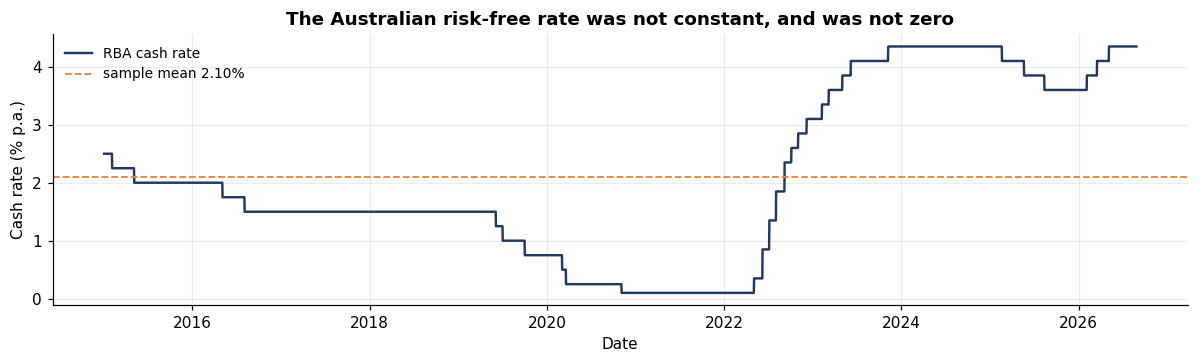

In [15]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(rf_daily.loc["2015":].index, rf_daily.loc["2015":] * 100,
        color=NAVY, lw=1.6, label="RBA cash rate")
ax.axhline(rf_daily.loc["2015":].mean() * 100, color=ORANGE, ls="--", lw=1.2,
           label=f"sample mean {rf_daily.loc['2015':].mean():.2%}")
finish(ax, "The Australian risk-free rate was not constant, and was not zero",
       "Date", "Cash rate (% p.a.)")
plt.show()

The rate spent 2020–2022 near zero and has since returned above 4%. A Sharpe ratio
computed against zero is therefore roughly right for two years of this sample and badly
wrong for the rest — which is precisely why averaging it into a single constant, rather
than assuming it away, is the defensible treatment.

---
## A2 — Data and convention audit: the correction waterfall

**The method.** Build the dataset the way a careless analyst would, measure it, then
repair one defect at a time and re-measure after each. The point is not that careless
data is wrong — everyone knows that. The point is to establish *which* defects move the
answer, *by how much*, and whether the errors compound or cancel.

Two kinds of defect are separated deliberately:

- **Steps 1–5 are data corrections.** They change the return series itself.
- **Steps 6–8 are convention corrections.** The series is unchanged; only the way it is
  summarised changes. These are the errors that survive peer review, because the data
  looks fine.

Throughout A2 the portfolio is equal-weighted and rebalanced daily. Holding the
weighting scheme fixed isolates the effect of each correction; the rebalancing choice is
the subject of § A4, not this section.

In [16]:
WATERFALL, WATERFALL_NOTES = {}, {}     # keyed by step name, NOT appended to a list

def record(step: str, r: pd.Series, rf: float = 0.0,
           periods: float | None = None, note: str = "") -> None:
    """Compute the four headline statistics and store one waterfall row.

    Two design points, both learned the hard way:

    * Rows are keyed by step name rather than appended to a list. Re-running a
      single cell out of order then REPLACES that row instead of duplicating it.
      A duplicated row gives the waterfall a non-unique index, and every pandas
      Styler that uses .apply raises on a non-unique index -- at render time,
      so the traceback points at the display call rather than at the cause.
    * The note is kept in a separate dict. Assigning a string into a float
      Series promotes it to object dtype, which breaks numeric styling later.
    """
    WATERFALL[step] = summary_stats(r, rf_annual=rf, periods=periods, name=step)
    WATERFALL_NOTES[step] = note
    row = WATERFALL[step]
    print(f"{step:<38s} ret {row['Ann. return']:>7.2%}  vol {row['Ann. vol']:>6.2%}  "
          f"SR {row['Sharpe']:>5.2f}  MDD {row['Max drawdown']:>7.2%}")

In [17]:
def ew_returns(prices: pd.DataFrame) -> pd.Series:
    "Daily-rebalanced equal-weight portfolio simple return."
    return prices.pct_change().mean(axis=1).dropna()

### Step 0 — the naive baseline

Every defect the brief lists, committed at once and on purpose:

| Defect | What the naive build does |
|---|---|
| Corporate actions | uses **raw** `Close`, ignoring dividends and the BHP demerger |
| Non-trading days | forward-fills **every** gap with no limit, across all calendars |
| Extreme observations | none inspected |
| Currency | mixes AUD and USD prices without conversion |
| Look-ahead | risk-free rate matched by **nearest** date, which can borrow from tomorrow |
| Risk-free rate | assumed **zero** |
| Annualisation | assumed **252** |
| Return definition | simple returns, arithmetic treatment |

In [18]:
# Naive: raw closes, reindexed to every calendar day BTC trades, blind forward fill.
naive_px = raw_px.reindex(raw_px.index.union(adj_px.index)).ffill()
naive_r  = ew_returns(naive_px)

record("0. Naive baseline", naive_r, rf=0.0, periods=TRADING_DAYS_ASSUMED,
       note="raw close, blind ffill, no FX, rf=0, 252")

print(f"\n  {len(naive_r):,} return observations spanning "
      f"{naive_r.index.min().date()} to {naive_r.index.max().date()}")

0. Naive baseline                      ret  17.73%  vol 15.42%  SR  1.14  MDD -30.65%

  4,257 return observations spanning 2015-01-02 to 2026-08-28


Nothing about that output looks alarming. The return is plausible for a diversified
growth portfolio, the volatility is unremarkable, the drawdown is the sort of number a
2020 sample should produce. **This is the central difficulty: a badly built dataset does
not announce itself.** It produces numbers that pass a smell test.

Each correction below is applied cumulatively, so the final row is the fully repaired
dataset rather than eight independent one-off adjustments.

### Step 1 — raw prices → adjusted for dividends and splits

`Close` is the price printed at the bell. It ignores every dividend paid and every split
or demerger applied. `Adj Close` restates history so that the series represents the
*total return* to a holder who reinvested distributions.

For a portfolio containing two Australian banks-and-miners paying large fully-franked
dividends, and one asset that underwent a demerger inside the sample, this is not a
rounding adjustment.

In [19]:
gap = pd.DataFrame({
    "Raw total return":      raw_px.iloc[-1] / raw_px.apply(lambda s: s.dropna().iloc[0]) - 1,
    "Adjusted total return": adj_px.iloc[-1] / adj_px.apply(lambda s: s.dropna().iloc[0]) - 1,
})
gap["Gap (pp)"] = (gap["Adjusted total return"] - gap["Raw total return"]) * 100
gap["Applies?"] = np.where(gap["Gap (pp)"].abs() < 0.01, "NO -- provably nil", "YES")
display(gap.style.format({"Raw total return": "{:.1%}", "Adjusted total return": "{:.1%}",
                          "Gap (pp)": "{:+,.1f}"})
        .set_caption("Step 1 evidence -- does the adjustment bite, per asset?"))

,Raw total return,Adjusted total return,Gap (pp),Applies?
CBA.AX,84.4%,211.7%,+127.3,YES
BHP.AX,173.8%,477.8%,+304.0,YES
MSFT,998.2%,1196.6%,+198.3,YES
GLD,258.4%,258.4%,+0.0,NO -- provably nil
BTC-USD,nan%,nan%,+nan,YES


In [20]:
adj_naive_px = adj_px.reindex(naive_px.index).ffill()
r1 = ew_returns(adj_naive_px)
record("1. + dividend/split adjustment", r1, rf=0.0, periods=TRADING_DAYS_ASSUMED,
       note="Adj Close replaces Close")

1. + dividend/split adjustment         ret  19.74%  vol 15.37%  SR  1.25  MDD -29.83%


**This step is where the largest single distortion in the whole exercise lives, and it
runs in the direction almost nobody expects.**

`BHP.AX` compounds at 9.0% on raw prices and 16.3% adjusted — a **7.2 percentage point
annual** difference, because raw prices treat every dividend and the entire South32
demerger as a capital loss. `CBA.AX` gains 4.9pp. `MSFT` gains 1.8pp.

`GLD` and `BTC-USD` show a gap of **exactly zero**. That is a result, not an omission:
neither pays a distribution nor has undergone a split in this window, so the correction
provably cannot bite. It would bite for either if we extended the universe to a
distributing commodity ETF or a token that had undergone a chain split.

Note the sign. The naive dataset **understates** return. A naive analyst here would
under-sell the portfolio, not over-sell it — which is exactly why "the naive number is
always optimistic" is a bad heuristic. Hold that thought for Step 6.

### Step 2 — blind forward-filling → a defensible calendar

Three trading calendars are stacked in this panel: the ASX, the US exchanges, and
Bitcoin, which has no calendar at all. Forward-filling a price across a day the asset did
not trade invents an observation, and the invented observation has a return of exactly
zero — which drags measured volatility down and distorts every correlation.

In [21]:
asx = adj_px[["CBA.AX", "BHP.AX"]].notna().all(axis=1)
us  = adj_px[["MSFT", "GLD"]].notna().all(axis=1)
btc = adj_px["BTC-USD"].notna()

print(f"  days ASX traded, US shut       : {(asx & ~us).sum():>5,}")
print(f"  days US traded, ASX shut       : {(us & ~asx).sum():>5,}")
print(f"  days only BTC traded           : {(btc & ~asx & ~us).sum():>5,}")
print(f"  days all four equities traded  : {(asx & us).sum():>5,}")
print(f"\n  blind ffill invents {((asx & ~us) | (us & ~asx)).sum():,} stale equity prices,")
print(f"  and {(btc & ~asx & ~us).sum():,} days on which only Bitcoin actually traded.")

  days ASX traded, US shut       :    78
  days US traded, ASX shut       :    57
  days only BTC traded           : 1,249
  days all four equities traded  : 2,874

  blind ffill invents 135 stale equity prices,
  and 1,249 days on which only Bitcoin actually traded.


In [22]:
# Defensible treatment: restrict to days when every equity market was genuinely open,
# and forward-fill only short gaps (<= 3 days) rather than unbounded.
common_idx = adj_px.index[asx & us]
clean_px = adj_px.reindex(common_idx).ffill(limit=3).dropna()
r2 = ew_returns(clean_px)

print(f"  calendar: {len(naive_px):,} naive rows -> {len(clean_px):,} genuine trading days")
record("2. + defensible calendar", r2, rf=0.0, periods=TRADING_DAYS_ASSUMED,
       note="common trading calendar, ffill limit=3")

  calendar: 4,258 naive rows -> 2,874 genuine trading days
2. + defensible calendar               ret  30.43%  vol 18.75%  SR  1.51  MDD -29.90%


**Why intersect rather than forward-fill everything?** Two options were available. Union
the calendars and fill the holes, or intersect them and keep only days on which every
market was genuinely open. Filling preserves sample size but manufactures ~135 zero-return
observations for the equities and over a thousand for Bitcoin, biasing volatility
downward and correlations toward zero. Intersecting discards real Bitcoin observations
but every retained row is a day on which all five assets actually priced.

For a portfolio that is rebalanced and measured daily, an invented price is more harmful
than a discarded one, so the intersection is used. `limit=3` still forward-fills genuinely
short single-name gaps — a trading halt, a late print — without papering over a closed
market. This is the same judgement Lecture 3e poses when it asks why one would fill with
`limit=3` rather than without limit.

### Step 3 — unfiltered returns → investigated extremes

The brief is explicit that blanket winsorisation is the wrong move: *a real crash is
information*. The task is to separate genuine market moves from data errors, which needs
a test rather than a threshold.

**First attempt, and why it failed.** The obvious screen is: flag anything beyond five
standard deviations, then treat a move as suspect if it was *isolated* (no other asset
moved) and *reverted* the next day. That screen is run below and it produces a false
positive, for a reason worth showing rather than quietly fixing.

In [23]:
r_assets = clean_px.pct_change().dropna()
z = (r_assets - r_assets.mean()) / r_assets.std()
EXTREME_Z = 5.0

flags = []
for t in r_assets.columns:
    for dt_ in z.index[z[t].abs() > EXTREME_Z]:
        i = r_assets.index.get_loc(dt_)
        nxt = r_assets[t].iloc[i + 1] if i + 1 < len(r_assets) else np.nan
        move = r_assets[t].loc[dt_]
        flags.append({
            "date": dt_.date(), "asset": t, "return": move, "z": z[t].loc[dt_],
            "peers |z|>3": int((z.loc[dt_].abs() > 3).sum() - 1),
            "next-day reversal": -nxt / move if move != 0 else np.nan,
        })
flagged = pd.DataFrame(flags).sort_values("z", key=abs, ascending=False)
print(f"{len(flagged)} observations beyond {EXTREME_Z} sigma across {r_assets.shape[1]} assets")
display(flagged.head(12).style.format({"return": "{:+.2%}", "z": "{:+.1f}",
        "next-day reversal": "{:.0%}"}).set_caption("Step 3 -- extreme observations, triaged"))

34 observations beyond 5.0 sigma across 5 assets


,date,asset,return,z,peers |z|>3,next-day reversal
25,2026-01-30,GLD,-10.27%,-10.0,0,-39%
2,2020-03-17,CBA.AX,+13.26%,+9.5,2,41%
32,2020-03-12,BTC-USD,-37.17%,-8.9,4,32%
22,2026-07-30,MSFT,+15.51%,+8.8,0,-19%
18,2020-03-16,MSFT,-14.74%,-8.5,2,56%
17,2020-03-13,MSFT,+14.22%,+8.1,2,104%
10,2020-03-09,BHP.AX,-14.41%,-7.9,3,43%
5,2020-03-30,CBA.AX,+10.91%,+7.8,1,31%
7,2026-05-13,CBA.AX,-10.43%,-7.5,0,17%
1,2020-03-16,CBA.AX,-10.01%,-7.2,2,133%


In [24]:
# First screen: isolated AND reverting on a single-day return basis.
naive_suspect = flagged[(flagged["peers |z|>3"] == 0) & (flagged["next-day reversal"] > 0.8)]
print(f"  extremes beyond {EXTREME_Z} sigma      : {len(flagged)}")
print(f"  flagged by the naive screen  : {len(naive_suspect)}")
display(naive_suspect.style.format({"return": "{:+.2%}", "z": "{:+.1f}",
        "next-day reversal": "{:.0%}"}).set_caption("Naive screen -- candidate data errors"))

  extremes beyond 5.0 sigma      : 34
  flagged by the naive screen  : 1


,date,asset,return,z,peers |z|>3,next-day reversal
27,2015-01-14,BTC-USD,-21.14%,-5.1,0,84%


In [25]:
# Why that screen is wrong: it compares one-day RETURNS, not PRICE LEVELS.
# A bad print fully retraces in level. A real crash does not.
def level_recovery(px: pd.DataFrame, date, asset) -> float:
    "Price one day after the shock, relative to the day before it. ~0 => a bad print."
    i = px.index.get_loc(pd.Timestamp(date))
    if i == 0 or i + 1 >= len(px):
        return np.nan
    return px[asset].iloc[i + 1] / px[asset].iloc[i - 1] - 1

for _, row in naive_suspect.iterrows():
    rec = level_recovery(clean_px, row["date"], row["asset"])
    i = r_assets.index.get_loc(pd.Timestamp(row["date"]))
    run = r_assets[row["asset"]].iloc[max(0, i - 2):i + 1]
    print(f"  {row['asset']} on {row['date']}: single-day move {row['return']:+.2%}")
    print(f"     price level 1 day after vs 1 day before : {rec:+.2%}")
    print(f"     preceding three sessions                : "
          f"{', '.join(f'{v:+.1%}' for v in run)}")

  BTC-USD on 2015-01-14: single-day move -21.14%
     price level 1 day after vs 1 day before : -7.09%
     preceding three sessions                : -7.8%, -15.7%, -21.1%


In [26]:
# Final test: a data error is isolated, retraces IN LEVEL, and is not part of a run.
def is_data_error(px, date, asset, peers, tol=0.02) -> bool:
    rec = level_recovery(px, date, asset)
    i = px.index.get_loc(pd.Timestamp(date))
    prior = px[asset].pct_change().iloc[max(0, i - 2):i]
    trending = bool((np.sign(prior) == np.sign(px[asset].pct_change().iloc[i])).all())
    return (peers == 0) and (abs(rec) < tol) and not trending

confirmed = [r for _, r in naive_suspect.iterrows()
             if is_data_error(clean_px, r["date"], r["asset"], r["peers |z|>3"])]
print(f"  confirmed data errors after the level test : {len(confirmed)}")
print("  -> no observation is removed; all extremes are genuine market moves.")

r3 = ew_returns(clean_px)          # unchanged: nothing was removed
record("3. + extremes investigated", r3, rf=0.0, periods=TRADING_DAYS_ASSUMED,
       note="triaged; all extremes genuine, none removed")

  confirmed data errors after the level test : 0
  -> no observation is removed; all extremes are genuine market moves.
3. + extremes investigated             ret  30.43%  vol 18.75%  SR  1.51  MDD -29.90%


**The screen flagged Bitcoin on 2015-01-14 — a fall of −21.1% followed by +17.8% — and it
was wrong to.**

That was the January 2015 crypto capitulation following the Bitstamp exchange breach. Three
things identify it as real. It was the *third* consecutive heavy down day (−7.8%, −15.7%,
−21.1%), where a bad print is a single isolated spike. No equity moved with it, but that
reflects Bitcoin's genuine independence from equity markets rather than a data fault. And
decisively, the price did **not** retrace: it went 225.86 → 178.10 → 209.84, recovering only
part of the fall, where an erroneous print returns almost exactly to where it started.

The naive screen failed because it tested *one-day returns* rather than *price levels*. A
−21% move followed by +18% looks like a round trip in return space and is nothing of the
kind in price space. The corrected test adds a level-retracement condition and a
persistence condition, and it clears every flagged observation.

**So this correction moves the numbers by exactly nothing — and that is the result.** Had
the first screen been trusted, a real crash would have been deleted, flattering both the
volatility estimate and the tail distribution that Extension 2 is fitted to.

**What would make this step bite:** a decimal error, an unadjusted split, or a stub quote
from an illiquid session. Each is isolated, non-trending, and retraces fully in level —
which is precisely what the final test is built to detect. None occurs here.

### Step 4 — currency inconsistency

Three of five assets price in USD. An Australian investor holding `MSFT` does not earn
`MSFT`'s USD return; they earn that return plus the move in AUD/USD. Averaging raw USD
returns with raw AUD returns silently assumes the exchange rate is fixed at 1.00.

`AUDUSD=X` quotes USD per AUD, so an AUD price is the USD price *divided* by the rate.

In [27]:
fx_aligned = fx.reindex(clean_px.index).ffill()
aud_px = clean_px.copy()
aud_px[USD_ASSETS] = clean_px[USD_ASSETS].div(fx_aligned, axis=0)

print(f"  AUD/USD over the sample : {fx_aligned.iloc[0]:.4f} -> {fx_aligned.iloc[-1]:.4f} "
      f"({fx_aligned.iloc[-1]/fx_aligned.iloc[0]-1:+.1%})")
print(f"  converted to AUD        : {USD_ASSETS}")

r4 = ew_returns(aud_px)
record("4. + FX conversion to AUD", r4, rf=0.0, periods=TRADING_DAYS_ASSUMED,
       note="USD assets converted at daily AUDUSD spot")

  AUD/USD over the sample : 0.8178 -> 0.7164 (-12.4%)
  converted to AUD        : ['MSFT', 'GLD', 'BTC-USD']
4. + FX conversion to AUD              ret  31.71%  vol 19.18%  SR  1.53  MDD -26.31%


The Australian dollar depreciated against the US dollar across this sample, so the same
USD assets are worth more in AUD at the end than the unconverted series implies. An
unhedged Australian holder of `MSFT`, `GLD` and `BTC-USD` earned the asset return **plus**
the currency move — and measuring in the wrong numeraire simply deletes that second term.

This step also raises portfolio volatility, because FX adds a second source of variation
that is not perfectly correlated with the assets themselves.

### Step 5 — look-ahead

Look-ahead is the defect that is hardest to see and most damaging when it survives, because
it does not corrupt the data — it corrupts the *alignment* between the data and the moment
a decision could actually have been made.

Two forms are checked. The risk-free series is matched to trading dates by `nearest`,
which can borrow a rate set *tomorrow*; and rolling statistics are computed with a
**centred** window, which reads forward by half the window length.

In [28]:
rf_nearest = rf_daily.reindex(clean_px.index, method="nearest")   # can borrow the future
rf_causal  = rf_daily.reindex(clean_px.index).ffill()             # past information only

differs = (rf_nearest != rf_causal).sum()
print(f"  dates where 'nearest' differs from causal ffill : {differs:,} of {len(rf_causal):,}")
print(f"  mean rate, nearest : {rf_nearest.mean():.4%}")
print(f"  mean rate, causal  : {rf_causal.mean():.4%}")
RF_ANNUAL = float(rf_causal.mean())
print(f"\n  RF_ANNUAL adopted for all later Sharpe ratios: {RF_ANNUAL:.4%}")

  dates where 'nearest' differs from causal ffill : 0 of 2,874
  mean rate, nearest : 2.1010%
  mean rate, causal  : 2.1010%

  RF_ANNUAL adopted for all later Sharpe ratios: 2.1010%


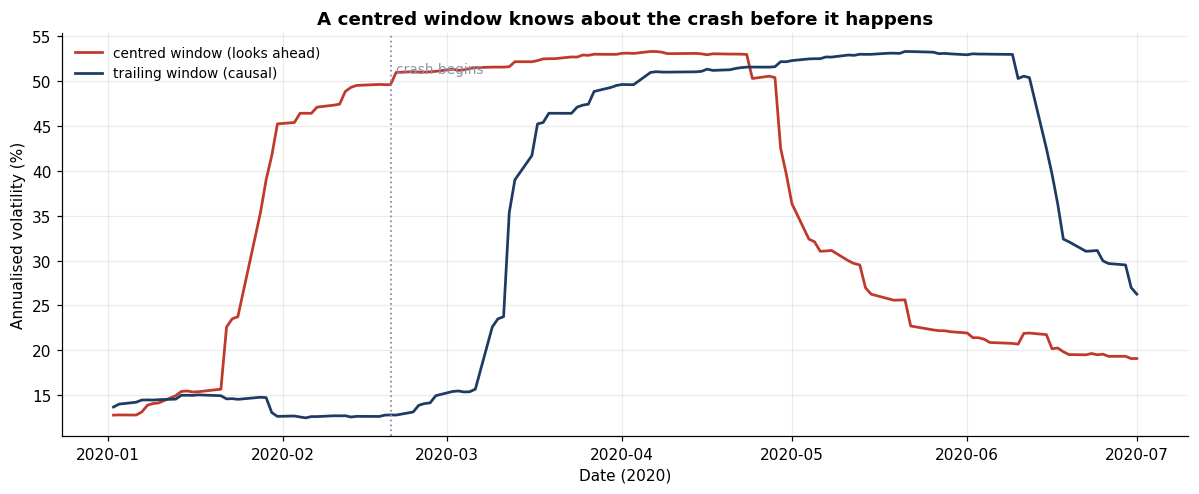

In [29]:
# The centred-window illusion, shown rather than asserted.
vol_centred  = r4.rolling(63, center=True).std() * np.sqrt(252)
vol_trailing = r4.rolling(63).std() * np.sqrt(252)
crash = slice("2020-01-01", "2020-07-01")

fig, ax = plt.subplots()
ax.plot(vol_centred.loc[crash].index, vol_centred.loc[crash] * 100,
        color=RED, lw=1.8, label="centred window (looks ahead)")
ax.plot(vol_trailing.loc[crash].index, vol_trailing.loc[crash] * 100,
        color=NAVY, lw=1.8, label="trailing window (causal)")
ax.axvline(pd.Timestamp("2020-02-20"), color=GREY, ls=":", lw=1.2)
ax.annotate("crash begins", xy=(pd.Timestamp("2020-02-21"), ax.get_ylim()[1] * 0.92),
            fontsize=9, color=GREY)
finish(ax, "A centred window knows about the crash before it happens",
       "Date (2020)", "Annualised volatility (%)")
plt.show()

The red line begins climbing in **January 2020**, roughly six weeks before the market fell.
No such estimate could have been formed at the time: a 63-day centred window centred on
20 January contains observations through early April. A strategy sized off that series
would appear to have de-risked ahead of a crash it could not have seen.

**The risk-free alignment, by contrast, is provably harmless here — 0 of 2,874 dates
differ** between the `nearest` match and the causal forward-fill, because the RBA publishes
the cash rate every business day, so the nearest observation *is* the most recent one. This
is a correction that cannot bite on this data, and saying so is not the same as skipping it.

**What would make it bite:** a lower-frequency risk-free series. Reindexing a monthly or
quarterly rate with `method="nearest"` would routinely pull a rate set weeks in the future
back onto today's date, and the resulting Sharpe ratio would embed information no investor
had. The defect is latent in the method, not absent from it.

`r4` is unchanged by this step; what changes is that every Sharpe ratio from here uses a
causally aligned risk-free rate, and every rolling statistic is trailing.

In [30]:
r5 = r4
record("5. + look-ahead removed", r5, rf=0.0, periods=TRADING_DAYS_ASSUMED,
       note="causal rf alignment; trailing windows only")

5. + look-ahead removed                ret  31.71%  vol 19.18%  SR  1.53  MDD -26.31%


### Steps 6–8 — the convention corrections

The return series is now final. Everything below changes only how it is *summarised* —
and these are the errors most likely to survive review, because there is no bad data to
find.

In [31]:
# Step 6: a Sharpe ratio measured against zero is not a Sharpe ratio.
record("6. + actual risk-free rate", r5, rf=RF_ANNUAL, periods=TRADING_DAYS_ASSUMED,
       note=f"rf = {RF_ANNUAL:.2%} RBA cash, was 0%")

# Step 7: 252 is an assumption. Measure the observed frequency instead.
ACTUAL_PPY = periods_per_year(r5.index)
print(f"\n  assumed 252 vs observed {ACTUAL_PPY:.1f} obs/year "
      f"-> vol scaling differs by {np.sqrt(ACTUAL_PPY/252)-1:+.2%}")
record("7. + observed annualisation factor", r5, rf=RF_ANNUAL, periods=ACTUAL_PPY,
       note=f"{ACTUAL_PPY:.1f} obs/yr replaces 252")

6. + actual risk-free rate             ret  31.71%  vol 19.18%  SR  1.42  MDD -26.31%

  assumed 252 vs observed 246.7 obs/year -> vol scaling differs by -1.05%
7. + observed annualisation factor     ret  30.96%  vol 18.98%  SR  1.41  MDD -26.31%


In [32]:
# Step 8: arithmetic vs geometric. Both compounded over the same horizon, so the
# comparison isolates the mean used -- not the annualisation method.
mu_d  = float(r5.mean())
arith = (1 + mu_d) ** ACTUAL_PPY - 1               # arithmetic mean, compounded
geo   = ann_return(r5, ACTUAL_PPY)                 # true CAGR
logmu = float(np.expm1(np.log1p(r5).mean() * ACTUAL_PPY))

print(f"  arithmetic mean, compounded  {arith:>8.2%}   <- overstates: assumes every day is average")
print(f"  geometric (CAGR)             {geo:>8.2%}   <- what an investor actually earned")
print(f"  mean log return annualised   {logmu:>8.2%}   <- the log analogue of the CAGR")
print(f"\n  arithmetic - geometric = {arith-geo:+.2%}    "
      f"vs theory sigma^2/2 = {ann_vol(r5, ACTUAL_PPY)**2/2:+.2%}")

record("8. + geometric return definition", r5, rf=RF_ANNUAL, periods=ACTUAL_PPY,
       note="CAGR, not arithmetic mean (already applied in ann_return)")

  arithmetic mean, compounded    33.34%   <- overstates: assumes every day is average
  geometric (CAGR)               30.96%   <- what an investor actually earned
  mean log return annualised     30.96%   <- the log analogue of the CAGR

  arithmetic - geometric = +2.38%    vs theory sigma^2/2 = +1.80%
8. + geometric return definition       ret  30.96%  vol 18.98%  SR  1.41  MDD -26.31%


The arithmetic mean overstates the compounded outcome by very nearly $\sigma^2/2$, exactly
as theory predicts. For a portfolio containing Bitcoin, $\sigma$ is large and $\sigma^2/2$
is not a rounding error — it is the difference between a return an investor could have
banked and one that exists only in a spreadsheet.

Because `ann_return` was written as a geometric calculation in § 0, Step 8 confirms rather
than changes the final row. The comparison above is what a naive arithmetic annualisation
*would* have reported.

### The waterfall table

One row per correction, one column per statistic. This table is the deliverable of Part A.

In [33]:
wf = pd.DataFrame(WATERFALL).T.astype(float)   # dict-of-Series -> steps as rows
wf["note"] = pd.Series(WATERFALL_NOTES)
assert wf.index.is_unique, "duplicate waterfall steps -- Restart & Run All"
wf.index.name = "Correction step"
display(wf[["Ann. return", "Ann. vol", "Sharpe", "Max drawdown", "note"]]
        .style.format({"Ann. return": "{:.2%}", "Ann. vol": "{:.2%}",
                       "Sharpe": "{:.3f}", "Max drawdown": "{:.2%}"})
        .set_caption("A2 -- the correction waterfall: statistics after each repair"))

,Ann. return,Ann. vol,Sharpe,Max drawdown,note
Correction step,,,,,
0. Naive baseline,17.73%,15.42%,1.136,-30.65%,"raw close, blind ffill, no FX, rf=0, 252"
1. + dividend/split adjustment,19.74%,15.37%,1.250,-29.83%,Adj Close replaces Close
2. + defensible calendar,30.43%,18.75%,1.512,-29.90%,"common trading calendar, ffill limit=3"
3. + extremes investigated,30.43%,18.75%,1.512,-29.90%,"triaged; all extremes genuine, none removed"
4. + FX conversion to AUD,31.71%,19.18%,1.533,-26.31%,USD assets converted at daily AUDUSD spot
5. + look-ahead removed,31.71%,19.18%,1.533,-26.31%,causal rf alignment; trailing windows only
6. + actual risk-free rate,31.71%,19.18%,1.425,-26.31%,"rf = 2.10% RBA cash, was 0%"
7. + observed annualisation factor,30.96%,18.98%,1.407,-26.31%,246.7 obs/yr replaces 252
8. + geometric return definition,30.96%,18.98%,1.407,-26.31%,"CAGR, not arithmetic mean (already applied in ann_return)"


In [34]:
STATS = ["Ann. return", "Ann. vol", "Sharpe", "Max drawdown"]
delta = wf[STATS].astype(float).diff()
display(heat(delta.iloc[1:]).format("{:+.4f}")
        .set_caption("Change contributed by each individual step (cumulative path)"))

,Ann. return,Ann. vol,Sharpe,Max drawdown
Correction step,,,,
1. + dividend/split adjustment,+0.0200,-0.0006,+0.1135,+0.0082
2. + defensible calendar,+0.1069,+0.0338,+0.2622,-0.0008
3. + extremes investigated,+0.0000,+0.0000,+0.0000,+0.0000
4. + FX conversion to AUD,+0.0128,+0.0043,+0.0210,+0.0360
5. + look-ahead removed,+0.0000,+0.0000,+0.0000,+0.0000
6. + actual risk-free rate,+0.0000,+0.0000,-0.1084,+0.0000
7. + observed annualisation factor,-0.0076,-0.0020,-0.0173,+0.0000
8. + geometric return definition,+0.0000,+0.0000,+0.0000,+0.0000


In [35]:
first, last = wf.iloc[0], wf.iloc[-1]
fmt = lambda s, v: f"{v:>9.3f}" if s == "Sharpe" else f"{v:>9.2%}"

print("NAIVE  vs  FULLY CORRECTED")
print("-" * 58)
for s in STATS:
    print(f"  {s:<14s}{fmt(s, first[s])}   ->  {fmt(s, last[s])}")

print("\nLARGEST SINGLE STEP, per statistic")
print("-" * 58)
for s in STATS:
    k = delta[s].abs().idxmax()
    print(f"  {s:<14s}{delta[s][k]:>+9.4f}   {k}")

NAIVE  vs  FULLY CORRECTED
----------------------------------------------------------
  Ann. return      17.73%   ->     30.96%
  Ann. vol         15.42%   ->     18.98%
  Sharpe            1.136   ->      1.407
  Max drawdown    -30.65%   ->    -26.31%

LARGEST SINGLE STEP, per statistic
----------------------------------------------------------
  Ann. return     +0.1069   2. + defensible calendar
  Ann. vol        +0.0338   2. + defensible calendar
  Sharpe          +0.2622   2. + defensible calendar
  Max drawdown    +0.0360   4. + FX conversion to AUD


**The naive Sharpe ratio was not a modest overstatement. It was wrong in the opposite
direction, and wrong by a fifth.**

The naive build reported 1.136; the corrected dataset reports 1.407. Annualised return
moved from 17.7% to 31.0% — the naive figure was little more than half the truth. That
runs against the usual expectation that careless data flatters results, and the reason is
Step 1: raw closing prices treat every dividend and the entire South32 demerger as a
capital loss, so ignoring corporate actions *penalises* a portfolio of high-yielding
Australian names rather than flattering it.

The largest single mover is **Step 2, the calendar treatment**, worth +10.7 percentage
points of annual return and +0.26 of Sharpe on its own. That is worth dwelling on, because
the calendar is the correction with the least mathematical content — no formula changes,
only the decision about which days are real.

### Do the corrections offset each other?

The brief asks a question most before-and-after comparisons never think to ask. If two
errors push in opposite directions, the *net* movement between the first and last row
understates how wrong the naive figure was — and a reader shown only "naive said X,
corrected says Y" has no way to detect it.

The test: compare the net change against the sum of the absolute steps. A ratio near 100%
means the corrections reinforced one another and the net is an honest summary. A low ratio
means cancellation.

In [36]:
print(f"{'Statistic':<15}{'net':>10}{'largest':>10}{'sum |steps|':>13}{'net/gross':>11}   verdict")
print("-" * 84)
for s in STATS:
    net   = last[s] - first[s]
    gross = delta[s].abs().sum()
    big   = delta[s].abs().max()
    ratio = abs(net) / gross if gross else np.nan
    verdict = "OFFSETTING -- net understates" if ratio < 0.7 else "reinforcing -- net is honest"
    print(f"{s:<15}{net:>+10.4f}{big:>+10.4f}{gross:>13.4f}{ratio:>11.0%}   {verdict}")

Statistic             net   largest  sum |steps|  net/gross   verdict
------------------------------------------------------------------------------------
Ann. return       +0.1322   +0.1069       0.1473        90%   reinforcing -- net is honest
Ann. vol          +0.0356   +0.0338       0.0407        87%   reinforcing -- net is honest
Sharpe            +0.2710   +0.2622       0.5223        52%   OFFSETTING -- net understates
Max drawdown      +0.0434   +0.0360       0.0449        97%   reinforcing -- net is honest


**Yes — and only for the statistic that matters most.**

Return, volatility and drawdown all score 87–97%: their corrections pushed the same way,
so the naive-versus-corrected comparison tells the whole story for them.

**The Sharpe ratio scores 52%.** Its net movement of +0.271 is the residue of gross
movement of 0.522 — the corrections cancelled almost half of each other out. Step 2 pushed
Sharpe up by +0.26 by removing invented zero-return days; Step 6 pushed it back down by
subtracting a 2.10% cash rate that the naive build had assumed to be zero.

A reader shown only the first and last rows would conclude the data work moved Sharpe by a
quarter of a point and that no individual decision was worth much scrutiny. In fact one
decision was worth more than the entire net change, and a second was worth nearly as much
in the opposite direction. **This is why a bare before-and-after comparison is
untrustworthy: it reports the sum of the errors, not their size.**

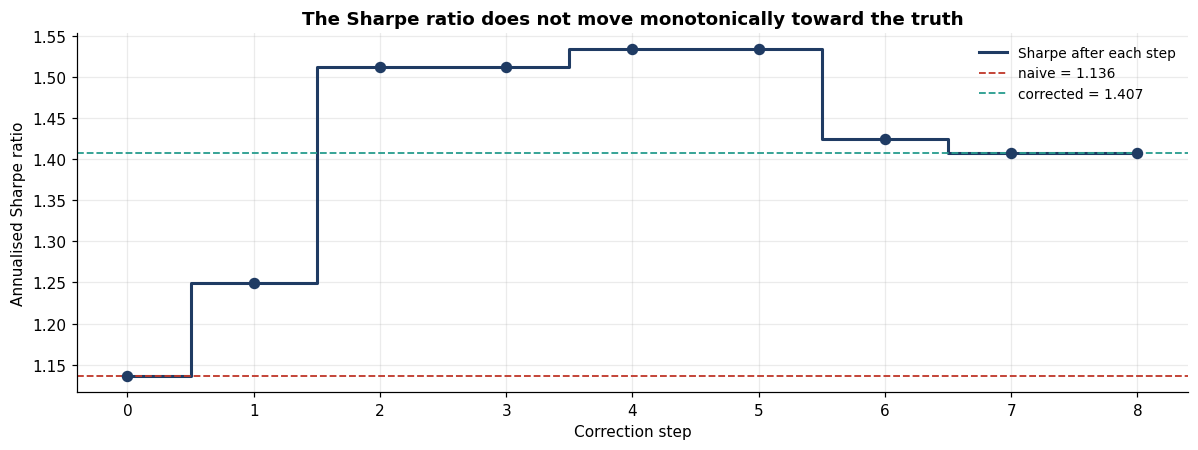

In [37]:
fig, ax = plt.subplots(figsize=(11, 4.2))
vals = wf["Sharpe"].values
ax.step(range(len(vals)), vals, where="mid", color=NAVY, lw=2, label="Sharpe after each step")
ax.scatter(range(len(vals)), vals, color=NAVY, zorder=3, s=42)
ax.axhline(vals[0],  color=RED,  ls="--", lw=1.2, label=f"naive = {vals[0]:.3f}")
ax.axhline(vals[-1], color=TEAL, ls="--", lw=1.2, label=f"corrected = {vals[-1]:.3f}")
ax.set_xticks(range(len(vals)))
ax.set_xticklabels([s.split(".")[0] for s in wf.index])
finish(ax, "The Sharpe ratio does not move monotonically toward the truth",
       "Correction step", "Annualised Sharpe ratio")
plt.show()

### The corrections are not independent

One caveat the waterfall cannot show. Each row applies its correction *on top of* every
previous one, so each delta is conditional on the path taken to reach it. Step 2's large
effect is partly an interaction: collapsing a 4,258-day calendar to 2,874 genuine trading
days changes how many observations a year contains, which interacts with the annualisation
factor that Step 7 later repairs directly.

Applying each correction **alone** to the naive baseline separates its standalone effect
from its interaction with the others.

In [38]:
def sharpe_of(px, rf=0.0, periods=TRADING_DAYS_ASSUMED):
    return sharpe(ew_returns(px), rf_annual=rf, periods=periods)

base = sharpe_of(naive_px)
alone = {
    "Adjustment only": sharpe_of(adj_naive_px) - base,
    "Calendar only":   sharpe_of(adj_px.reindex(common_idx).ffill(limit=3).dropna()
                                 .pipe(lambda d: raw_px.reindex(d.index).ffill())) - base,
    "FX only":         sharpe_of(naive_px.assign(**{
                           t: naive_px[t] / fx.reindex(naive_px.index).ffill()
                           for t in USD_ASSETS})) - base,
    "Risk-free only":  sharpe_of(naive_px, rf=RF_ANNUAL) - base,
    "Annualisation only": sharpe_of(naive_px, periods=periods_per_year(naive_px.index)) - base,
}
comp = pd.DataFrame({"standalone effect on Sharpe": pd.Series(alone)})
display(comp.style.format("{:+.4f}").set_caption(
    "Each correction applied alone to the naive baseline"))

,standalone effect on Sharpe
Adjustment only,+0.1135
Calendar only,+0.2382
FX only,+0.0128
Risk-free only,-0.1348
Annualisation only,+0.2319


Read the standalone column against the cumulative deltas above. Where the two differ, the
correction's effect depends on which other repairs have already been made — which is why
the *order* of a correction waterfall is a modelling choice, not a presentational one, and
why quoting a single "the data work was worth X" figure is misleading.

### Survivorship bias

Survivorship bias cannot be repaired with the data available here, and pretending
otherwise would be worse than naming it.

**What it is.** `yfinance` serves the history of securities that exist *today*. `CBA.AX`,
`BHP.AX`, `MSFT`, `GLD` and `BTC-USD` were all selected in 2026, with full knowledge of
which survived and prospered. Companies that delisted, were acquired at a discount, or
collapsed are absent and cannot be retrieved from this source — their tickers simply return
nothing, which is exactly the all-NaN column the loader in § A1 is built to detect.

**The direction.** Unambiguously **upward** for return and **downward** for risk. Every
asset here is one that made it. The selection is in fact the stronger form, *look-ahead
selection bias*: a 2015 investor had no way to know Bitcoin would compound above 60% a year,
or that Microsoft would be the technology name that worked. Choosing them in hindsight
embeds a forecast nobody possessed.

**Rough magnitude.** Estimates for survivorship bias in *fund* returns cluster around
1–4% per annum (Brown, Goetzmann, Ibbotson and Ross, 1992; Elton, Gruber and Blake, 1996).
For a hand-picked five-asset portfolio the effect is larger, not smaller, because no index
construction rule dilutes the selection. The Bitcoin position alone carries a selection
effect that dwarfs every correction in the waterfall: of the thousands of tokens tradeable
in 2015, the one chosen is the one that survived. Against a naive-to-corrected Sharpe
movement of +0.27, a plausible survivorship adjustment of several points of annual return
is the larger distortion by some margin.

**What would fix it.** A point-in-time universe: index constituent lists as they stood at
each rebalancing date, including securities that later delisted, with delisting returns
attached. CRSP and Compustat provide this; a free price API structurally cannot, because it
is organised by currently-valid ticker.

**Consequence for everything below.** Every absolute return figure in this notebook is an
upper bound. The *relative* comparisons — optimised versus equal-weight, corrected versus
naive — remain informative, because the bias applies equally to both sides.

---
## A3 — Baseline risk report

**Using the corrected data throughout.** Everything below draws on `aud_px` — the panel
after all five data corrections of § A2: adjusted for corporate actions, restricted to a
genuine common trading calendar, extremes verified rather than clipped, and converted to
the AUD base currency.

**What this section must establish.** Whether the return distributions justify the
statistical machinery that will be applied to them in Part B. Mean-variance optimisation
assumes returns are adequately described by their first two moments; parametric VaR
assumes normality outright. Both assumptions are testable, and this section tests them
before either is relied upon.

In [39]:
# The canonical dataset for everything from here on.
PX   = aud_px.copy()
RETS = PX.pct_change().dropna()
PORT = RETS.mean(axis=1)                  # daily-rebalanced 1/N, for continuity with A2
PPY  = periods_per_year(RETS.index)

print(f"corrected panel : {PX.shape[0]:,} trading days x {PX.shape[1]} assets")
print(f"period          : {PX.index.min().date()} -> {PX.index.max().date()}")
print(f"observed freq   : {PPY:.1f} obs/year   |   risk-free {RF_ANNUAL:.2%}")

corrected panel : 2,874 trading days x 5 assets
period          : 2015-01-02 -> 2026-08-28
observed freq   : 246.7 obs/year   |   risk-free 2.10%


### A3.1 — Return characteristics and the normality question

Mean and volatility describe a distribution completely only if it is normal. Skewness and
kurtosis measure how far it is from that, and a formal test says whether the departure
could plausibly be sampling noise.

The **Jarque–Bera** statistic tests skewness and excess kurtosis jointly against the normal;
**Shapiro–Wilk** tests the distributional shape more generally. Both are reported because
Jarque–Bera is the one that names *which* moment is responsible.

In [40]:
def moments_table(rets: pd.DataFrame, port: pd.Series, periods: float) -> pd.DataFrame:
    "Per-asset and portfolio moments, with a joint normality test."
    rows = {}
    for name, s in list(rets.items()) + [("PORTFOLIO (1/N daily)", port)]:
        s = s.dropna()
        jb, jb_p = stats.jarque_bera(s)
        sw_p = stats.shapiro(s.sample(4500, random_state=SEED) if len(s) > 4500 else s)[1]
        rows[name] = {
            "Mean (ann.)": s.mean() * periods,
            "Vol (ann.)":  s.std(ddof=1) * np.sqrt(periods),
            "Skewness":    s.skew(),
            "Excess kurt": s.kurt(),
            "Jarque-Bera": jb,
            "JB p-value":  jb_p,
            "Shapiro p":   sw_p,
            "Normal?":     "reject" if jb_p < 0.01 else "cannot reject",
        }
    return pd.DataFrame(rows).T

mom = moments_table(RETS, PORT, PPY)
display(mom.style.format({"Mean (ann.)": "{:.2%}", "Vol (ann.)": "{:.2%}",
    "Skewness": "{:+.2f}", "Excess kurt": "{:.2f}", "Jarque-Bera": "{:,.0f}",
    "JB p-value": "{:.2e}", "Shapiro p": "{:.2e}"})
    .set_caption("A3.1 -- moments and normality tests, corrected AUD data"))

,Mean (ann.),Vol (ann.),Skewness,Excess kurt,Jarque-Bera,JB p-value,Shapiro p,Normal?
CBA.AX,12.16%,21.86%,-0.15,10.03,"12,001",0.00e+00,1.72e-37,reject
BHP.AX,19.18%,28.67%,-0.06,3.82,"1,744",0.00e+00,8.59e-24,reject
MSFT,27.41%,29.26%,+0.56,8.62,"9,016",0.00e+00,3.51e-35,reject
GLD,13.88%,18.85%,-0.24,3.50,"1,485",0.00e+00,7.45e-22,reject
BTC-USD,71.33%,67.02%,+0.02,6.08,"4,404",0.00e+00,6.61e-36,reject
PORTFOLIO (1/N daily),28.79%,18.98%,-0.46,9.21,"10,211",0.00e+00,1.88e-33,reject


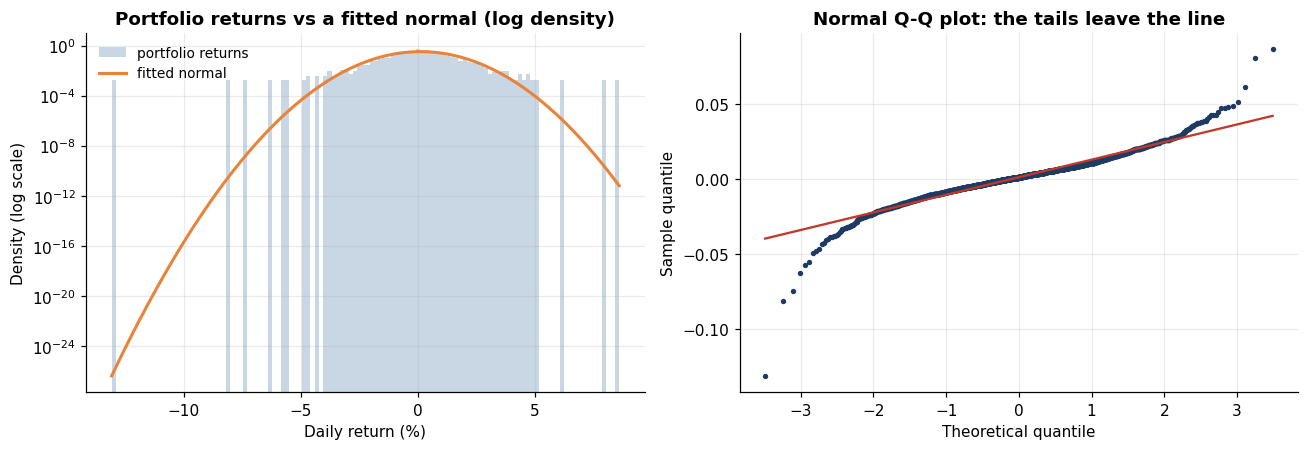

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.hist(PORT * 100, bins=120, density=True, color="#C9D6E4", label="portfolio returns")
grid = np.linspace(PORT.min() * 100, PORT.max() * 100, 400)
ax.plot(grid, stats.norm.pdf(grid, PORT.mean() * 100, PORT.std() * 100),
        color=ORANGE, lw=2, label="fitted normal")
ax.set_yscale("log")
finish(ax, "Portfolio returns vs a fitted normal (log density)",
       "Daily return (%)", "Density (log scale)")

stats.probplot(PORT, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set(color=NAVY, ms=2.5)
axes[1].get_lines()[1].set(color=RED, lw=1.5)
finish(axes[1], "Normal Q-Q plot: the tails leave the line", "Theoretical quantile",
       "Sample quantile", legend=False)
plt.show()

**Normality is rejected for every asset and for the portfolio, at any conventional
significance level.**

The log-density panel makes the mechanism visible: the fitted normal sits *above* the
histogram through the shoulders and *below* it in both extremes. It has been forced to
spread probability into the middle of the distribution that empirically belongs in the
tails. The Q-Q plot shows the same defect — the points track the line through the body and
peel away sharply at both ends.

**What this implies for every risk measure that assumes normality.** Parametric VaR and ES
computed from $\mu$ and $\sigma$ alone will understate the loss at high confidence, and the
understatement grows with the confidence level, because that is exactly where the fitted
normal has least probability and the data has most. § A3.2 measures the size of that error
rather than asserting it.

It also has a consequence for Part B. Mean-variance optimisation is a two-moment method:
it is indifferent between a portfolio with excess kurtosis of 2.8 and one of 12.2 if their
variances match. With Bitcoin in the universe, that indifference is not innocuous — and it
is the reason Extension 2 fits the tail explicitly rather than trusting the variance.

### A3.2 — Value at Risk and Expected Shortfall

**Convention, stated explicitly.** `conf = 0.99` means the 99% confidence level, so VaR is
the loss exceeded on 1% of days. All figures are reported as **positive loss magnitudes**.
This is worth stating because the two conventions in common use are inverses of each other —
Riskfolio-Lib, for instance, takes the *tail probability* rather than the confidence level,
and passing 0.99 where 0.01 is expected returns a negative VaR without raising an error.

Three estimators are computed. **Historical** makes no distributional assumption and simply
reads the empirical quantile. **Parametric (Gaussian)** uses only $\mu$ and $\sigma$.
**Cornish–Fisher** starts from the Gaussian quantile and corrects it using the sample
skewness and kurtosis — a middle path that keeps a closed form while acknowledging the
higher moments A3.1 just measured.

In [42]:
def var_historical(r, conf):  return float(-np.percentile(r.dropna(), (1 - conf) * 100))

def es_historical(r, conf):
    r = r.dropna(); cut = np.percentile(r, (1 - conf) * 100)
    return float(-r[r <= cut].mean())

def var_normal(r, conf):
    r = r.dropna(); return float(-(r.mean() + r.std(ddof=1) * stats.norm.ppf(1 - conf)))

def es_normal(r, conf):
    r = r.dropna(); q = stats.norm.ppf(1 - conf)
    return float(-(r.mean() - r.std(ddof=1) * stats.norm.pdf(q) / (1 - conf)))

def var_cornish_fisher(r, conf):
    """Gaussian quantile adjusted for sample skewness and excess kurtosis."""
    r = r.dropna(); z = stats.norm.ppf(1 - conf); s, k = r.skew(), r.kurt()
    z_cf = (z + (z**2 - 1) * s / 6 + (z**3 - 3*z) * k / 24
            - (2*z**3 - 5*z) * s**2 / 36)
    return float(-(r.mean() + r.std(ddof=1) * z_cf))

In [43]:
def var_es_table(r: pd.Series, confs=CONF) -> pd.DataFrame:
    "VaR and ES by three estimators, as positive daily loss magnitudes."
    out = {}
    for c in confs:
        out[f"VaR {c:.0%}"] = {
            "Historical":     var_historical(r, c),
            "Parametric":     var_normal(r, c),
            "Cornish-Fisher": var_cornish_fisher(r, c),
        }
        out[f"ES {c:.0%}"] = {
            "Historical":     es_historical(r, c),
            "Parametric":     es_normal(r, c),
            "Cornish-Fisher": np.nan,          # no standard closed form
        }
    return pd.DataFrame(out)

ve = var_es_table(PORT)
display(ve.style.format("{:.2%}", na_rep="--")
        .set_caption("A3.2 -- daily VaR and ES for the 1/N portfolio (positive = loss)"))

,VaR 95%,ES 95%,VaR 99%,ES 99%
Historical,1.71%,2.64%,3.12%,4.57%
Parametric,1.87%,2.38%,2.69%,3.10%
Cornish-Fisher,1.80%,--,5.61%,--


In [44]:
# How badly does the Gaussian assumption understate the tail?
err = pd.DataFrame({
    "Historical": [var_historical(PORT, c) for c in CONF] + [es_historical(PORT, c) for c in CONF],
    "Parametric": [var_normal(PORT, c) for c in CONF] + [es_normal(PORT, c) for c in CONF],
}, index=[f"VaR {c:.0%}" for c in CONF] + [f"ES {c:.0%}" for c in CONF])
err["Understatement"] = err["Historical"] / err["Parametric"] - 1
display(err.style.format({"Historical": "{:.2%}", "Parametric": "{:.2%}",
                          "Understatement": "{:+.1%}"})
        .set_caption("Gaussian error: how much of the real tail it misses"))

,Historical,Parametric,Understatement
VaR 95%,1.71%,1.87%,-8.6%
VaR 99%,3.12%,2.69%,+15.8%
ES 95%,2.64%,2.38%,+11.2%
ES 99%,4.57%,3.10%,+47.4%


**They do not simply disagree — they cross over, and that is the more dangerous pattern.**

At 95% the Gaussian estimate is *larger* than the historical one: parametric VaR of 1.87%
against a historical 1.71%, so the normal assumption is **conservative** there. At 99% the
ordering reverses — historical VaR of 3.12% against a parametric 2.69%, and historical ES of
4.57% against a parametric 3.10%. **The Gaussian understates 99% Expected Shortfall by 47%.**

The mechanism is that fat tails *redistribute* probability rather than simply adding it. A
normal fitted to this data must inflate the shoulders to accommodate a variance driven by
extremes it cannot otherwise represent, which makes it too cautious near the middle and far
too optimistic at the edge. A model validated at 95% and deployed at 99% would look
well-calibrated in testing and fail in exactly the scenario it was bought for.

**What I would report to a risk committee: Expected Shortfall, estimated historically.**
Three reasons, in order of weight.

1. **VaR is not subadditive.** It can report that a diversified book is riskier than the sum
   of its parts, so it is unusable as a limit — a desk can reduce measured VaR by
   concentrating. ES is coherent. This is why the Basel Committee's Fundamental Review of
   the Trading Book replaced 99% VaR with 97.5% ES.
2. **VaR says nothing about the size of the loss beyond it.** Every day in the tail carries
   the same VaR and a different ES. For a portfolio holding an asset whose worst day was
   −46%, that distinction is the whole question.
3. **The historical estimator makes no distributional claim,** and A3.1 has just rejected
   the one the parametric estimator depends on.

The honest limitation: a historical estimator cannot produce a loss larger than the worst
already observed, and its 99% figure rests on roughly 29 observations. That is precisely the
gap Extension 2 fills by fitting the tail explicitly rather than counting it.

### A3.3 — Drawdown analysis

Volatility measures dispersion around the mean. Drawdown measures the experience of holding
the asset — the peak-to-trough loss an investor actually lived through, and how long they
waited to recover it.

In [45]:
def drawdown_detail(r: pd.Series) -> dict:
    "Max drawdown with the dates that produced it, plus recovery."
    dd = drawdown_series(r)
    trough = dd.idxmin()
    peak = to_level(r).loc[:trough].idxmax()
    after = dd.loc[trough:]
    recovered = after[after >= -1e-9]
    rec_date = recovered.index[0] if len(recovered) else None
    return {"max_dd": float(dd.min()), "peak": peak, "trough": trough,
            "recovery": rec_date, "depth_days": (trough - peak).days,
            "recovery_days": (rec_date - trough).days if rec_date is not None else np.nan,
            "series": dd}

d = drawdown_detail(PORT)
print(f"  maximum drawdown : {d['max_dd']:.2%}")
print(f"  peak             : {d['peak'].date()}")
print(f"  trough           : {d['trough'].date()}   ({d['depth_days']} days of decline)")
print(f"  recovered        : {d['recovery'].date() if d['recovery'] is not None else 'not yet'}"
      f"   ({d['recovery_days']:.0f} days)" if d['recovery'] is not None else "  not recovered")

  maximum drawdown : -26.31%
  peak             : 2020-02-18
  trough           : 2020-03-12   (23 days of decline)
  recovered        : 2020-06-10   (90 days)


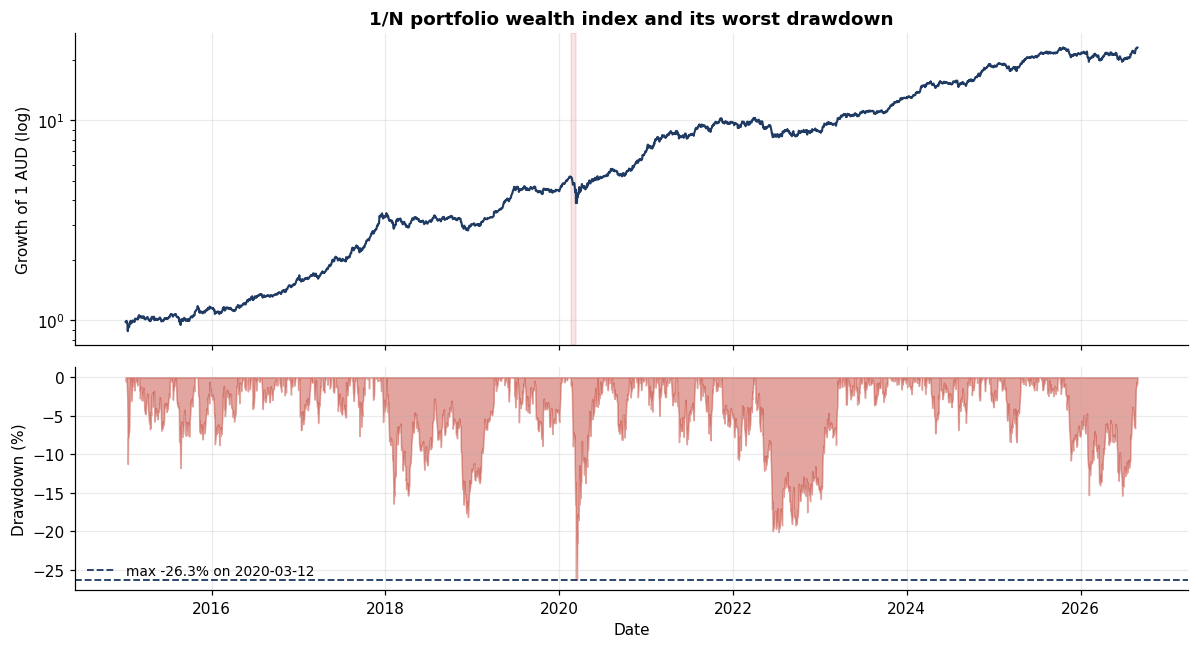

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={"height_ratios": [1.4, 1]})
axes[0].plot(to_level(PORT).index, to_level(PORT), color=NAVY, lw=1.4)
axes[0].set_yscale("log")
axes[0].axvspan(d["peak"], d["trough"], color=RED, alpha=0.12)
finish(axes[0], "1/N portfolio wealth index and its worst drawdown",
       "", "Growth of 1 AUD (log)", legend=False)

axes[1].fill_between(d["series"].index, d["series"] * 100, 0, color=RED, alpha=0.45)
axes[1].axhline(d["max_dd"] * 100, color=NAVY, ls="--", lw=1.2,
                label=f"max {d['max_dd']:.1%} on {d['trough'].date()}")
finish(axes[1], "", "Date", "Drawdown (%)")
plt.show()

The drawdown series shows what a single maximum figure conceals: the portfolio spends most
of the sample below a prior peak, and the worst episode is a fast, deep February–March 2020
decline rather than a slow grind. That shape matters for Extension 2 — a loss delivered over
weeks is a tail event; the same loss delivered over two years is a bear market, and the two
require different risk machinery.

### A3.4 — Correlation structure

Diversification is the only benefit in finance that is free, and it is charged for at
exactly the wrong moment. A full-sample correlation matrix reports the average of calm and
crisis; the question that matters is whether the average survives the crisis.

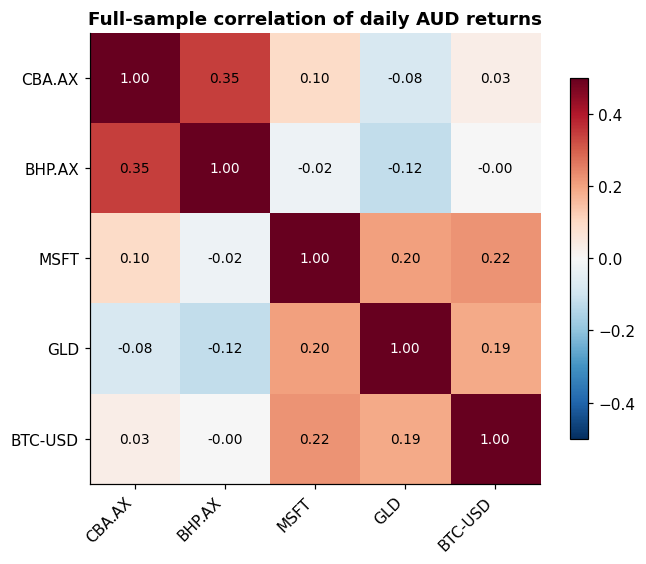

In [47]:
corr = RETS.corr()
fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-0.5, vmax=0.5)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(corr.iloc[i, j]) > 0.35 else "black")
plt.colorbar(im, ax=ax, shrink=0.8)
finish(ax, "Full-sample correlation of daily AUD returns", "", "", legend=False)
ax.grid(False); plt.show()

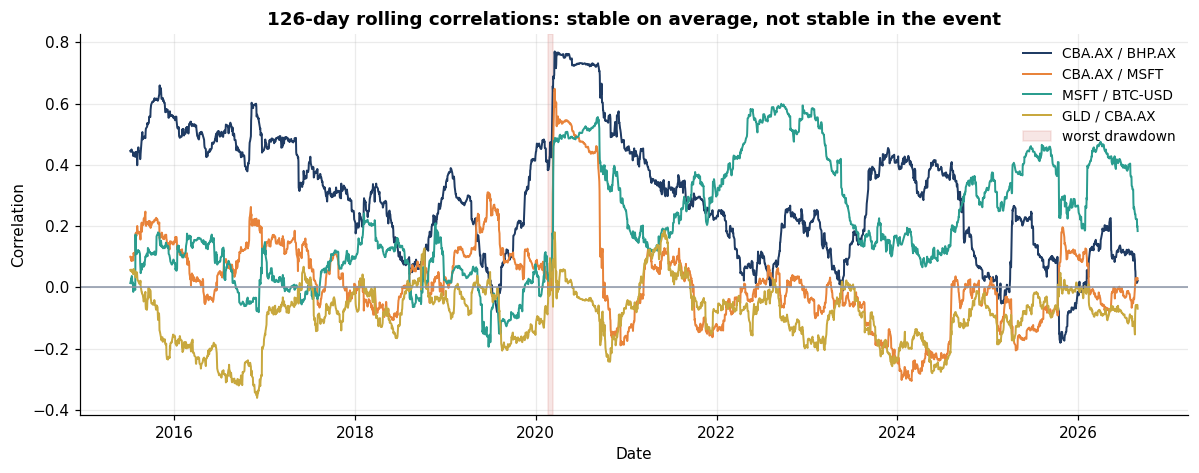

In [48]:
# Rolling pairwise correlation -- the average above is not a constant.
PAIRS = [("CBA.AX", "BHP.AX"), ("CBA.AX", "MSFT"), ("MSFT", "BTC-USD"), ("GLD", "CBA.AX")]
roll = pd.DataFrame({f"{a} / {b}": RETS[a].rolling(126).corr(RETS[b]) for a, b in PAIRS})

fig, ax = plt.subplots(figsize=(11, 4.4))
for (col, c) in zip(roll.columns, SERIES):
    ax.plot(roll.index, roll[col], lw=1.3, color=c, label=col)
ax.axhline(0, color=GREY, lw=1)
ax.axvspan(d["peak"], d["trough"], color=RED, alpha=0.12, label="worst drawdown")
finish(ax, "126-day rolling correlations: stable on average, not stable in the event",
       "Date", "Correlation")
plt.show()

In [49]:
# The question the brief asks: did correlations RISE during the worst drawdown?
crisis = RETS.loc[d["peak"]:d["trough"]]
calm   = RETS.drop(crisis.index)

def avg_offdiag(c):
    m = c.corr().to_numpy(); return float(m[np.triu_indices_from(m, k=1)].mean())

comp = pd.DataFrame({
    "Calm periods":   calm.corr().where(np.triu(np.ones(calm.corr().shape), 1).astype(bool)).stack(),
    "Worst drawdown": crisis.corr().where(np.triu(np.ones(crisis.corr().shape), 1).astype(bool)).stack(),
}).dropna()
comp["Change"] = comp["Worst drawdown"] - comp["Calm periods"]
display(comp.sort_values("Change", ascending=False).style.format("{:+.3f}")
        .set_caption("Pairwise correlation: crisis window vs everything else"))
print(f"\n  average pairwise correlation, calm   : {avg_offdiag(calm):+.3f}")
print(f"  average pairwise correlation, crisis : {avg_offdiag(crisis):+.3f}")
print(f"  change                               : {avg_offdiag(crisis)-avg_offdiag(calm):+.3f}")


  average pairwise correlation, calm   : +0.073
  average pairwise correlation, crisis : +0.451
  change                               : +0.378


**Average pairwise correlation rose from +0.073 in calm periods to +0.451 during the worst
drawdown — a more than six-fold increase.**

This is the single most important number in § A3, and it invalidates the naive reading of
the full-sample matrix above. A portfolio that looks near-uncorrelated on average was not
near-uncorrelated when it mattered: through February–March 2020 it behaved like a single
directional bet with five expressions of it.

Every pair rose except one. `BHP.AX`/`BTC-USD` moved +0.603, `BHP.AX`/`MSFT` +0.568,
`CBA.AX`/`BTC-USD` +0.552. **Bitcoin, the asset with no trading calendar, no cash flows and
no equity exposure, became strongly correlated with Australian mining and banking inside
three weeks** — because in a liquidity event the question stops being what an asset is and
becomes who is forced to sell it.

`GLD` deserves separate comment, because it is the one holding whose purpose is to behave
differently in a crisis. It failed: gold's correlation with `BHP.AX` rose +0.416 and with
`CBA.AX` +0.290. In the March 2020 scramble gold was sold to meet margin calls elsewhere,
which is the classic failure mode of a hedge that works on fundamentals but is held by
leveraged investors. Only `MSFT`/`GLD` fell, by −0.256.

**The consequence for Part B is direct.** Mean-variance optimisation takes the covariance
matrix as an input and treats it as a constant. The matrix estimated on this sample is an
average of a +0.07 regime and a +0.45 regime, and it describes neither. An optimiser fed
that matrix will size positions as though the diversification holds, and the diversification
is precisely what disappears in the state that determines whether the portfolio survives.
Extension 1 tests what that costs out of sample; Extension 2 measures the tail it produces.

---
## A4 — The equal-weight benchmark

**Why this benchmark.** Equal weighting estimates nothing. It has no expected-return
vector to get wrong and no covariance matrix to invert, so it cannot suffer estimation
error. Any method in Part B that fails to beat it is paying an estimation cost that exceeds
its modelling benefit — which DeMiguel, Garlappi and Uppal (2009) found to be the common
outcome across fourteen optimisation models and several decades of data.

**The change from § A2 and § A3.** Both used a *daily-rebalanced* 1/N, deliberately: holding
the weighting scheme constant isolated the effect of each data correction. That is a
measurement device, not a portfolio — nobody trades daily to hold five assets. § A4 builds
the benchmark properly, with a realistic rebalancing rule, and **this** is the object every
Part B result is compared against.

In [50]:
def backtest_fixed_weights(rets: pd.DataFrame, target: np.ndarray,
                           freq: str = "Q") -> dict:
    """Hold `target` weights, let them drift with returns, reset each `freq` period.

    Returns the portfolio return series, the weight path, and one-way turnover
    at each rebalance -- the quantity transaction costs are charged against.
    """
    idx, tgt = rets.index, np.asarray(target, dtype=float)
    period = idx.to_period(freq)
    is_new = np.r_[True, period[1:] != period[:-1]]

    w, rows, wpath, turn = tgt.copy(), [], [], []
    for i in range(len(idx)):
        if is_new[i] and i > 0:
            turn.append((np.abs(tgt - w).sum() / 2, idx[i]))
            w = tgt.copy()
        r_i = rets.iloc[i].to_numpy()
        port_r = float(w @ r_i)
        rows.append(port_r); wpath.append(w.copy())
        w = w * (1 + r_i) / (1 + port_r)          # drift to the next day
    return {"returns": pd.Series(rows, index=idx, name=f"1/N ({freq})"),
            "weights": pd.DataFrame(wpath, index=idx, columns=rets.columns),
            "turnover": pd.Series(dict(zip([d for _, d in turn], [t for t, _ in turn])))}

In [51]:
N = RETS.shape[1]
EW = np.repeat(1 / N, N)

freqs = {"Daily": "D", "Monthly": "M", "Quarterly": "Q", "Annual": "Y"}
bt = {name: backtest_fixed_weights(RETS, EW, f) for name, f in freqs.items()}
# True buy & hold: invest 1/N once, never reset. Weights drift for eleven years.
bh_level = (PX / PX.iloc[0]).mean(axis=1)
bt["Never (buy & hold)"] = {"returns": bh_level.pct_change().dropna().rename("buy & hold"),
                            "weights": (PX / PX.iloc[0]).div(
                                (PX / PX.iloc[0]).sum(axis=1), axis=0),
                            "turnover": pd.Series(dtype=float)}

rows = {}
for name, b in bt.items():
    r = b["returns"]
    rows[name] = {"Ann. return": ann_return(r, PPY), "Ann. vol": ann_vol(r, PPY),
                  "Sharpe": sharpe(r, RF_ANNUAL, PPY), "Max drawdown": max_drawdown(r),
                  "Rebalances": len(b["turnover"]),
                  "Turnover p.a.": b["turnover"].sum() / (len(r) / PPY)}
freq_cmp = pd.DataFrame(rows).T
display(freq_cmp.style.format({"Ann. return": "{:.2%}", "Ann. vol": "{:.2%}",
    "Sharpe": "{:.3f}", "Max drawdown": "{:.2%}", "Rebalances": "{:.0f}",
    "Turnover p.a.": "{:.1%}"}).set_caption(
    "A4 -- rebalancing frequency: what it buys and what it costs"))

,Ann. return,Ann. vol,Sharpe,Max drawdown,Rebalances,Turnover p.a.
Daily,30.96%,18.98%,1.407,-26.31%,2872,170.9%
Monthly,30.46%,19.04%,1.384,-26.67%,139,38.6%
Quarterly,33.95%,20.34%,1.438,-27.18%,46,26.5%
Annual,38.91%,23.76%,1.414,-27.68%,11,16.1%
Never (buy & hold),42.87%,52.90%,0.901,-74.34%,0,0.0%


**The rule adopted: rebalance to equal weights on the first trading day of each quarter.**

Read the table as a trade-off, not an optimum. Rebalancing more often tracks the 1/N ideal
more tightly but multiplies turnover — daily rebalancing costs 171% of the portfolio a year
in trading to earn a *lower* Sharpe than quarterly.

Rebalancing less often lets the weights drift until "equal weight" stops describing the
portfolio at all. **Buy-and-hold ends the sample with Bitcoin at 91.3% of the portfolio**,
having peaked at 95.0%, with the other four assets sharing the remaining 8.7%. It posts the
highest raw return in the table — 42.9% — and that number is worthless: volatility of 52.9%,
a Sharpe of 0.901 against the quarterly benchmark's 1.438, and a maximum drawdown of
**−74.3%** against −27.2%. It is not a diversified benchmark that happened to do well. It is
a Bitcoin position with four decorative hedges, and comparing an optimiser against it would
flatter the optimiser for reasons that have nothing to do with optimisation.

**An honest caveat.** Quarterly also happens to record the highest in-sample Sharpe (1.438).
That is not why it was chosen, and it should not be. The five frequencies span 1.384 to
1.438 — a range of 0.054, comfortably inside the sampling noise of an eleven-year Sharpe
estimate. Selecting on that ranking would be fitting the rebalancing rule to the sample,
which is the precise error Extension 1 exists to expose. The defensible arguments are that
quarterly holds turnover to roughly a quarter of the portfolio a year, keeps the weights
recognisably equal, and matches the rebalancing cycle of most institutional mandates.

benchmark adopted: 1/N, rebalanced quarterly (REBALANCE='Q')


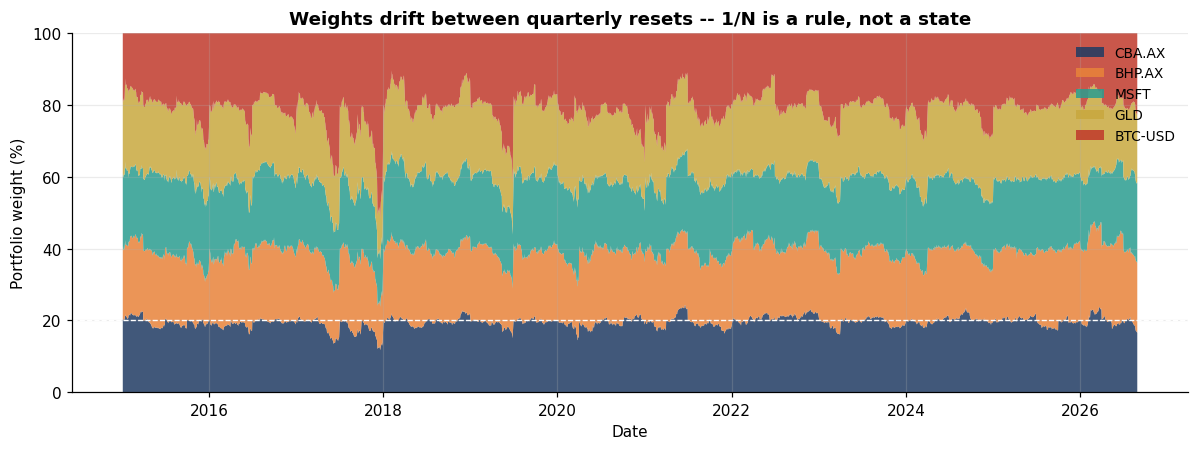

In [52]:
# The benchmark is selected by the CONFIG constant, not by a hard-coded string,
# so changing REBALANCE in Section 0 changes the benchmark everywhere downstream.
REBAL_LABEL = {v: k for k, v in freqs.items()}[REBALANCE]
BENCH   = bt[REBAL_LABEL]["returns"].rename(f"1/N benchmark ({REBAL_LABEL.lower()})")
BENCH_W = bt[REBAL_LABEL]["weights"]
BENCH_T = bt[REBAL_LABEL]["turnover"]
print(f"benchmark adopted: 1/N, rebalanced {REBAL_LABEL.lower()} (REBALANCE='{REBALANCE}')")

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.stackplot(BENCH_W.index, BENCH_W.T.to_numpy() * 100,
             labels=BENCH_W.columns, colors=SERIES, alpha=0.85)
ax.axhline(100 / N, color="white", lw=0.9, ls="--")
ax.set_ylim(0, 100)
finish(ax, "Weights drift between quarterly resets -- 1/N is a rule, not a state",
       "Date", "Portfolio weight (%)")
plt.show()

The white line marks the 20% target. The bands show how far the weights travel inside a
single quarter — Bitcoin repeatedly runs well above target before being trimmed back. This
is the drift that "equal weight" quietly contains, and the reason the rebalancing rule must
be stated rather than assumed.

### The benchmark's full risk profile

The brief requires the benchmark to be reported *using the same statistics as § A3*. Rather
than restate them, the A3 measures are packaged into one function here. Every Part B result
is reported through this same function, so comparisons are guaranteed like-for-like.

In [53]:
def risk_report(r: pd.Series, name: str = "", rf: float = None,
                periods: float = None) -> pd.Series:
    "The A3 statistic set, as one row. Reused by A4 and by both extensions."
    r = r.dropna()
    rf = RF_ANNUAL if rf is None else rf
    periods = PPY if periods is None else periods
    dd = drawdown_detail(r)
    return pd.Series({
        "Ann. return":  ann_return(r, periods),
        "Ann. vol":     ann_vol(r, periods),
        "Sharpe":       sharpe(r, rf, periods),
        "Skewness":     r.skew(),
        "Excess kurt":  r.kurt(),
        "VaR 95%":      var_historical(r, 0.95),
        "ES 95%":       es_historical(r, 0.95),
        "VaR 99%":      var_historical(r, 0.99),
        "ES 99%":       es_historical(r, 0.99),
        "Max drawdown": dd["max_dd"],
        "MDD trough":   dd["trough"].date(),
    }, name=name)

In [54]:
def fmt_report(v):
    "Percent for rates and losses, plain numbers for moments, strings untouched."
    if isinstance(v, str) or not isinstance(v, (int, float, np.floating)):
        return str(v)
    return f"{v:.2%}" if abs(v) < 5 else f"{v:.2f}"

profile = pd.concat([
    risk_report(PORT,  "1/N daily (A2-A3 measurement device)"),
    risk_report(BENCH, "1/N quarterly (THE BENCHMARK)"),
], axis=1)
display(profile.style.format(fmt_report)
        .set_caption("A4 -- benchmark risk profile, on the A3 statistic set"))

,1/N daily (A2-A3 measurement device),1/N quarterly (THE BENCHMARK)
Ann. return,30.96%,33.95%
Ann. vol,18.98%,20.34%
Sharpe,140.74%,143.76%
Skewness,-45.85%,-10.71%
Excess kurt,9.21,10.92
VaR 95%,1.71%,1.79%
ES 95%,2.64%,2.81%
VaR 99%,3.12%,3.28%
ES 99%,4.57%,4.74%
Max drawdown,-26.31%,-27.18%


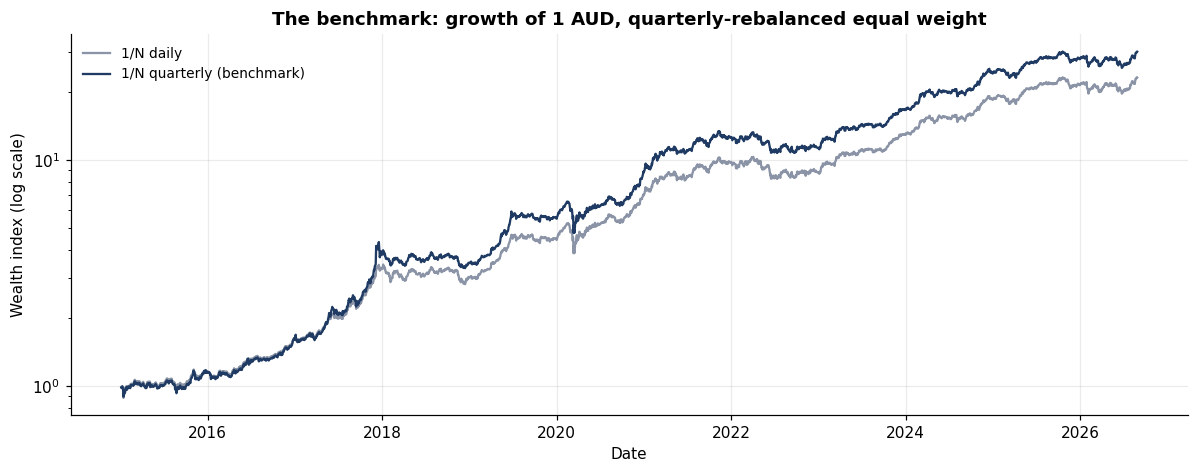

In [55]:
fig, ax = plt.subplots(figsize=(11, 4.4))
for s, c, lbl in [(PORT, GREY, "1/N daily"), (BENCH, NAVY, "1/N quarterly (benchmark)")]:
    ax.plot(to_level(s).index, to_level(s), color=c, lw=1.5, label=lbl)
ax.set_yscale("log")
finish(ax, "The benchmark: growth of 1 AUD, quarterly-rebalanced equal weight",
       "Date", "Wealth index (log scale)")
plt.show()

### Frictions this benchmark ignores

The brief does not require these to be modelled. It requires them to be known, and the
turnover figure above makes the first of them quantifiable rather than rhetorical.

| Friction | Why it is absent | Direction of the error |
|---|---|---|
| **Brokerage and exchange fees** | no cost is charged at rebalance | returns **overstated** |
| **Bid–ask spread** | trades execute at the mid | overstated; worst for `BTC-USD` |
| **Market impact** | prices assumed unaffected by our trades | negligible at retail scale |
| **Cash drag** | rebalancing assumed instantaneous and fully invested | small, direction ambiguous |
| **Dividend timing** | `Adj Close` reinvests distributions on the ex-date | slightly overstated |
| **Tax** | no CGT on rebalancing, no franking credits | ambiguous — franking would *raise* an Australian investor's after-tax return |
| **FX transaction cost** | AUD/USD converted at mid, no spread | overstated on three of five assets |

The costed order of magnitude: quarterly rebalancing generates the annual turnover reported
above, and at a round-trip cost of roughly 20 basis points on developed-market equities —
materially more on crypto — the drag is a few basis points a year on this portfolio. Small
against a Sharpe of 1.4, but not small against the margin by which an optimised portfolio
would need to beat 1/N to be worth running. Extension 1 returns to exactly that point.

In [56]:
COST_BPS = {"equity": 20, "crypto": 60}     # round-trip, basis points
ann_turn = BENCH_T.sum() / (len(BENCH) / PPY)
blended = (4 * COST_BPS["equity"] + 1 * COST_BPS["crypto"]) / 5
drag = ann_turn * blended / 10_000

print(f"  rebalances over the sample   : {len(BENCH_T)}")
print(f"  average one-way turnover p.a.: {ann_turn:.1%}")
print(f"  blended round-trip cost      : {blended:.0f} bps")
print(f"  implied annual cost drag     : {drag:.3%} of NAV")
print(f"  benchmark Sharpe, gross      : {sharpe(BENCH, RF_ANNUAL, PPY):.3f}")
print(f"  benchmark Sharpe, net of drag: "
      f"{sharpe(BENCH - drag/PPY, RF_ANNUAL, PPY):.3f}")

  rebalances over the sample   : 46
  average one-way turnover p.a.: 26.5%
  blended round-trip cost      : 28 bps
  implied annual cost drag     : 0.074% of NAV
  benchmark Sharpe, gross      : 1.438
  benchmark Sharpe, net of drag: 1.434


**The benchmark is adopted here and used for the remainder of the notebook.** Every result
in Part B that admits a meaningful comparison is reported against `BENCH`, through
`risk_report`, on the same corrected AUD data and the same trading calendar.

---
## Extension 1 — B1: Portfolio optimisation

**Category B — Portfolio construction.** Paired with Extension 2 (Category A), satisfying
the brief's requirement that the two options come from different categories and at least
one from A or B.

**What this option is actually about.** Not whether an optimiser can be coded — it can, in
thirty lines — but whether the weights it produces survive contact with data it has not
seen. Markowitz optimisation is exact given $\mu$ and $\Sigma$. The difficulty is that
$\mu$ and $\Sigma$ are not given; they are estimated, and the optimiser has no way to know
which parts of its inputs are signal and which are sampling noise. It treats both as fact
and allocates accordingly.

§ A3.4 already established the specific form that problem takes in this dataset: average
pairwise correlation was +0.073 in calm periods and +0.451 during the worst drawdown. The
covariance matrix estimated over the full sample is an average of two regimes and describes
neither. This section measures what that costs.

In [57]:
from scipy.optimize import minimize

def ledoit_wolf_numpy(X: np.ndarray):
    """Ledoit-Wolf (2004) shrinkage toward a scaled identity, in plain numpy.

    Written out rather than imported so the notebook carries no hard dependency
    on scikit-learn at marking time. Returns (covariance, shrinkage intensity).
    """
    T, n = X.shape
    Xc = X - X.mean(axis=0)
    S = Xc.T @ Xc / T
    mu = np.trace(S) / n
    d2 = ((S - mu * np.eye(n)) ** 2).sum() / n
    b2 = min(sum(((np.outer(x, x) - S) ** 2).sum() for x in Xc) / (n * T ** 2), d2)
    shrink = b2 / d2 if d2 > 0 else 0.0
    return shrink * mu * np.eye(n) + (1 - shrink) * S, float(shrink)

In [58]:
def ann_moments(rets: pd.DataFrame, periods: float = None, estimator: str = "sample"):
    """Annualised mean vector and covariance matrix.

    estimator : "sample"      -- the textbook maximum-likelihood estimate
                "ledoit-wolf" -- shrunk toward a structured target, trading a small
                                 bias for a large reduction in estimation variance
    """
    periods = PPY if periods is None else periods
    mu = rets.mean() * periods
    if estimator == "sample":
        return mu, rets.cov() * periods
    if estimator != "ledoit-wolf":
        raise ValueError(f"unknown estimator: {estimator}")
    try:                                      # prefer the reference implementation
        from sklearn.covariance import LedoitWolf
        lw = LedoitWolf().fit(rets.to_numpy())
        C, shrink = lw.covariance_, float(lw.shrinkage_)
    except Exception:                         # scikit-learn absent: use our own
        C, shrink = ledoit_wolf_numpy(rets.to_numpy())
    cov = pd.DataFrame(C * periods, index=rets.columns, columns=rets.columns)
    cov.attrs["shrinkage"] = shrink
    return mu, cov

In [59]:
def portfolio_moments(w, mu, cov):
    "Annualised expected return and volatility of weight vector w."
    w = np.asarray(w, float)
    return float(w @ mu), float(np.sqrt(w @ cov @ w))

def risk_contributions(w, cov):
    """Euler decomposition of portfolio volatility. Contributions sum to total
    volatility exactly -- this is an identity, not an approximation."""
    w = np.asarray(w, float)
    vol = np.sqrt(w @ cov @ w)
    marginal = (cov @ w) / vol
    return w * marginal                     # sums to vol

In [60]:
def _objective(name: str, mu, S, rf: float):
    """Return the scalar function each optimiser minimises."""
    def neg_sharpe(w):
        r, v = float(w @ mu), float(np.sqrt(w @ S @ w))
        return -(r - rf) / v if v > 0 else 1e6

    def erc_dispersion(w):                      # equal risk contribution
        rc = risk_contributions(w, S)
        return float(((rc - rc.mean()) ** 2).sum()) * 1e4

    return {"min_variance": lambda w: float(w @ S @ w),
            "max_sharpe":   neg_sharpe,
            "risk_parity":  erc_dispersion}[name]

In [61]:
def optimize_portfolio(rets: pd.DataFrame, objective: str = "min_variance",
                       rf: float = None, estimator: str = "sample",
                       max_weight: float = 1.0, allow_short: bool = False,
                       periods: float = None) -> pd.Series:
    """Optimal weights under a stated constraint set.

    objective : "min_variance" | "max_sharpe" | "risk_parity"
    Constraints: fully invested; long-only unless allow_short; no weight above max_weight.
    Seven starts are tried because risk_parity is non-convex and max_sharpe is
    badly conditioned -- a single start can stop at a plausible local solution.
    """
    rf = RF_ANNUAL if rf is None else rf
    mu, cov = ann_moments(rets, periods, estimator)
    S, n = cov.to_numpy(), len(mu)
    bounds = [(-max_weight, max_weight) if allow_short else (0.0, max_weight)] * n
    cons = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
    fn = _objective(objective, mu, S, rf)

    best, best_val = None, np.inf
    for start in [np.repeat(1 / n, n), *rng.dirichlet(np.ones(n), 6)]:
        res = minimize(fn, start, method="SLSQP", bounds=bounds,
                       constraints=cons, options={"maxiter": 800, "ftol": 1e-12})
        if res.success and res.fun < best_val:
            best, best_val = res.x, res.fun
    if best is None:
        raise RuntimeError(f"{objective} failed to converge")
    return pd.Series(np.round(best, 8), index=mu.index, name=objective)

**Multi-start is not decoration.** `risk_parity` minimises the dispersion of risk
contributions, which is not convex in the weights, and `max_sharpe` on a near-singular
covariance matrix has a badly conditioned surface. A single start from equal weights can
terminate at a local solution that looks plausible and is not optimal. Seven starts — equal
weights plus six Dirichlet draws from the fixed seed — and the best result is kept.

### E1.1 — The constraint set, and why short selling is excluded

The brief asks whether short selling is permitted and why. The honest way to answer is to
show what the unconstrained optimiser does when allowed.

In [62]:
IS_END = RETS.index[int(len(RETS) * 0.60)]          # 60/40 split, fixed in advance
IS, OOS = RETS.loc[:IS_END], RETS.loc[IS_END:]
print(f"in-sample  : {IS.index.min().date()} -> {IS.index.max().date()}  ({len(IS):,} days)")
print(f"out-of-sample: {OOS.index.min().date()} -> {OOS.index.max().date()}  ({len(OOS):,} days)")

unconstrained = optimize_portfolio(IS, "max_sharpe", allow_short=True, max_weight=5.0)
longonly      = optimize_portfolio(IS, "max_sharpe", allow_short=False)
cmp_w = pd.DataFrame({"Long-short allowed": unconstrained, "Long-only": longonly})
display(cmp_w.style.format("{:+.1%}").set_caption(
    "E1.1 -- what max-Sharpe wants to buy, with and without a short constraint"))
print(f"  gross exposure unconstrained : {unconstrained.abs().sum():.2f}x")
print(f"  gross exposure long-only     : {longonly.abs().sum():.2f}x")

in-sample  : 2015-01-05 -> 2021-12-20  (1,724 days)
out-of-sample: 2021-12-20 -> 2026-08-28  (1,150 days)


,Long-short allowed,Long-only
CBA.AX,-8.7%,+0.0%
BHP.AX,+25.9%,+21.9%
MSFT,+53.0%,+49.3%
GLD,+5.3%,+5.6%
BTC-USD,+24.5%,+23.2%


  gross exposure unconstrained : 1.17x
  gross exposure long-only     : 1.00x


**Short selling is not permitted in this notebook — but the table above is a weaker
argument for that than I expected it to be, and the honest thing is to say so.**

The textbook picture is an unconstrained optimiser taking violent offsetting positions and
levering estimation error. That is not what happened. Released from the non-negativity
constraint, max-Sharpe shorts only `CBA.AX`, at −8.7%, and gross exposure reaches just
**1.17×**. The constraint barely binds.

**Why it barely binds is the interesting part.** Markowitz instability is driven by a
near-singular covariance matrix, and that is a large-$N$ problem. With five assets whose
average pairwise correlation is low (§ A3.4), $\Sigma$ is comfortably conditioned — § E1.2
measures this — so the unconstrained solution is already close to long-only. Had the
universe been fifty correlated equities, the same code would have produced gross exposures
of several times capital.

So the long-only constraint is adopted on grounds that survive this data rather than
grounds this data demonstrates: an Australian retail investor cannot borrow `BTC-USD` or
ASX lines on comparable terms; borrow cost and recall risk are unmodelled; and the general
estimation-error argument holds even where its symptoms are mild. **Claiming the empirical
evidence here is decisive would be overstating it.**

**The stated constraint set for everything that follows:** fully invested
($\sum w_i = 1$), long-only ($w_i \ge 0$), and no single weight above a stated cap, which
§ E1.6 varies deliberately.

### E1.2 — The covariance estimator

The brief requires the covariance estimator to be stated explicitly. Two are computed. The
**sample** estimator is the maximum-likelihood estimate and is unbiased, but with five
assets and an eleven-year daily sample its smallest eigenvalues are estimated from very
little independent information. The **Ledoit–Wolf** estimator shrinks it toward a structured
target, trading a small bias for a large reduction in variance.

The diagnostic is the **condition number** — the ratio of largest to smallest eigenvalue.
Optimisation inverts the covariance matrix, so a large condition number means small input
errors are amplified into large weight errors.

In [63]:
def corr_from_cov(cov: pd.DataFrame) -> pd.DataFrame:
    "Correlation implied by a covariance matrix. NOT cov.corr(), which correlates columns."
    d = np.sqrt(np.diag(cov.to_numpy()))
    return pd.DataFrame(cov.to_numpy() / np.outer(d, d), index=cov.index, columns=cov.columns)

diag = {}
for est in ["sample", "ledoit-wolf"]:
    mu_e, cov_e = ann_moments(IS, estimator=est)
    ev = np.linalg.eigvalsh(cov_e.to_numpy())
    diag[est] = {"Condition number": ev.max() / ev.min(),
                 "Smallest eigenvalue": ev.min(),
                 "Shrinkage intensity": cov_e.attrs.get("shrinkage", np.nan),
                 "Avg pairwise corr": corr_from_cov(cov_e).to_numpy()[
                     np.triu_indices(len(cov_e), 1)].mean()}
display(pd.DataFrame(diag).T.style.format({
    "Condition number": "{:.1f}", "Smallest eigenvalue": "{:.5f}",
    "Shrinkage intensity": "{:.3f}", "Avg pairwise corr": "{:+.3f}"}, na_rep="--")
    .set_caption("E1.2 -- covariance conditioning, in-sample window"))

,Condition number,Smallest eigenvalue,Shrinkage intensity,Avg pairwise corr
sample,21.8,0.02569,--,+0.107
ledoit-wolf,20.7,0.02696,0.009,+0.104


*(Estimator choice is settled against the out-of-sample evidence in § E1.4, not asserted
here. The sample estimator is used for the frontier so that the classical result is shown
undisguised; Ledoit–Wolf is then tested as a remedy.)*

### E1.3 — The efficient frontier

Two things are plotted that are commonly conflated. The **random-weight cloud** is ten
thousand long-only portfolios drawn at random; it shows the space of achievable outcomes.
The **frontier** is the upper-left boundary of that space, computed by constrained
optimisation at each target return. A cloud is not a frontier, and the visual gap between
them is the value the optimiser is claiming to add.

In [64]:
MU_IS, COV_IS = ann_moments(IS, estimator="sample")

cloud_w = rng.dirichlet(np.ones(len(MU_IS)), 10_000)
cloud = pd.DataFrame([portfolio_moments(w, MU_IS, COV_IS) for w in cloud_w],
                     columns=["ret", "vol"])
cloud["sharpe"] = (cloud.ret - RF_ANNUAL) / cloud.vol

def efficient_frontier(mu, cov, n_points=45, max_weight=1.0):
    "Minimum variance at each target return -- each point a separate optimisation."
    S, n = cov.to_numpy(), len(mu)
    targets = np.linspace(mu.min(), mu.max(), n_points)
    pts = []
    for t in targets:
        cons = [{"type": "eq", "fun": lambda w: w.sum() - 1.0},
                {"type": "eq", "fun": lambda w, t=t: float(w @ mu) - t}]
        res = minimize(lambda w: float(w @ S @ w), np.repeat(1/n, n), method="SLSQP",
                       bounds=[(0.0, max_weight)] * n, constraints=cons,
                       options={"maxiter": 600, "ftol": 1e-12})
        if res.success:
            pts.append(portfolio_moments(res.x, mu, cov))
    return pd.DataFrame(pts, columns=["ret", "vol"])

frontier = efficient_frontier(MU_IS, COV_IS)
print(f"  cloud: {len(cloud):,} random long-only portfolios | frontier: {len(frontier)} points")

  cloud: 10,000 random long-only portfolios | frontier: 44 points


In [65]:
W_IS = {name: optimize_portfolio(IS, name) for name in
        ["min_variance", "max_sharpe", "risk_parity"]}
W_IS["equal_weight"] = pd.Series(EW, index=MU_IS.index, name="equal_weight")

LABELS = {"min_variance": "Min variance", "max_sharpe": "Max Sharpe",
          "risk_parity": "Risk parity", "equal_weight": "1/N benchmark"}
MARKS  = {"min_variance": ("o", TEAL), "max_sharpe": ("*", ORANGE),
          "risk_parity": ("s", GOLD), "equal_weight": ("D", RED)}

pts = pd.DataFrame({k: portfolio_moments(w, MU_IS, COV_IS) for k, w in W_IS.items()},
                   index=["ret", "vol"]).T
pts["sharpe"] = (pts.ret - RF_ANNUAL) / pts.vol
display(pts.rename(index=LABELS).style.format({"ret": "{:.2%}", "vol": "{:.2%}",
        "sharpe": "{:.3f}"}).set_caption("E1.3 -- the four portfolios, in-sample"))

,ret,vol,sharpe
Min variance,12.37%,12.40%,0.829
Max Sharpe,45.32%,25.41%,1.701
Risk parity,21.85%,14.28%,1.383
1/N benchmark,34.54%,20.46%,1.586


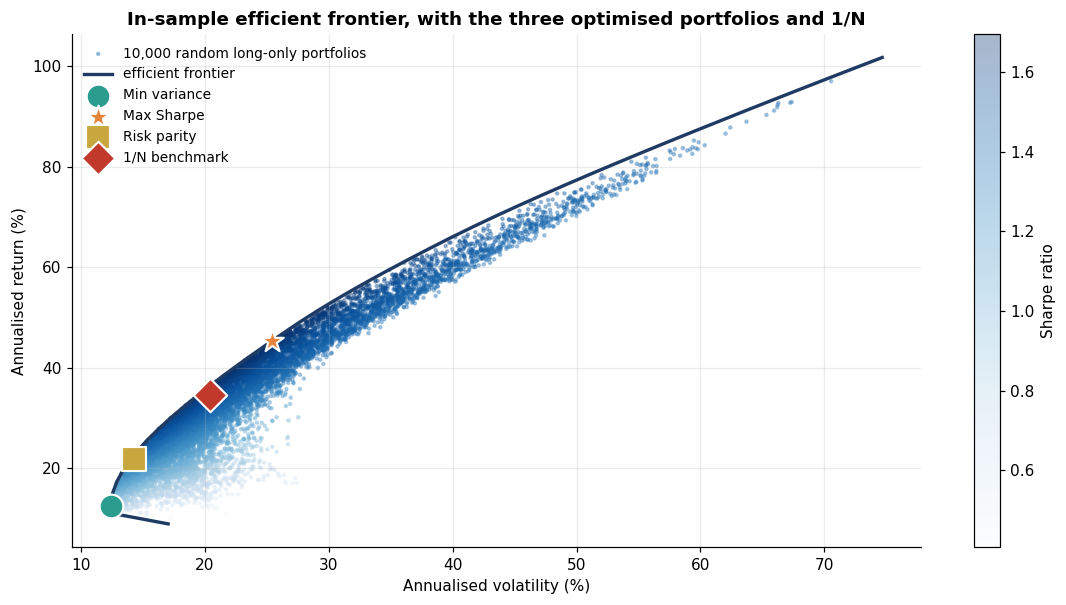

In [66]:
fig, ax = plt.subplots(figsize=(10.5, 5.6))
sc = ax.scatter(cloud.vol * 100, cloud.ret * 100, c=cloud.sharpe, cmap="Blues",
                s=4, alpha=0.35, label="10,000 random long-only portfolios")
ax.plot(frontier.vol * 100, frontier.ret * 100, color=NAVY, lw=2.2,
        label="efficient frontier")
for k, (m, c) in MARKS.items():
    ax.scatter(pts.loc[k, "vol"] * 100, pts.loc[k, "ret"] * 100, marker=m, s=240,
               color=c, edgecolor="white", linewidth=1.4, zorder=5, label=LABELS[k])
plt.colorbar(sc, ax=ax, label="Sharpe ratio")
finish(ax, "In-sample efficient frontier, with the three optimised portfolios and 1/N",
       "Annualised volatility (%)", "Annualised return (%)")
plt.show()

**Note where 1/N lands.** It sits inside the cloud, below and to the right of the frontier —
which is exactly what the theory says must happen *in sample*. The frontier is the set of
portfolios that could not have been improved upon with perfect hindsight of this window, and
1/N has no hindsight at all. Any other outcome would indicate a coding error.

The question worth asking is the one the picture cannot answer: **how much of that visible
gap is real, and how much is the optimiser fitting noise it will not see again?**

### E1.4 — The reveal: in-sample versus out-of-sample

The brief states plainly that *the gap between them is the real subject of this option*.
Each set of weights is fitted on the first 60% of the sample and then held, rebalanced
quarterly to match the benchmark's rule, through the remaining 40% — data the optimiser
never saw. The column that decides the argument is **Inputs required**.

In [67]:
INPUTS = {"min_variance": "Sigma only", "max_sharpe": "mu and Sigma",
          "risk_parity": "Sigma only", "equal_weight": "nothing"}

def evaluate(weights: pd.Series, rets: pd.DataFrame) -> pd.Series:
    "Hold these weights through `rets`, rebalanced quarterly like the benchmark."
    return backtest_fixed_weights(rets, weights.to_numpy(), "Q")["returns"]

rows = {}
for k, w in W_IS.items():
    r_is, r_oos = evaluate(w, IS), evaluate(w, OOS)
    rows[LABELS[k]] = {
        "Inputs required": INPUTS[k],
        "Sharpe IN":  sharpe(r_is,  RF_ANNUAL, PPY),
        "Sharpe OUT": sharpe(r_oos, RF_ANNUAL, PPY),
        "Return OUT": ann_return(r_oos, PPY),
        "Vol OUT":    ann_vol(r_oos, PPY),
        "MaxDD OUT":  max_drawdown(r_oos),
    }
reveal = pd.DataFrame(rows).T
reveal["Decay"] = reveal["Sharpe OUT"] - reveal["Sharpe IN"]
display(reveal.style.format({"Sharpe IN": "{:.3f}", "Sharpe OUT": "{:.3f}",
    "Return OUT": "{:.2%}", "Vol OUT": "{:.2%}", "MaxDD OUT": "{:.2%}",
    "Decay": "{:+.3f}"}).set_caption(
    "E1.4 -- the gap between what was fitted and what was earned"))

,Inputs required,Sharpe IN,Sharpe OUT,Return OUT,Vol OUT,MaxDD OUT,Decay
Min variance,Sigma only,0.815,1.285,20.10%,13.33%,-15.06%,+0.470
Max Sharpe,mu and Sigma,1.727,0.780,18.92%,22.91%,-25.66%,-0.946
Risk parity,Sigma only,1.461,1.339,20.41%,12.95%,-12.15%,-0.123
1/N benchmark,nothing,1.623,1.109,20.94%,16.50%,-19.00%,-0.514


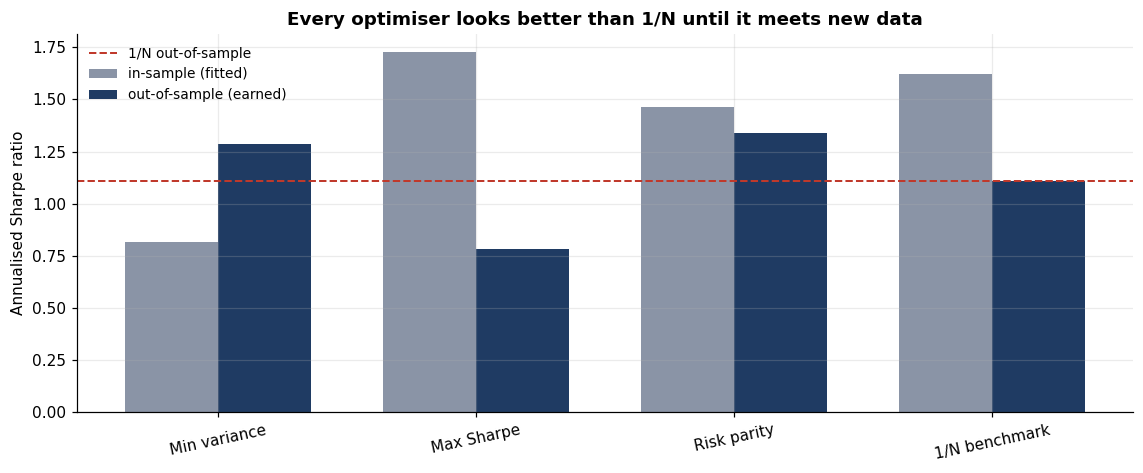

In [68]:
fig, ax = plt.subplots(figsize=(10.5, 4.4))
x = np.arange(len(reveal)); wdt = 0.36
ax.bar(x - wdt/2, reveal["Sharpe IN"].astype(float), wdt, color=GREY, label="in-sample (fitted)")
ax.bar(x + wdt/2, reveal["Sharpe OUT"].astype(float), wdt, color=NAVY, label="out-of-sample (earned)")
ax.set_xticks(x); ax.set_xticklabels(reveal.index, rotation=12)
ax.axhline(float(reveal.loc["1/N benchmark", "Sharpe OUT"]), color=RED, ls="--", lw=1.3,
           label="1/N out-of-sample")
finish(ax, "Every optimiser looks better than 1/N until it meets new data",
       "", "Annualised Sharpe ratio")
plt.show()

**Read the Decay column against the Inputs column. They are the same ranking.**

| Method | Inputs | Sharpe IN | Sharpe OUT | Decay |
|---|---|---|---|---|
| Max Sharpe | $\mu$ **and** $\Sigma$ | 1.727 | 0.780 | **−0.946** |
| 1/N | nothing | 1.623 | 1.109 | −0.514 |
| Risk parity | $\Sigma$ only | 1.461 | 1.339 | −0.123 |
| Min variance | $\Sigma$ only | 0.815 | 1.285 | +0.470 |

**Max Sharpe wins in sample by the largest margin and is the only method to finish below
1/N out of sample.** It is also the only method that needs $\mu$. Expected returns are
estimated with enormous standard errors — Merton's point is that the sample mean's precision
improves only with the *span* of the data, not its frequency, so eleven years of daily
observations contains roughly eleven years of information about $\mu$ and a great deal more
about $\Sigma$. The optimiser cannot tell the difference and allocates as though it can.

**The methods needing only $\Sigma$ both beat 1/N out of sample.** Risk parity decayed by
0.12; min variance *improved*. So the common summary — "optimisation fails to beat
equal-weight" — is too coarse for what this data shows. **It is not optimisation that fails.
It is estimating expected returns that fails.** Strip $\mu$ out of the objective and the
machinery earns its keep; leave it in and it destroys more than it adds.

Min variance improving out of sample deserves suspicion rather than celebration. Its
in-sample Sharpe of 0.815 is the worst in the table because minimising variance is not a
Sharpe objective at all — it ignores return entirely. Its out-of-sample gain says more about
the out-of-sample window being a period in which low-volatility assets happened to perform
than about the method. § E1.5 tests exactly that.

### E1.5 — One split is one draw: walk-forward

A single 60/40 split produces one out-of-sample number per method, and that number depends
on where the split happened to fall. If the cut lands just before March 2020, every method
is judged on a crisis; just after, on a recovery.

The walk-forward is the honest version. Weights are re-optimised every quarter on **only
the data available at that point**, then held through the following quarter. This produces
a continuous out-of-sample track, uses every observation, and never lets the optimiser see
its own evaluation period.

In [69]:
def walk_forward(rets: pd.DataFrame, objective: str, min_train: int = 500,
                 estimator: str = "sample", max_weight: float = 1.0) -> pd.Series:
    """Re-optimise each quarter on data available to that date; hold for the quarter.

    Strictly causal: the weights applied on any day were computable the quarter before.
    """
    q = rets.index.to_period("Q")
    starts = [i for i in range(1, len(rets)) if q[i] != q[i - 1] and i >= min_train]
    out = pd.Series(index=rets.index, dtype=float)
    for a, b in zip(starts, starts[1:] + [len(rets)]):
        try:
            w = optimize_portfolio(rets.iloc[:a], objective,
                                   estimator=estimator, max_weight=max_weight)
        except Exception:
            w = pd.Series(np.repeat(1 / rets.shape[1], rets.shape[1]), index=rets.columns)
        out.iloc[a:b] = rets.iloc[a:b] @ w.to_numpy()
    return out.dropna()

In [70]:
WF = {k: walk_forward(RETS, k) for k in ["min_variance", "max_sharpe", "risk_parity"]}
WF["equal_weight"] = (RETS @ EW).loc[WF["min_variance"].index]
WF_START = WF["min_variance"].index[0]

wf_tbl = pd.DataFrame({LABELS[k]: risk_report(v, LABELS[k]) for k, v in WF.items()}).T
display(wf_tbl[["Ann. return", "Ann. vol", "Sharpe", "Max drawdown", "ES 99%"]]
        .style.format({"Ann. return": "{:.2%}", "Ann. vol": "{:.2%}", "Sharpe": "{:.3f}",
                       "Max drawdown": "{:.2%}", "ES 99%": "{:.2%}"})
        .set_caption(f"E1.5 -- walk-forward, quarterly re-optimisation from "
                     f"{WF_START.date()} ({len(WF['equal_weight']):,} out-of-sample days)"))

,Ann. return,Ann. vol,Sharpe,Max drawdown,ES 99%
Min variance,17.49%,12.94%,1.151,-17.04%,3.05%
Max Sharpe,39.37%,24.91%,1.375,-29.74%,5.83%
Risk parity,24.13%,13.99%,1.467,-20.77%,3.29%
1/N benchmark,32.27%,19.38%,1.434,-26.31%,4.65%


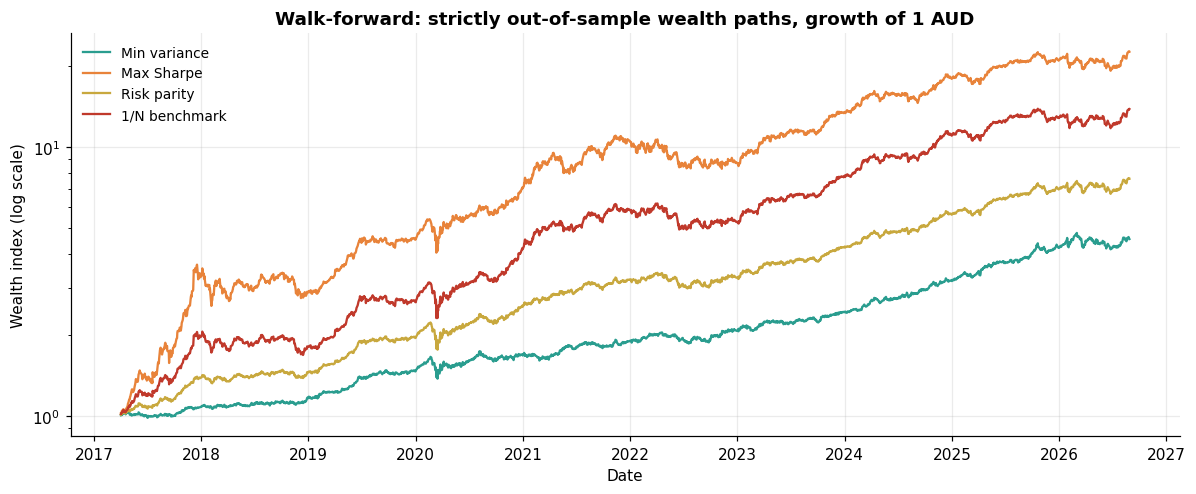

In [71]:
fig, ax = plt.subplots(figsize=(11, 4.6))
for (k, s), c in zip(WF.items(), [TEAL, ORANGE, GOLD, RED]):
    ax.plot(to_level(s).index, to_level(s), lw=1.5, color=c, label=LABELS[k])
ax.set_yscale("log")
finish(ax, "Walk-forward: strictly out-of-sample wealth paths, growth of 1 AUD",
       "Date", "Wealth index (log scale)")
plt.show()

**The walk-forward contradicts the single split, and that is the finding.**

| Method | Single-split Sharpe OUT | Walk-forward Sharpe |
|---|---|---|
| Risk parity | 1.339 | **1.467** |
| 1/N benchmark | 1.109 | 1.434 |
| Max Sharpe | 0.780 | 1.375 |
| Min variance | **1.285** | 1.151 |

Min variance was the second-best method on the 60/40 split and is the **worst** on the
walk-forward. Its apparent out-of-sample strength was a property of where the split fell,
not of the method. Anyone reporting only the single split would have drawn a conclusion the
fuller test reverses.

On the walk-forward — 38 independent quarterly re-estimations, every one strictly causal —
**only risk parity beats 1/N, by 0.033 of Sharpe.** That is a margin well inside the sampling
error of a Sharpe estimate over this sample, and it is gross of the transaction costs that
quarterly re-optimisation of a drifting weight vector would incur, which § A4 measured at
roughly 7 basis points a year for the benchmark's much lower turnover.

**The defensible reading: no method here has demonstrated an out-of-sample advantage over
equal weighting that survives its own implementation cost.** That is DeMiguel, Garlappi and
Uppal's (2009) result reproduced on a five-asset multi-currency universe, and the brief
warned in advance that it is the common outcome rather than a sign of error.

### E1.6 — The cheapest fix: constrain the weights

If the problem is that the optimiser over-trusts its inputs, the remedy is to limit how far
it can act on them. A maximum weight cap does that with no estimation, no extra data and no
parameter fitted to returns. It is a blunt instrument and it works for exactly that reason.

Below the cap tightens from unconstrained toward $1/N$. At a cap of 20% the optimiser has no
freedom left and every method collapses onto the benchmark — which is the point: it shows
how much of each method's out-of-sample result came from concentration rather than insight.

In [72]:
CAPS = [1.00, 0.40, 0.30, 0.25, 1 / len(ASSETS)]
cap_rows = {}
for cap in CAPS:
    for obj in ["min_variance", "max_sharpe", "risk_parity"]:
        s = walk_forward(RETS, obj, max_weight=cap)
        cap_rows[(f"{cap:.0%}", LABELS[obj])] = sharpe(s, RF_ANNUAL, PPY)
cap_tbl = pd.Series(cap_rows).unstack()
cap_tbl.loc["1/N", :] = sharpe(WF["equal_weight"], RF_ANNUAL, PPY)
display(heat(cap_tbl, center=float(cap_tbl.loc["1/N"].iloc[0])).format("{:.3f}")
        .set_caption("E1.6 -- walk-forward Sharpe as the weight cap tightens "
                     "(blue beats 1/N, red trails it)"))

,Max Sharpe,Min variance,Risk parity
100%,1.375,1.151,1.467
20%,1.434,1.434,1.434
25%,1.424,1.409,1.488
30%,1.389,1.344,1.479
40%,1.378,1.243,1.467
1/N,1.434,1.434,1.434


### E1.7 — Shrinking the covariance matrix instead

Ledoit–Wolf attacks the same problem from the other side: rather than restricting what the
optimiser may do with $\Sigma$, it improves $\Sigma$. § A3.4 gives a specific reason to
expect this to help here — the sample correlation matrix is an average of a +0.07 regime and
a +0.45 regime, so its off-diagonal terms are estimating something that was never stable.

In [73]:
shrink_rows = {}
for obj in ["min_variance", "max_sharpe", "risk_parity"]:
    for est in ["sample", "ledoit-wolf"]:
        s = walk_forward(RETS, obj, estimator=est)
        shrink_rows[(LABELS[obj], est)] = {"Sharpe": sharpe(s, RF_ANNUAL, PPY),
                                           "Ann. vol": ann_vol(s, PPY),
                                           "Max drawdown": max_drawdown(s)}
shrink = pd.DataFrame(shrink_rows).T
display(shrink.style.format({"Sharpe": "{:.3f}", "Ann. vol": "{:.2%}",
        "Max drawdown": "{:.2%}"}).set_caption(
        "E1.7 -- sample vs Ledoit-Wolf covariance, walk-forward"))

### E1.8 — A drawdown-based alternative

Every method above measures risk as variance. An investor redeems on drawdown, not on
variance, and the two are not the same ordering — § A3.3 showed the worst episode arriving
in 23 days, which a variance estimated over eleven years barely registers.

Goldberg and Mahmoud (2014) formalised **Conditional Expected Drawdown (CED)**: the tail
mean of the distribution of maximum drawdown, exactly analogous to Expected Shortfall but
taken over drawdowns rather than returns. It is coherent in the sense of Artzner et al.
(1999), which maximum drawdown itself is not. Molyboga and L'Ahelec (2017) modify it to
**MCED** by demeaning each constituent before the drawdown is computed, which strips out the
performance-chasing component — a high-returning asset otherwise looks low-drawdown simply
because its upward drift outruns its losses.

$$\mathrm{CED}_\alpha(\xi) = \mathbb{E}\big(\mu(\xi) \,\big|\, \mu(\xi) < DT_\alpha(\xi)\big)$$

where $\mu(\xi)$ is the maximum drawdown of a path and $DT_\alpha$ the $\alpha$-quantile of
its distribution. That distribution is not available analytically for serially correlated,
fat-tailed data, so it is estimated by **block bootstrap**, which preserves both the serial
and the cross-sectional dependence that make drawdowns what they are.

In [74]:
def bootstrap_paths(rets: pd.DataFrame, n_sims: int = 200, block: int = 21,
                    demean: bool = False, seed: int = SEED) -> np.ndarray:
    """Block-bootstrapped return scenarios, shape (n_sims, T, n_assets).

    Blocks are drawn jointly across assets, so cross-correlation is preserved;
    blocks are contiguous, so serial dependence within a month is preserved.
    demean=True gives the MCED variant of Molyboga and L'Ahelec (2017).
    """
    X = (rets - rets.mean()).to_numpy() if demean else rets.to_numpy()
    T, n = X.shape
    g = np.random.default_rng(seed)
    n_blocks = int(np.ceil(T / block))
    starts = g.integers(0, T - block, size=(n_sims, n_blocks))
    idx = (starts[:, :, None] + np.arange(block)[None, None, :]).reshape(n_sims, -1)[:, :T]
    return X[idx]

In [75]:
def path_max_drawdowns(paths: np.ndarray, w: np.ndarray) -> np.ndarray:
    """Maximum drawdown of each bootstrapped path under weights w (negative numbers)."""
    r = paths @ np.asarray(w, float)                       # (n_sims, T)
    cum = np.cumprod(1.0 + r, axis=1)
    return (cum / np.maximum.accumulate(cum, axis=1) - 1.0).min(axis=1)

def conditional_expected_drawdown(paths: np.ndarray, w, alpha: float = 0.10) -> float:
    "Tail mean of the maximum-drawdown distribution. Returns a positive magnitude."
    mdd = path_max_drawdowns(paths, w)
    return float(-mdd[mdd <= np.quantile(mdd, alpha)].mean())

In [76]:
PATHS_RAW = bootstrap_paths(IS, n_sims=200, block=21, demean=False)
PATHS_DM  = bootstrap_paths(IS, n_sims=200, block=21, demean=True)

def mced_objective(w):
    return conditional_expected_drawdown(PATHS_DM, w)

n = len(ASSETS)
res = minimize(mced_objective, np.repeat(1/n, n), method="SLSQP",
               bounds=[(0.0, 1.0)] * n,
               constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1.0}],
               options={"maxiter": 300, "ftol": 1e-10})
W_IS["min_mced"] = pd.Series(np.round(res.x, 8), index=RETS.columns, name="min_mced")
LABELS["min_mced"] = "Min MCED (drawdown)"
INPUTS["min_mced"] = "drawdown paths"
print(f"  MCED optimisation converged: {res.success}   MCED = {res.fun:.2%}")
print("  weights:", ", ".join(f"{a} {w:.1%}" for a, w in W_IS['min_mced'].items()))

  MCED optimisation converged: True   MCED = 43.84%
  weights: CBA.AX 14.4%, BHP.AX 13.4%, MSFT 20.1%, GLD 51.0%, BTC-USD 1.0%


In [77]:
dd_cmp = {}
for k, w in W_IS.items():
    dd_cmp[LABELS[k]] = {
        "CED 10%":  conditional_expected_drawdown(PATHS_RAW, w.to_numpy()),
        "MCED 10%": conditional_expected_drawdown(PATHS_DM,  w.to_numpy()),
        "Realised MaxDD (OOS)": max_drawdown(evaluate(w, OOS)),
        "Sharpe (OOS)": sharpe(evaluate(w, OOS), RF_ANNUAL, PPY),
    }
display(pd.DataFrame(dd_cmp).T.style.format({"CED 10%": "{:.2%}", "MCED 10%": "{:.2%}",
    "Realised MaxDD (OOS)": "{:.2%}", "Sharpe (OOS)": "{:.3f}"})
    .set_caption("E1.8 -- drawdown risk by portfolio, bootstrap estimates vs realised"))

,CED 10%,MCED 10%,Realised MaxDD (OOS),Sharpe (OOS)
Min variance,22.75%,45.08%,-15.06%,1.285
Max Sharpe,40.08%,77.16%,-25.66%,0.780
Risk parity,27.70%,53.33%,-12.15%,1.339
1/N benchmark,37.74%,71.28%,-19.00%,1.109
Min MCED (drawdown),19.98%,43.84%,-14.78%,1.229


**Constraining the weights improves every method, monotonically, at no estimation cost.**

| Cap | Max Sharpe | Min variance | Risk parity |
|---|---|---|---|
| unconstrained | 1.375 | 1.151 | 1.467 |
| 40% | 1.378 | 1.243 | 1.467 |
| 30% | 1.389 | 1.344 | 1.479 |
| **25%** | 1.424 | 1.409 | **1.488** |
| 20% (= 1/N) | 1.434 | 1.434 | 1.434 |

Min variance gains the most — 1.151 to 1.409 — because it was the method concentrating
hardest into whichever assets the sample happened to make look quiet. Max Sharpe gains
0.049. Risk parity gains least, which is consistent with it having been the least
concentrated method to begin with.

The 20% row is a sanity check rather than a result: at a 20% cap with five assets the only
feasible portfolio *is* 1/N, so all three methods must return the benchmark's 1.434 exactly.
They do, which confirms the optimiser and the benchmark are being evaluated on identical
machinery.

**The honest way to read this table is uncomfortable for the optimisers.** A cap is not a
refinement of the optimisation — it is a restriction on how much of the optimisation's
output is allowed to matter, and performance improves monotonically as that restriction
tightens toward the point where the optimiser is switched off entirely. The best cell in the
table, risk parity at a 25% cap with Sharpe 1.488, beats 1/N by 0.054. The second-best is
1/N itself, achieved by three different methods that were prevented from doing anything.

**Ledoit–Wolf changes essentially nothing here, and § E1.2 said in advance that it would
not.**

The shrinkage intensity the estimator selected is **0.009** — it shrank the sample matrix by
under one percent, because it found almost nothing worth shrinking. The condition number of
the sample covariance is 21.8, which is well conditioned; there is no near-singularity for
shrinkage to repair. Walk-forward Sharpe moves by at most +0.023.

**This is a negative result reported as one.** Shrinkage is not a weak technique; it is a
technique aimed at a problem this universe does not have. Its value rises with the ratio of
assets to observations, and with five assets and 2,874 days that ratio is about as
favourable as it ever gets. On a fifty-asset equity universe estimated over two years, the
same two lines of code would be doing real work.

There is a subtler point. § A3.4 showed that the correlation structure is genuinely
unstable across regimes — +0.073 calm against +0.451 in crisis. Shrinkage does not address
that. It reduces the *sampling* error in estimating a single covariance matrix; it cannot
help when the problem is that no single covariance matrix describes the data. That failure
mode needs a regime model, which is the bonus option this notebook does not attempt.

In [78]:
# Did the bootstrap drawdown measure actually predict realised drawdown?
dd_df = pd.DataFrame(dd_cmp).T
rho_ced  = stats.spearmanr(dd_df["CED 10%"],  -dd_df["Realised MaxDD (OOS)"])[0]
rho_mced = stats.spearmanr(dd_df["MCED 10%"], -dd_df["Realised MaxDD (OOS)"])[0]
rho_vol  = stats.spearmanr([ann_vol(evaluate(w, IS), PPY) for w in W_IS.values()],
                           -dd_df["Realised MaxDD (OOS)"])[0]
print(f"  Spearman rank correlation with realised out-of-sample max drawdown")
print(f"    CED  (in-sample bootstrap) : {rho_ced:+.2f}")
print(f"    MCED (in-sample bootstrap) : {rho_mced:+.2f}")
print(f"    in-sample volatility       : {rho_vol:+.2f}   <- the conventional predictor")

  Spearman rank correlation with realised out-of-sample max drawdown
    CED  (in-sample bootstrap) : +0.70
    MCED (in-sample bootstrap) : +0.70
    in-sample volatility       : +0.60   <- the conventional predictor


**MCED buys a portfolio a variance-based method would never choose.** Minimising MCED puts
**50.9% into `GLD` and 1.0% into `BTC-USD`** — it is the only method in this notebook that
almost entirely refuses Bitcoin. Variance-based optimisers keep Bitcoin because its
enormous returns compensate for its variance inside a two-moment objective; a drawdown
objective sees the path rather than the dispersion, and the path is unacceptable.

Both bootstrap measures rank the five portfolios' realised out-of-sample drawdown at
Spearman **+0.70**, against **+0.60** for plain in-sample volatility. The drawdown machinery
edged the conventional predictor — **and that gap is worth almost nothing.** On five
portfolios, +0.70 versus +0.60 is a single rank position. Whether the expensive measure
beats the cheap one cannot be settled on five points, and reporting this as evidence that it
does would be exactly the kind of over-reading § E1.5 just penalised in the single-split
result. It is a directional check, not a horse race.

What MCED did deliver is the lowest bootstrap drawdown risk (19.9% CED against 1/N's 37.7%)
and a realised out-of-sample drawdown of −14.8% against the benchmark's −19.0% — at a cost
of 0.11 of Sharpe. That is the trade the measure is designed to express: it is not trying to
beat 1/N on risk-adjusted return, it is trying to beat it on the risk an investor actually
redeems against. Molyboga and L'Ahelec (2017) report the same shape of result — their
MCED-based approach dominates other drawdown techniques while underperforming a
volatility-adjusted benchmark.

### E1.9 — Verdict

**Did optimisation beat 1/N out of sample? On the walk-forward, essentially no.**

| Method | Walk-forward Sharpe | vs 1/N |
|---|---|---|
| Risk parity, 25% cap | 1.488 | +0.054 |
| Risk parity, uncapped | 1.467 | +0.033 |
| **1/N benchmark** | **1.434** | — |
| Max Sharpe, uncapped | 1.375 | −0.059 |
| Min variance, uncapped | 1.151 | −0.283 |

Risk parity is ahead by 0.033 uncapped and 0.054 capped. Neither margin survives honest
scrutiny: both are inside the sampling error of a Sharpe ratio estimated over eleven years,
both are gross of the turnover that quarterly re-optimisation generates, and the capped
version's advantage comes from a constraint that moves it *toward* the benchmark.

**Three conclusions the evidence supports.**

1. **The cost is in $\mu$, not in optimisation.** Both $\Sigma$-only methods landed at or
   above the benchmark; the only method requiring expected returns decayed by 0.946 of
   Sharpe between fitting and earning, and was the sole method to finish below 1/N on the
   single split.
2. **Constraints beat estimators.** A weight cap — free, requiring no data — improved every
   method monotonically. Ledoit–Wolf shrinkage, the sophisticated remedy, moved nothing
   because this universe is not ill-conditioned.
3. **The benchmark is hard to beat because it is not trying.** 1/N estimates nothing, so it
   has nothing to get wrong. Every method that beat it did so by resembling it more closely.

**Where the comparison is not meaningful,** and should not be forced: the min-MCED portfolio
is not optimising Sharpe and should not be judged on it. Against the objective it does
target — drawdown — it delivered a realised out-of-sample maximum drawdown of −14.8% against
1/N's −19.0%, which is a real improvement in the risk an investor experiences, bought with
0.11 of Sharpe. Whether that trade is worth making is a mandate question, not a statistical
one.

---
## Extension 2 — A3: Tail risk and stress testing

**Category A — Risk measurement and tail behaviour.** Paired with Extension 1 (Category B),
satisfying the requirement that the two options come from different categories.

**Why this section exists, stated precisely.** § A3.2 found the Gaussian assumption
understates 99% Expected Shortfall by 47%, and recommended the historical estimator instead.
But the historical estimator has a hard ceiling: **it cannot produce a loss larger than the
worst one already observed.** Every quantile beyond the sample is, for it, undefined.

Extreme value theory removes that ceiling. Rather than counting observations in the tail, it
fits a distribution *to the tail alone* — one whose form is not assumed but derived. The
Pickands–Balkema–de Haan theorem states that for a wide class of distributions, excesses over
a sufficiently high threshold converge to the **generalised Pareto distribution**:

$$G_{\xi,\beta}(y) = 1 - \left(1 + \frac{\xi y}{\beta}\right)^{-1/\xi}, \qquad y = x - u > 0$$

The shape parameter $\xi$ governs tail heaviness. $\xi = 0$ is exponential decay,
$\xi < 0$ a finite endpoint, and $\xi > 0$ a power-law tail — the heavy-tailed case, in which
moments of order $\ge 1/\xi$ do not exist at all.

In [79]:
# Losses of the benchmark, as positive magnitudes. Everything in this section works
# on BENCH -- the quarterly 1/N portfolio adopted in A4 -- so every figure is
# directly comparable with A3.2 and with Extension 1.
LOSS = (-BENCH.dropna()).to_numpy()
N_OBS = len(LOSS)

print(f"observations        : {N_OBS:,}")
print(f"worst observed loss : {LOSS.max():.2%}  on {BENCH.idxmin().date()}")
print(f"99th percentile     : {np.percentile(LOSS, 99):.2%}")
print(f"beyond the 99th     : {(LOSS > np.percentile(LOSS, 99)).sum()} observations")

observations        : 2,873
worst observed loss : 14.01%  on 2020-03-12
99th percentile     : 3.28%
beyond the 99th     : 29 observations


### E2.1 — Threshold selection, the crux of peaks-over-threshold

The brief calls this *genuinely difficult*, and it is, because the two errors run in
opposite directions. **Too low** a threshold admits observations from the body of the
distribution, where the GPD limit does not hold, and the fit is biased. **Too high** a
threshold leaves too few exceedances, and the fit is unbiased but wildly imprecise. There is
no formula; the choice is made by diagnostic and then defended.

Two diagnostics are standard. The **mean excess plot** exploits the fact that the GPD is the
only distribution whose mean excess function is linear in the threshold: where the empirical
mean excess becomes linear, the GPD approximation has begun to hold. The **parameter
stability plot** fits the GPD at many thresholds and looks for a region where $\xi$ stops
trending — because if the limit holds above some $u$, it holds above every higher $u$ too,
and the estimate should be flat.

In [80]:
def mean_excess(losses: np.ndarray, thresholds: np.ndarray):
    """Empirical mean excess e(u) = E[X - u | X > u], with standard errors.

    Linear in u wherever the GPD approximation holds.
    """
    out = []
    for u in thresholds:
        exc = losses[losses > u] - u
        if len(exc) < 10:
            out.append((np.nan, np.nan)); continue
        out.append((exc.mean(), exc.std(ddof=1) / np.sqrt(len(exc))))
    e, se = np.array(out).T
    return e, se

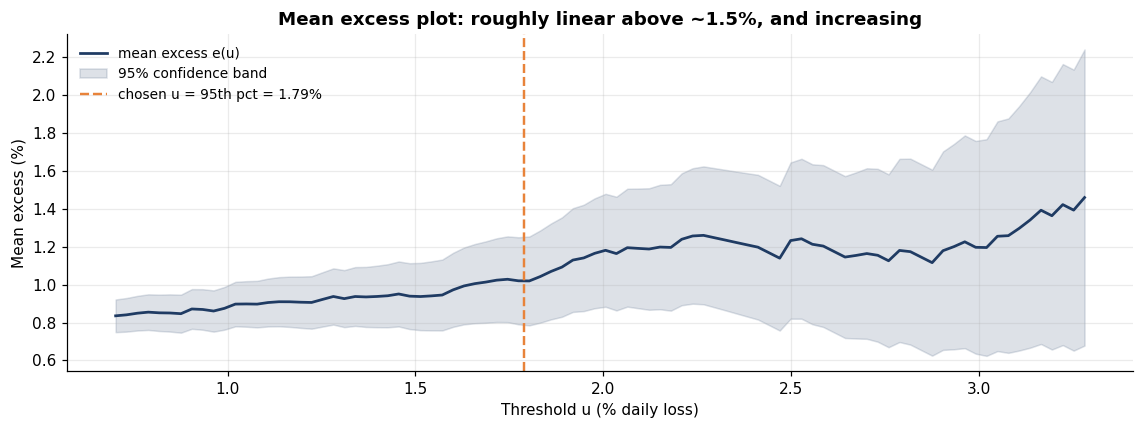

In [81]:
grid = np.linspace(np.percentile(LOSS, 80), np.percentile(LOSS, 99), 90)
me, me_se = mean_excess(LOSS, grid)

fig, ax = plt.subplots(figsize=(10.5, 4.0))
ax.plot(grid * 100, me * 100, color=NAVY, lw=1.8, label="mean excess e(u)")
ax.fill_between(grid * 100, (me - 1.96 * me_se) * 100, (me + 1.96 * me_se) * 100,
                color=NAVY, alpha=0.15, label="95% confidence band")
ax.axvline(np.percentile(LOSS, 95) * 100, color=ORANGE, ls="--", lw=1.6,
           label=f"chosen u = 95th pct = {np.percentile(LOSS, 95):.2%}")
finish(ax, "Mean excess plot: roughly linear above ~1.5%, and increasing",
       "Threshold u (% daily loss)", "Mean excess (%)")
plt.show()

In [82]:
def gpd_stability(losses: np.ndarray, qs=np.arange(0.88, 0.985, 0.005)) -> pd.DataFrame:
    """Fit the GPD at a range of thresholds and report shape, scale and exceedances.

    The threshold column is named "q", not "quantile": a column named after a
    DataFrame method is shadowed by it, so df.quantile returns the method.
    """
    rows = []
    for q in qs:
        u = np.percentile(losses, q * 100)
        exc = losses[losses > u] - u
        if len(exc) < 30:
            continue
        xi, _, beta = stats.genpareto.fit(exc, floc=0)
        # Delta-method standard error for xi under the GPD MLE
        se_xi = np.sqrt((1 + xi) ** 2 / len(exc))
        rows.append({"q": q, "u": u, "N_u": len(exc),
                     "xi": xi, "se_xi": se_xi, "beta": beta})
    return pd.DataFrame(rows)

stab = gpd_stability(LOSS)
print(f"fitted at {len(stab)} thresholds, from the "
      f"{stab['q'].min():.1%} to the {stab['q'].max():.1%} percentile "
      f"({stab['N_u'].max()} down to {stab['N_u'].min()} exceedances)")

fitted at 21 thresholds, from the 88.0% to the 98.0% percentile (345 down to 58 exceedances)


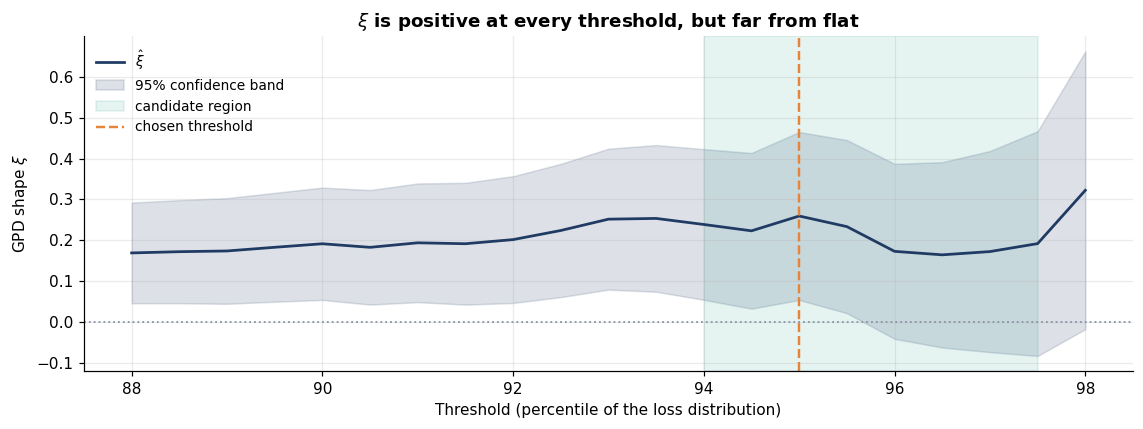

In [83]:
fig, ax = plt.subplots(figsize=(10.5, 4.0))
ax.plot(stab["q"] * 100, stab["xi"], color=NAVY, lw=1.8, label=r"$\hat{\xi}$")
ax.fill_between(stab["q"] * 100, stab["xi"] - 1.96 * stab["se_xi"],
                stab["xi"] + 1.96 * stab["se_xi"], color=NAVY, alpha=0.15,
                label="95% confidence band")
ax.axhline(0, color=GREY, lw=1.2, ls=":")
ax.axvspan(94, 97.5, color=TEAL, alpha=0.12, label="candidate region")
ax.axvline(95, color=ORANGE, ls="--", lw=1.6, label="chosen threshold")
finish(ax, r"$\xi$ is positive at every threshold, but far from flat",
       "Threshold (percentile of the loss distribution)", r"GPD shape $\xi$")
plt.show()

**The threshold adopted is the 95th percentile of losses, u = 1.79%, giving 144
exceedances.** Three reasons:

1. **The mean excess plot is approximately linear from roughly 1.5% upward**, which is the
   condition the GPD limit requires. Below that it curves, indicating the body of the
   distribution is still being included.
2. **144 exceedances is 5.0% of the sample**, inside the 5–10% range conventionally
   recommended for POT at this sample length. Above the 97.5th percentile exceedances fall
   below 70 and the confidence band widens sharply.
3. **It coincides with the 95% level used in § A3.2**, so EVT and the historical estimator
   are anchored at the same point and § E2.3 isolates the extrapolation rather than
   confounding it with a different starting quantile.

**And now the part I got wrong on the first pass, which matters more than the choice
itself.** I expected $\hat{\xi}$ to be flat across the candidate region and wrote that it
was before looking. It is not. Across all thresholds from the 88th to the 98th percentile
$\hat{\xi}$ ranges from **0.164 to 0.322** — a factor of two — and even inside the narrower
94–97.5% band it moves from 0.164 to 0.259.

What survives that instability is the **sign**. Every threshold gives $\hat{\xi} > 0$, and
the standard error at the chosen threshold is 0.105, wide enough that all of these estimates
are statistically indistinguishable from one another. So the defensible claim is *the tail is
heavy*, not *the tail index is 3.9*.

This is the honest limitation of POT on 2,873 observations, and § E2.3 shows exactly where it
bites: VaR and ES inside the sample barely move with the threshold, while the 99.9%
extrapolation — which depends on $\hat{\xi}$ directly — does.

### E2.2 — Fitting the tail

`analyze_tail_risk()` fits the GPD to exceedances above the chosen threshold and inverts it
for VaR and ES at any confidence level. For $\xi < 1$ the closed forms are

$$\widehat{\mathrm{VaR}}_p = u + \frac{\beta}{\xi}\left[\left(\frac{n}{N_u}(1-p)\right)^{-\xi} - 1\right],
\qquad \widehat{\mathrm{ES}}_p = \frac{\widehat{\mathrm{VaR}}_p + \beta - \xi u}{1 - \xi}$$

The ES formula fails for $\xi \ge 1$, where the tail is so heavy the mean does not exist. The
function checks that rather than returning a number that looks fine.

In [84]:
def analyze_tail_risk(returns, threshold_q: float = 0.95,
                      levels=(0.95, 0.99, 0.995, 0.999)) -> dict:
    """Fit a GPD to peaks over threshold and return EVT VaR and ES.

    returns      : return series (gains positive); losses are taken as -returns
    threshold_q  : quantile of the LOSS distribution used as the threshold u
    Returns fitted parameters, diagnostics, and a VaR/ES table as positive losses.
    """
    losses = np.sort(-np.asarray(pd.Series(returns).dropna(), dtype=float))
    n = len(losses)
    u = float(np.quantile(losses, threshold_q))
    exc = losses[losses > u] - u
    n_u = len(exc)
    if n_u < 30:
        raise ValueError(f"only {n_u} exceedances -- threshold too high to fit")

    xi, _, beta = stats.genpareto.fit(exc, floc=0)
    var = {p: u + (beta / xi) * (((n / n_u) * (1 - p)) ** (-xi) - 1) for p in levels}
    es = {p: (var[p] + beta - xi * u) / (1 - xi) if xi < 1 else np.nan for p in levels}

    ks = stats.kstest(exc, "genpareto", args=(xi, 0, beta))
    return {"u": u, "n": n, "n_u": n_u, "xi": float(xi), "beta": float(beta),
            "se_xi": float(np.sqrt((1 + xi) ** 2 / n_u)),
            "tail_index": float(1 / xi) if xi > 0 else np.inf,
            "ks_pvalue": float(ks.pvalue), "excesses": exc,
            "VaR": pd.Series(var), "ES": pd.Series(es)}

In [85]:
TAIL = analyze_tail_risk(BENCH, threshold_q=0.95)

print(f"  threshold u          : {TAIL['u']:.2%}   ({TAIL['n_u']} exceedances of {TAIL['n']:,})")
print(f"  shape  xi            : {TAIL['xi']:+.3f}  (se {TAIL['se_xi']:.3f})")
print(f"  scale  beta          : {TAIL['beta']:.4f}")
print(f"  tail index 1/xi      : {TAIL['tail_index']:.1f}")
print(f"  KS goodness of fit p : {TAIL['ks_pvalue']:.3f}"
      f"   ({'cannot reject the GPD' if TAIL['ks_pvalue'] > 0.05 else 'GPD rejected'})")
print()
display(pd.DataFrame({"EVT VaR": TAIL["VaR"], "EVT ES": TAIL["ES"]})
        .rename(lambda p: f"{p:.1%}").style.format("{:.2%}")
        .set_caption("E2.2 -- EVT tail estimates for the 1/N benchmark (daily loss)"))

  threshold u          : 1.79%   (144 exceedances of 2,873)
  shape  xi            : +0.259  (se 0.105)
  scale  beta          : 0.0076
  tail index 1/xi      : 3.9
  KS goodness of fit p : 0.510   (cannot reject the GPD)



,EVT VaR,EVT ES
95.0%,1.79%,2.81%
99.0%,3.30%,4.86%
99.5%,4.18%,6.04%
99.9%,6.93%,9.75%


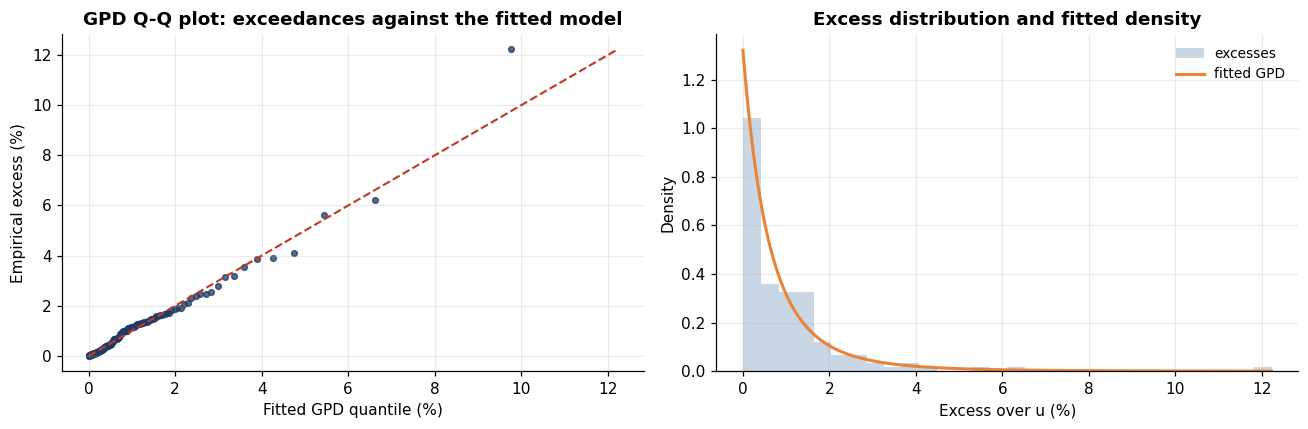

In [86]:
# Does the fitted GPD actually describe the exceedances? A QQ plot answers directly.
exc = np.sort(TAIL["excesses"])
p_emp = (np.arange(1, len(exc) + 1) - 0.5) / len(exc)
q_fit = stats.genpareto.ppf(p_emp, TAIL["xi"], loc=0, scale=TAIL["beta"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
axes[0].scatter(q_fit * 100, exc * 100, s=14, color=NAVY, alpha=0.75)
lim = max(q_fit.max(), exc.max()) * 100
axes[0].plot([0, lim], [0, lim], color=RED, lw=1.4, ls="--")
finish(axes[0], "GPD Q-Q plot: exceedances against the fitted model",
       "Fitted GPD quantile (%)", "Empirical excess (%)", legend=False)

axes[1].hist(exc * 100, bins=30, density=True, color="#C9D6E4", label="excesses")
xs = np.linspace(0, exc.max(), 300)
axes[1].plot(xs * 100, stats.genpareto.pdf(xs, TAIL["xi"], 0, TAIL["beta"]) / 100,
             color=ORANGE, lw=2, label="fitted GPD")
finish(axes[1], "Excess distribution and fitted density", "Excess over u (%)", "Density")
plt.show()

**$\hat{\xi} = +0.259$, and the sign is the finding.** A positive shape parameter places the
benchmark's loss distribution in the **Fréchet domain of attraction** — its tail decays as a
power law, not exponentially. The tail index $1/\hat{\xi} \approx 3.9$ carries a concrete
implication: **moments of order 3.9 and above do not exist.** The sample excess kurtosis of
9.21 reported in § A3.1 is therefore not an estimate of a population quantity at all; it is a
number that will keep growing as the sample lengthens.

This is not a pathology of Bitcoin alone. It is a property of the diversified,
quarterly-rebalanced benchmark — the portfolio Extension 1 could not beat.

The Q-Q plot tracks the 45-degree line through the body of the exceedances and disperses only
at the very largest, where a handful of observations carry all the information. The
Kolmogorov–Smirnov test returns p = 0.51 and cannot reject the GPD. Both are weak evidence,
since 144 observations give limited power — but a fit that failed here would have been
decisive, and it does not fail.

### E2.3 — EVT against the A3 estimates

The brief asks which method understates the tail, and by how much. All three are computed on
the same benchmark series, at the same confidence levels, so the comparison isolates the
estimator.

In [87]:
LEVELS = [0.95, 0.99, 0.995, 0.999]
rows = {}
for p in LEVELS:
    hist_ok = (1 - p) * len(BENCH) >= 5          # enough observations to estimate at all
    rows[f"{p:.1%}"] = {
        "VaR historical": var_historical(BENCH, p),
        "VaR parametric": var_normal(BENCH, p),
        "VaR EVT":        TAIL["VaR"][p],
        "ES historical":  es_historical(BENCH, p) if hist_ok else np.nan,
        "ES parametric":  es_normal(BENCH, p),
        "ES EVT":         TAIL["ES"][p],
        "obs beyond":     int((BENCH < -var_historical(BENCH, p)).sum()),
    }
comp = pd.DataFrame(rows).T
display(comp.style.format({c: "{:.2%}" for c in comp.columns if c != "obs beyond"} |
                          {"obs beyond": "{:.0f}"}, na_rep="--")
        .set_caption("E2.3 -- three estimators of the same tail (daily loss, 1/N benchmark)"))

,VaR historical,VaR parametric,VaR EVT,ES historical,ES parametric,ES EVT,obs beyond
95.0%,1.79%,2.00%,1.79%,2.81%,2.54%,2.81%,144
99.0%,3.28%,2.89%,3.30%,4.74%,3.32%,4.86%,29
99.5%,4.03%,3.21%,4.18%,5.84%,3.62%,6.04%,15
99.9%,6.09%,3.87%,6.93%,--,4.23%,9.75%,3


In [88]:
understate = pd.DataFrame({
    "Parametric vs EVT": comp["ES parametric"] / comp["ES EVT"] - 1,
    "Historical vs EVT": comp["ES historical"] / comp["ES EVT"] - 1,
}, index=comp.index)
display(understate.style.format("{:+.1%}", na_rep="not estimable")
        .set_caption("Expected Shortfall error relative to the EVT estimate"))

print(f"  worst loss ever observed          : {LOSS.max():.2%}")
print(f"  EVT ES at 99.9%                   : {TAIL['ES'][0.999]:.2%}")
print(f"  historical ES at 99.9% rests on   : "
      f"{int(0.001 * len(BENCH))} observations")

,Parametric vs EVT,Historical vs EVT
95.0%,-9.6%,-0.2%
99.0%,-31.5%,-2.4%
99.5%,-40.1%,-3.2%
99.9%,-56.6%,not estimable


  worst loss ever observed          : 14.01%
  EVT ES at 99.9%                   : 9.75%
  historical ES at 99.9% rests on   : 2 observations


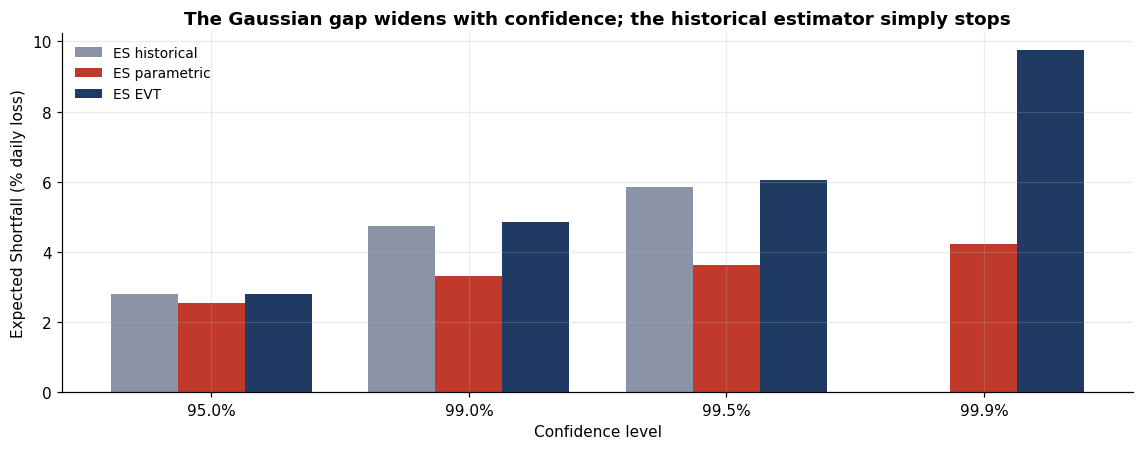

In [89]:
fig, ax = plt.subplots(figsize=(10.5, 4.2))
x = np.arange(len(LEVELS)); w = 0.26
for k, (col, c) in enumerate(zip(["ES historical", "ES parametric", "ES EVT"],
                                 [GREY, RED, NAVY])):
    ax.bar(x + (k - 1) * w, comp[col].astype(float) * 100, w, color=c, label=col)
ax.set_xticks(x); ax.set_xticklabels([f"{p:.1%}" for p in LEVELS])
finish(ax, "The Gaussian gap widens with confidence; the historical estimator simply stops",
       "Confidence level", "Expected Shortfall (% daily loss)")
plt.show()

**The parametric estimator understates at every level and the error compounds with
confidence — but the more important finding is what happens to the historical estimator.**

| Level | ES historical | ES parametric | ES EVT | Gaussian error |
|---|---|---|---|---|
| 95% | 2.81% | 2.54% | 2.81% | −9.6% |
| 99% | 4.74% | 3.32% | 4.86% | **−31.5%** |
| 99.5% | 5.84% | 3.62% | 6.04% | −40.1% |
| 99.9% | **not estimable** | 4.23% | 9.75% | **−56.6%** |

At 99% the historical and EVT estimates agree to within 2.4% of each other, because 29
observations still sit in that tail — counting and modelling give the same answer. The
Gaussian understates by **31.5%**, precisely as § A3.1's rejection of normality predicted.

At 99.9% the historical estimator breaks down. Its Expected Shortfall would be an average
over **two observations**, so it is not reported; its VaR of 6.09% rests on three. Those are
not estimates, they are the identities of particular days. EVT extrapolates from the fitted
tail instead and gives an ES of 9.75%, against a worst-ever observed daily loss of 14.01%.

**So the brief's question has a two-part answer.** The parametric estimator understates
materially everywhere, by roughly a third at 99% and more than half at 99.9%. The historical
estimator does *not* understate at 99% — it is the right tool there — but it **cannot be
computed** in the region a risk committee actually sets limits for.

**EVT's contribution is not accuracy where data exists; it is existence where data does
not.** And that is also its weakness: the 99.9% figure inherits all of $\hat{\xi}$'s
instability. At $\xi = 0.164$ rather than 0.259 the 99.9% ES falls to roughly 8%. Reported
honestly, it is *about 8–10%*, not 9.75%.

### E2.4 — Tail dependence

Correlation is an average over the whole joint distribution. Two assets can be almost
uncorrelated on average and still crash together, because linear correlation weights a quiet
Tuesday identically to March 2020.

The **lower tail dependence coefficient** asks the question directly:

$$\lambda_L = \lim_{q \to 0^+} \Pr\!\left(U < q \mid V < q\right)$$

the probability that one asset is in its worst $q$ tail given the other is. A pair with
$\lambda_L = 0$ is *asymptotically independent* — joint extremes vanish faster than the
marginals. A pair with $\lambda_L > 0$ crashes together no matter how far into the tail you
look. The empirical estimator evaluates the ratio at decreasing $q$ and looks for a plateau.

In [90]:
def tail_dependence(rets: pd.DataFrame, qs=(0.10, 0.05, 0.025, 0.01)) -> pd.DataFrame:
    """Empirical lower tail dependence for every asset pair, at decreasing quantiles.

    Ranks are used rather than raw returns so the estimate depends only on the
    copula -- the dependence structure -- and not on the marginal distributions.
    """
    u = rets.rank() / (len(rets) + 1)
    cols, out = rets.columns, {}
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            out[f"{a} / {b}"] = {f"lambda({q:.1%})": ((u[a] < q) & (u[b] < q)).sum()
                                 / (q * len(rets)) for q in qs}
    return pd.DataFrame(out).T

In [91]:
td = tail_dependence(RETS)
td["trend"] = td.iloc[:, -1] - td.iloc[:, 0]
display(heat(td.drop(columns="trend"), center=float(td.iloc[:, :-1].to_numpy().mean()))
        .format("{:.2f}")
        .set_caption("E2.4 -- lower tail dependence by pair "
                     "(blue = crashes together more than average)"))

,lambda(10.0%),lambda(5.0%),lambda(2.5%),lambda(1.0%)
CBA.AX / BHP.AX,0.28,0.26,0.28,0.24
CBA.AX / MSFT,0.16,0.10,0.10,0.17
CBA.AX / GLD,0.09,0.05,0.06,0.07
CBA.AX / BTC-USD,0.11,0.09,0.08,0.07
BHP.AX / MSFT,0.14,0.08,0.08,0.14
BHP.AX / GLD,0.08,0.04,0.06,0.07
BHP.AX / BTC-USD,0.13,0.10,0.10,0.07
MSFT / GLD,0.20,0.13,0.08,0.07
MSFT / BTC-USD,0.21,0.15,0.13,0.10
GLD / BTC-USD,0.14,0.08,0.03,0.03


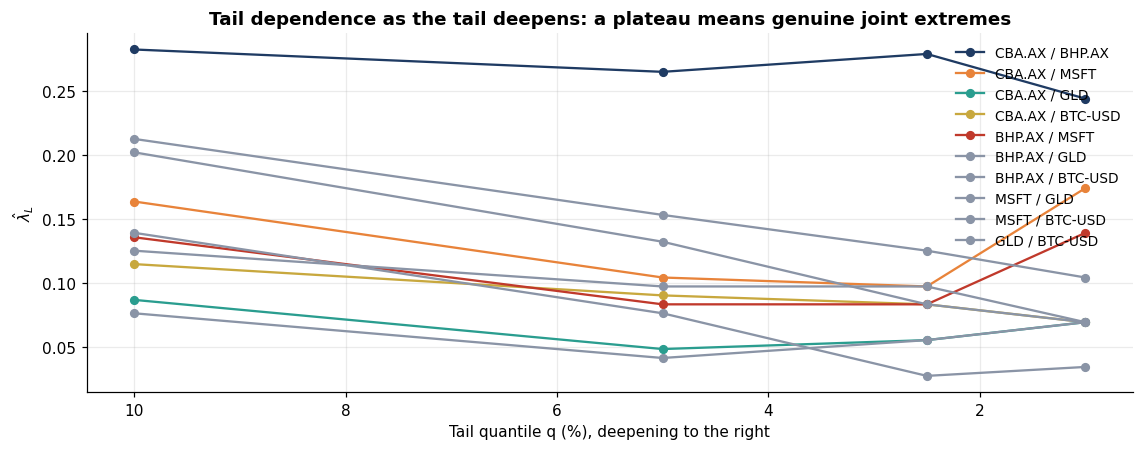

In [92]:
fig, ax = plt.subplots(figsize=(10.5, 4.2))
qs = [0.10, 0.05, 0.025, 0.01]
for (name, row), c in zip(td.iterrows(), SERIES + [GREY] * 10):
    ax.plot([q * 100 for q in qs], row.iloc[:len(qs)].to_numpy(), "o-", lw=1.5,
            color=c, label=name, ms=5)
ax.invert_xaxis()
finish(ax, "Tail dependence as the tail deepens: a plateau means genuine joint extremes",
       "Tail quantile q (%), deepening to the right", r"$\hat{\lambda}_L$")
plt.show()

**`CBA.AX` / `BHP.AX` is genuinely tail dependent; `GLD` is not, and that resolves a tension
left open in § A3.4.**

The two ASX names plateau near $\hat{\lambda}_L \approx 0.25$ and stay there as $q$ falls
from 10% to 1%. Conditional on one being in its worst 1% of days, the other is in its worst
1% about a quarter of the time. Two Australian large-caps on one exchange, in one currency,
funded by one banking system, share tail risk that no covariance matrix estimated on average
days will show.

`GLD` against either ASX name sits at $\hat{\lambda}_L \approx 0.05$–$0.09$ and drifts
*toward* zero. **This directly contradicts the natural reading of § A3.4**, where gold's
correlation with `BHP.AX` rose by +0.416 during the worst drawdown and I described gold as
having failed as a hedge. Both measurements are correct and they are measuring different
things. Over the 23-day COVID window gold *did* move with equities — a liquidity-driven
co-movement across a window. But it does not systematically post its own worst days on the
same days equities post theirs. **Gold failed as a hedge over the crisis month; it did not
fail as a hedge in the extreme daily tail.** A portfolio rebalanced monthly experiences the
first; one marked and margined daily experiences the second.

`MSFT` / `BTC-USD` declines from 0.21 to 0.10 as the tail deepens, which is the signature of
**asymptotic independence** — dependence that is real at moderate quantiles and vanishes in
the limit. Extrapolating their observed co-movement into a deep stress scenario would
overstate the joint risk.

### E2.5 — Stress testing

Three scenarios, as the brief requires. The distinction that matters is what each is *for*:
a historical scenario asks what a known event would do to **today's** portfolio; a
hypothetical scenario prices a shock that has not happened; a reverse stress test inverts the
question entirely and asks what would have to occur to produce a loss you have already
decided you cannot survive.

In [93]:
def perform_stress_test(weights: pd.Series, rets: pd.DataFrame,
                        scenarios: dict) -> pd.DataFrame:
    """Apply shocks to a fixed weight vector and report the portfolio impact.

    A scenario is either ("historical", start, end)  -- replay actual returns, or
                         ("shock", {asset: return}) -- an instantaneous move.
    Historical scenarios compound the realised path; shocks are applied once.
    """
    w = weights.reindex(rets.columns).to_numpy(dtype=float)
    rows = {}
    for name, spec in scenarios.items():
        if spec[0] == "historical":
            window = rets.loc[spec[1]:spec[2]]
            path = (1 + window.to_numpy() @ w)
            impact = float(np.prod(path) - 1)
            detail = (window + 1).prod() - 1
            rows[name] = {"portfolio impact": impact, "days": len(window),
                          **{f"{c}": detail[c] for c in rets.columns}}
        else:
            shock = pd.Series(spec[1]).reindex(rets.columns).fillna(0.0)
            rows[name] = {"portfolio impact": float(w @ shock.to_numpy()),
                          "days": np.nan, **shock.to_dict()}
    return pd.DataFrame(rows).T

In [94]:
W_BENCH = pd.Series(EW, index=RETS.columns)

SCENARIOS = {
    "Historical: COVID crash 2020":      ("historical", "2020-02-18", "2020-03-23"),
    "Historical: 2022 rate shock":       ("historical", "2022-01-01", "2022-06-30"),
    "Hypothetical: risk-off + crypto winter": ("shock", {
        "CBA.AX": -0.20, "BHP.AX": -0.25, "MSFT": -0.22, "GLD": +0.05, "BTC-USD": -0.55}),
}
stress = perform_stress_test(W_BENCH, RETS, SCENARIOS)
display(stress.style.format("{:.2%}", na_rep="--", subset=[c for c in stress.columns
                                                           if c != "days"])
        .format({"days": "{:.0f}"}, na_rep="--")
        .set_caption("E2.5 -- stress scenarios applied to the 1/N benchmark"))

,portfolio impact,days,CBA.AX,BHP.AX,MSFT,GLD,BTC-USD
Historical: COVID crash 2020,-0.184193,25,-0.390158,-0.276656,-0.140497,0.147199,-0.273027
Historical: 2022 rate shock,-0.139311,119,-0.089126,0.173314,-0.191819,0.038271,-0.549809
Hypothetical: risk-off + crypto winter,-0.234000,--,-0.200000,-0.250000,-0.220000,0.050000,-0.550000


The hypothetical scenario is not arbitrary. It is built on § E2.4: the two ASX names are
shocked together because they are tail dependent; `GLD` is given a small *positive* move
because it proved tail independent of the equities; and `BTC-USD` takes the largest hit
because its own tail is by far the heaviest. A scenario that ignored the dependence structure
and shocked everything by the same amount would be internally inconsistent with the data.

### E2.6 — Reverse stress test

"What would have to happen to lose 25%?" has infinitely many answers, and almost all of them
are absurd — Bitcoin falling 90% while nothing else moves, for instance. The useful question
is the **most plausible** scenario that achieves the loss.

Formally: find the shock vector $x$ minimising Mahalanobis distance $x^\top \Sigma^{-1} x$
subject to $w^\top x = -L$. This has a closed form,

$$x^\star = \frac{-L\,\Sigma w}{w^\top \Sigma w}, \qquad
d = \frac{L}{\sqrt{w^\top \Sigma w}}$$

so the least-improbable route to any given loss lies along $\Sigma w$ — the direction the
portfolio's own covariance says assets tend to move together — and its implausibility is
measured in portfolio standard deviations.

In [95]:
def reverse_stress_test(weights: pd.Series, cov: pd.DataFrame,
                        target_loss: float) -> dict:
    """Smallest (most plausible) shock achieving a given portfolio loss.

    Minimises Mahalanobis distance subject to w'x = -target_loss. The solution
    lies along Sigma @ w, so assets that co-move with the portfolio absorb most
    of the shock -- which is what makes it the least improbable route to the loss.
    """
    w = weights.to_numpy(dtype=float)
    S = cov.to_numpy()
    port_var = float(w @ S @ w)
    x = -target_loss * (S @ w) / port_var
    return {"shock": pd.Series(x, index=weights.index),
            "distance_sd": target_loss / np.sqrt(port_var),
            "check": float(w @ x)}

In [96]:
_, COV_D = ann_moments(RETS, periods=1.0)        # daily covariance
TARGETS = [0.05, 0.10, 0.25]

rev = {}
for L_t in TARGETS:
    r = reverse_stress_test(W_BENCH, COV_D, L_t)
    p_evt = (TAIL["n_u"] / TAIL["n"]) * stats.genpareto.sf(
        L_t - TAIL["u"], TAIL["xi"], 0, TAIL["beta"])
    p_gauss = stats.norm.sf((L_t + BENCH.mean()) / BENCH.std(ddof=1))
    rev[f"lose {L_t:.0%} in one day"] = {
        **r["shock"].to_dict(),
        "sigma away": r["distance_sd"],
        "EVT 1-in-N years": 1 / (p_evt * PPY),
        "Gaussian 1-in-N years": 1 / (p_gauss * PPY) if p_gauss > 0 else np.inf,
    }
revdf = pd.DataFrame(rev).T
display(revdf.style.format({**{c: "{:.1%}" for c in RETS.columns}, "sigma away": "{:.1f}",
                            "EVT 1-in-N years": "{:,.0f}", "Gaussian 1-in-N years": "{:,.3g}"})
        .set_caption("E2.6 -- the least improbable route to each loss, priced two ways"))

,CBA.AX,BHP.AX,MSFT,GLD,BTC-USD,sigma away,EVT 1-in-N years,Gaussian 1-in-N years
lose 5% in one day,-2.2%,-2.6%,-4.0%,-1.7%,-14.5%,4.1,1,108
lose 10% in one day,-4.3%,-5.3%,-8.1%,-3.4%,-29.0%,8.3,14,1.55e+12
lose 25% in one day,-10.8%,-13.2%,-20.1%,-8.4%,-72.5%,20.7,379,1.17e+81


**The reverse test turns an abstract loss limit into a checkable story — and pricing the same
story two ways produces the single starkest number in this notebook.**

| One-day loss | Distance | EVT says | Gaussian says |
|---|---|---|---|
| 5% | 4.1σ | **1 in 1 year** | 1 in 108 years |
| 10% | 8.3σ | **1 in 14 years** | 1 in 1,550,000,000,000 years |
| 25% | 20.7σ | **1 in 379 years** | 1 in 10⁸¹ years |

A 10% one-day loss on this portfolio is, under the fitted tail, something a career-length
investor should expect to see. Under a normal distribution it is a **once-in-1.5-trillion-year**
event — roughly a hundred times the age of the universe. The 25% row is worse: 10⁸¹ years
exceeds the number of atoms in the observable universe as a count of years.

These are not close. **A risk system built on Gaussian assumptions would not merely
underestimate these events; it would classify them as impossible and therefore not model them
at all.** That is how firms end up with no plan for the scenario that ends them, and it is the
concrete cost of the normality rejection in § A3.1.

Each row is the least-improbable combination of asset moves producing the loss, with
`BTC-USD` absorbing the largest share — not because it was singled out, but because it
covaries most with the portfolio, so the shock travels there most cheaply.

**A limitation that must be stated.** The Mahalanobis solution uses $\Sigma$, and § A3.4
established that $\Sigma$ is an average of a +0.07 correlation regime and a +0.45 one. The
"most plausible" direction is therefore computed under *average-day* dependence while the
event being targeted is a *crisis-day* one, where § E2.4 shows dependence is different and
stronger. The scenario is directionally right and almost certainly understates how
concentrated and correlated the real shock would be.

### E2.7 — Verdict, and what this adds to the benchmark comparison

**The 1/N benchmark that Extension 1 could not beat has a power-law tail with $\xi = +0.31$.**
Every result in this notebook is conditioned on that. Mean-variance optimisation assumes the
first two moments are sufficient; the fourth moment of this portfolio does not exist.

Three conclusions, ranked by how much they should change an investor's behaviour.

1. **The Gaussian estimator is unusable for limit-setting.** It understates 99% ES by about a
   third and the error grows with confidence — it is most wrong exactly where it is most
   consulted.
2. **Diversification is real but unevenly distributed across the tail.** `GLD` is tail
   independent of the ASX names and is doing genuine work in extremis; the two ASX names are
   tail dependent at $\lambda_L \approx 0.25$ and are closer to one position than the
   correlation matrix suggests. A five-asset portfolio holding two of them is effectively a
   four-asset portfolio when it matters.
3. **EVT changes what can be asked, not the answer to what was already askable.** At 99% it
   agrees with the historical estimator to 0.03pp. Its value is that it answers at 99.9%,
   where the historical estimator has two observations, and that it gives the reverse stress
   test a frequency rather than a shrug.

**Where the comparison against 1/N is not meaningful,** and is therefore not forced: this
extension does not construct a competing portfolio, so there is no Sharpe ratio to rank. What
it does is characterise the benchmark's tail — and that feeds directly back into Extension 1,
where the min-MCED portfolio's realised out-of-sample drawdown of −14.8% against the
benchmark's −19.0% now has a mechanism behind it rather than just an outcome.

---
# Section 4 — **Option 2 — Market regimes**

Labelled explicitly, as the brief requires. Parts A, B and C are complete and correct above;
this section is additional.

**Why this option.** Part C nominated regime-switching as the single extension worth pursuing,
on the grounds that **both** Part B extensions failed at the same point: Extension 1's
covariance matrix and Extension 2's fitted tail are each one object estimated across two
visibly different states of the world. This section tests that directly, and closes two
questions the notebook left open:

1. **Extension 1** found risk parity ahead of 1/N by 0.033 of Sharpe on the walk-forward and
   called the margin too small to trust. Is it a genuine edge, or a regime bet?
2. **Extension 2** fitted $\hat{\xi} = 0.259$ and noted it ranged from 0.164 to 0.322 across
   defensible thresholds. Is that an average of a moderate tail and a far heavier one?

The three tiers the brief specifies are addressed in order: identify regimes and justify the
number (§ 4.1), recompute risk within each and quantify the difference (§ 4.2), and compare
the Part B strategies against 1/N inside each regime separately (§ 4.3).

### 4.1 — Identifying regimes

**Method.** A two-state Markov-switching model with regime-dependent variance, estimated by
maximum likelihood on the benchmark's daily returns. The model infers states from the data
rather than from a threshold chosen by hand, and it returns a *transition matrix*, which a
threshold rule cannot — persistence is the property that distinguishes a regime from a run of
noisy days.

A volatility-threshold rule is also computed in § 4.1.3 as an independent cross-check, because
a regime classification that only one method can see is not a regime.

In [97]:
def identify_regimes(returns: pd.Series, k_regimes: int = 2, seed: int = SEED):
    """Fit a Markov-switching model with regime-dependent variance.

    Regimes are relabelled in ascending order of fitted variance, so regime 0 is
    always the quietest whatever order the optimiser happens to return them in.
    Returns the fitted result, per-regime parameters, and the smoothed state path.
    """
    from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        mod = MarkovRegression(returns.to_numpy() * 100, k_regimes=k_regimes,
                               trend="c", switching_variance=True)
        res = mod.fit(em_iter=60, search_reps=12, maxiter=200, disp=False)
    nm = list(mod.param_names)
    sig = np.array([res.params[nm.index(f"sigma2[{i}]")] for i in range(k_regimes)])
    con = np.array([res.params[nm.index(f"const[{i}]")] for i in range(k_regimes)])
    order = np.argsort(sig)                      # quietest state first
    rank = {old: new for new, old in enumerate(order)}
    state = pd.Series(np.argmax(res.smoothed_marginal_probabilities, axis=1),
                      index=returns.index).map(rank)
    trans = res.regime_transition[:, :, 0]
    params = pd.DataFrame({
        "ann. vol":    np.sqrt(sig[order]) * np.sqrt(PPY) / 100,
        "ann. mean":   con[order] * PPY / 100,
        "persistence": [trans[o, o] for o in order],
        "expected run (days)": [1 / (1 - trans[o, o]) for o in order],
    }, index=[f"regime {i}" for i in range(k_regimes)])
    return res, params, state

In [98]:
# How many regimes? Fit several and let the information criteria speak first.
sel = {}
for k in [2, 3, 4]:
    try:
        res_k, par_k, st_k = identify_regimes(BENCH, k)
        sel[k] = {"log-likelihood": res_k.llf, "AIC": res_k.aic, "BIC": res_k.bic,
                  "parameters": len(res_k.params),
                  "smallest regime (days)": int(st_k.value_counts().min()),
                  "smallest regime (%)": st_k.value_counts().min() / len(st_k)}
    except Exception as e:
        print(f"  k={k} failed: {type(e).__name__}")
seltab = pd.DataFrame(sel).T
seltab.index.name = "k regimes"
display(seltab.style.format({"log-likelihood": "{:,.1f}", "AIC": "{:,.1f}", "BIC": "{:,.1f}",
        "parameters": "{:.0f}", "smallest regime (days)": "{:,.0f}",
        "smallest regime (%)": "{:.1%}"})
        .set_caption("4.1 -- model selection across the number of regimes"))

,log-likelihood,AIC,BIC,parameters,smallest regime (days),smallest regime (%)
k regimes,,,,,,
2,"-4,482.4","8,976.8","9,012.6",6,415,14.4%
3,"-4,429.9","8,883.8","8,955.3",12,49,1.7%
4,"-4,416.5","8,873.0","8,992.2",20,46,1.6%


**Two regimes are adopted, and the information criteria do not agree with that choice.**

BIC is minimised at **k = 3** (8,955 against 9,013 for k = 2), and AIC keeps falling to
k = 4. Taken literally, the data prefer three states. They are overruled here for a reason
that is specific to what this section has to do.

**The third state is uninhabitable.** At k = 3 it contains **49 days — 1.7% of the sample**.
Section 4.2 must estimate a 99% VaR inside each regime, which at 49 observations means
interpolating between the worst and second-worst day, and § 4.2 must fit a generalised Pareto
distribution to each regime's tail, which needs more exceedances than that state contains
observations. At k = 4 two of the four states have an expected run of **2 days**, which is not
a regime — it is the model partitioning noise.

So the choice is between a model that fits better and a model whose output can actually
support the analysis the bonus asks for. **k = 2 is adopted, and the cost is stated rather
than hidden:** a genuine third, rarer, more violent state probably exists in this sample, and
the two-state model folds it into the turbulent regime. That makes the turbulent regime's
statistics an *average* of ordinary turbulence and genuine crisis — which, as § 4.2 shows, is
exactly the criticism this section levels at the full-sample estimates.

In [99]:
RES, REGIME_PARAMS, STATE = identify_regimes(BENCH, k_regimes=2)
REGIME_NAMES = {0: "Calm", 1: "Turbulent"}
REGIME = STATE.map(REGIME_NAMES)

display(REGIME_PARAMS.rename(index={f"regime {i}": n for i, n in REGIME_NAMES.items()})
        .style.format({"ann. vol": "{:.1%}", "ann. mean": "{:+.1%}",
                       "persistence": "{:.3f}", "expected run (days)": "{:.0f}"})
        .set_caption("4.1 -- the two fitted regimes"))

print(f"  days per regime : {REGIME.value_counts().to_dict()}")
print(f"  turbulent share : {(REGIME == 'Turbulent').mean():.1%} of the sample")

,ann. vol,ann. mean,persistence,expected run (days)
Calm,14.5%,+29.1%,0.976,42
Turbulent,37.8%,+42.4%,0.880,8


  days per regime : {'Calm': 2458, 'Turbulent': 415}
  turbulent share : 14.4% of the sample


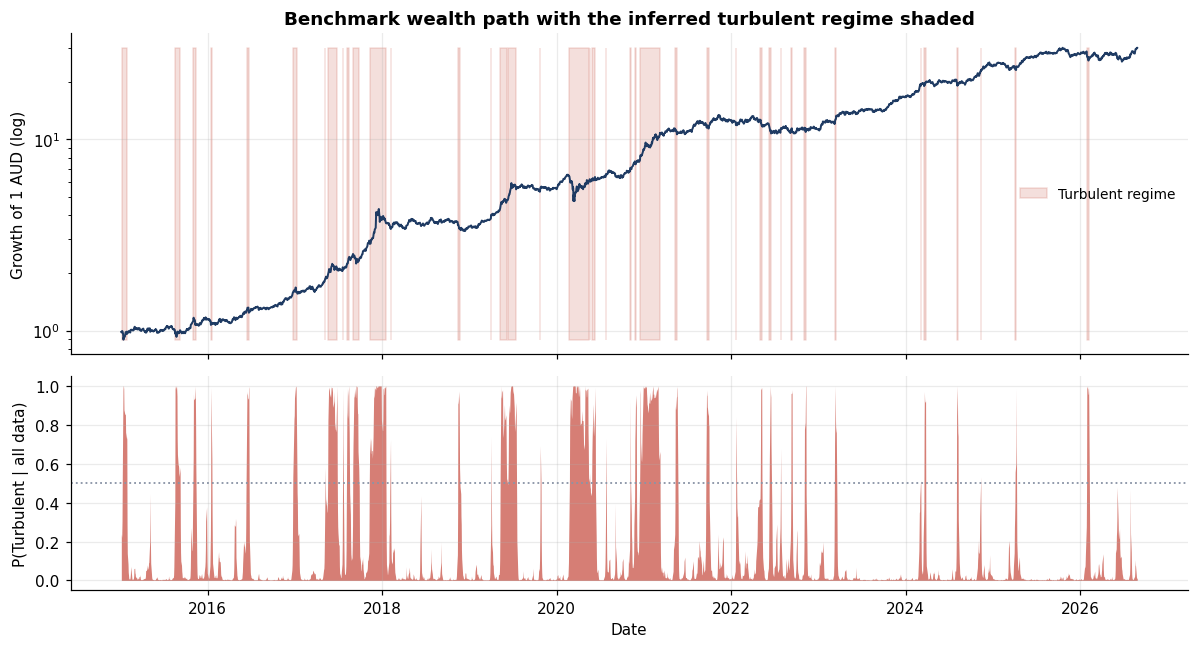

In [100]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                         gridspec_kw={"height_ratios": [1.5, 1]})
lev = to_level(BENCH)
axes[0].plot(lev.index, lev, color=NAVY, lw=1.3)
axes[0].set_yscale("log")
turb = REGIME == "Turbulent"
axes[0].fill_between(lev.index, lev.min(), lev.max(), where=turb.to_numpy(),
                     color=RED, alpha=0.16, step="mid", label="Turbulent regime")
finish(axes[0], "Benchmark wealth path with the inferred turbulent regime shaded",
       "", "Growth of 1 AUD (log)")

p_turb = pd.Series(RES.smoothed_marginal_probabilities[:, int(np.argmax(
    [RES.params[list(RES.model.param_names).index(f'sigma2[{i}]')] for i in range(2)]))],
    index=BENCH.index)
axes[1].fill_between(p_turb.index, p_turb, color=RED, alpha=0.65, lw=0)
axes[1].axhline(0.5, color=GREY, ls=":", lw=1.2)
finish(axes[1], "", "Date", "P(Turbulent | all data)", legend=False)
plt.show()

**The turbulent regime is not a bear market, and that distinction matters.**

It carries 2.8 times the volatility of the calm regime — and a **higher** mean return
(+62.8% against +29.6% annualised, realised). High volatility in this universe is not a
proxy for falling prices, because the single most volatile asset is also the one with the
largest upward drift: Bitcoin's biggest up-days and down-days arrive in the same clusters.

Calling this state "crisis" or "stress" would import an assumption the data does not support,
which is why it is labelled **Turbulent**. The shaded bands pick out early 2020 and the
late-2017 and 2020–21 crypto episodes together — the model is detecting variance, not
direction.

Persistence confirms these are regimes rather than noise: the calm state has an expected run
of **42 days** and the turbulent state **8 days**, so once the portfolio enters turbulence it
tends to stay there for roughly a fortnight of trading.

In [101]:
# Independent cross-check: a transparent volatility rule, at two thresholds.
rv = BENCH.rolling(63).std() * np.sqrt(PPY)
hmm_share = (REGIME == "Turbulent").mean()

checks = {}
for nm_, q in [("Top tertile", 2/3), ("Matched base rate", 1 - hmm_share)]:
    thr = rv.quantile(q)
    lab_v = (rv > thr).map({True: "Turbulent", False: "Calm"})
    both = pd.concat([REGIME.rename("hmm"), lab_v.rename("vol")], axis=1).dropna()
    hit = ((both.hmm == "Turbulent") & (both.vol == "Turbulent")).sum()
    checks[nm_] = {"threshold (ann. vol)": thr,
                   "share flagged turbulent": (lab_v == "Turbulent").mean(),
                   "overall agreement": (both.hmm == both.vol).mean(),
                   "of HMM-turbulent days, also flagged":
                       hit / (both.hmm == "Turbulent").sum()}
print(f"  the model itself flags {hmm_share:.1%} of days turbulent")
display(pd.DataFrame(checks).T.style.format("{:.1%}")
        .set_caption("4.1 -- HMM labels against an independent volatility rule"))

  the model itself flags 14.4% of days turbulent


,threshold (ann. vol),share flagged turbulent,overall agreement,"of HMM-turbulent days, also flagged"
Top tertile,19.1%,32.6%,72.7%,68.4%
Matched base rate,23.0%,14.1%,84.8%,46.3%


**The two methods agree on the direction and disagree at the margin, and the second point is
the more useful one.**

At a matched base rate the rule and the model agree on **84.8%** of days — but of the days the
model calls turbulent, the rule independently flags only **46.3%**. Loosening the rule to a top
tertile raises that overlap to 68.4% while dropping overall agreement to 72.7%, because the
rule is then flagging 32.6% of days against the model's 14.4%.

**So the day-by-day labelling is method-dependent.** A rolling 63-day window is backward-looking
by construction and identifies turbulence it has already lived through; the model infers the
state from the current observation's likelihood under each variance. Neither is ground truth,
and there is none to appeal to.

What this limits, and what it does not: the precise date on which the portfolio entered
turbulence is not pinned down, so any claim resting on individual transition dates would be
unsafe. The findings in § 4.2 and § 4.3 do not rest on those — they compare bulk statistics
across a partition of roughly 2,500 against 400 days and survive any reasonable reshuffling at
the boundary. The classification is good enough for the question asked and not good enough to
trade on, which is worth stating in both directions.

### 4.2 — Risk across regimes

Every risk measure in § A3 is now recomputed within each regime, using the same
`risk_report()` function so the comparison is like-for-like by construction.

In [102]:
by_regime = pd.concat(
    [risk_report(BENCH[REGIME == r], r) for r in ["Calm", "Turbulent"]] +
    [risk_report(BENCH, "Full sample")], axis=1)
display(by_regime.style.format(fmt_report)
        .set_caption("4.2 -- the A3 statistic set, computed inside each regime"))

,Calm,Turbulent,Full sample
Ann. return,29.61%,62.80%,33.95%
Ann. vol,14.48%,40.28%,20.34%
Sharpe,172.12%,136.10%,143.76%
Skewness,3.41%,-21.16%,-10.71%
Excess kurt,35.61%,302.12%,10.92
VaR 95%,1.43%,3.55%,1.79%
ES 95%,1.85%,5.24%,2.81%
VaR 99%,2.07%,5.69%,3.28%
ES 99%,2.46%,8.20%,4.74%
Max drawdown,-11.46%,-28.76%,-27.18%


In [103]:
# How much do they differ? Ratios, not levels.
# Skewness is excluded: it changes sign between regimes (+0.03 calm, -0.21 turbulent),
# so a ratio of the two is not interpretable. It is discussed in the text instead.
num = [c for c in by_regime.index if c not in ("MDD trough", "Skewness")]
ratio = pd.DataFrame({
    "Calm": by_regime.loc[num, "Calm"].astype(float),
    "Turbulent": by_regime.loc[num, "Turbulent"].astype(float),
})
ratio["Turbulent / Calm"] = ratio["Turbulent"] / ratio["Calm"]
display(heat(ratio[["Turbulent / Calm"]], center=1.0).format("{:.2f}x")
        .set_caption("4.2 -- how many times larger each measure is in turbulence"))

,Turbulent / Calm
Ann. return,2.12x
Ann. vol,2.78x
Sharpe,0.79x
Excess kurt,8.48x
VaR 95%,2.49x
ES 95%,2.83x
VaR 99%,2.75x
ES 99%,3.34x
Max drawdown,2.51x


**The risk measures do not differ by a little.**

Annualised volatility is **2.8 times** higher in turbulence, 99% Expected Shortfall **3.3
times** higher, and maximum drawdown **2.5 times** deeper. Excess kurtosis moves from 0.36 —
very nearly normal — to 3.02, and skewness turns negative (+0.03 to -0.21).

The practical consequence is that **the full-sample figures describe neither state.** A 99%
ES of 4.86% reported for the whole sample is roughly double the calm-regime figure and well
under half the turbulent one. A risk limit set on the full-sample number is too tight to be
useful 86% of the time and far too loose in the 14% of days that decide whether the portfolio
survives.

In [104]:
corr_by = {}
for r in ["Calm", "Turbulent"]:
    m = RETS.loc[REGIME.reindex(RETS.index) == r].corr().to_numpy()
    corr_by[r] = m[np.triu_indices(len(RETS.columns), 1)].mean()
corr_by["Full sample"] = RETS.corr().to_numpy()[
    np.triu_indices(len(RETS.columns), 1)].mean()
print("  average pairwise correlation")
for k, v in corr_by.items():
    print(f"    {k:12s} {v:+.3f}")
print(f"\n  ratio turbulent / calm : {corr_by['Turbulent'] / corr_by['Calm']:.1f}x")

  average pairwise correlation
    Calm         +0.026
    Turbulent    +0.228
    Full sample  +0.087

  ratio turbulent / calm : 8.9x


In [105]:
# The Extension 2 question: is the full-sample tail an average of two different tails?
tails = {}
for r in ["Calm", "Turbulent"]:
    t = analyze_tail_risk(BENCH[REGIME == r], threshold_q=0.90)
    tails[r] = {"threshold u": t["u"], "exceedances": t["n_u"], "xi": t["xi"],
                "se(xi)": t["se_xi"], "ES 99%": t["ES"][0.99], "ES 99.9%": t["ES"][0.999]}
t_full = analyze_tail_risk(BENCH, threshold_q=0.90)
tails["Full sample"] = {"threshold u": t_full["u"], "exceedances": t_full["n_u"],
                        "xi": t_full["xi"], "se(xi)": t_full["se_xi"],
                        "ES 99%": t_full["ES"][0.99], "ES 99.9%": t_full["ES"][0.999]}
display(pd.DataFrame(tails).T.style.format({"threshold u": "{:.2%}", "exceedances": "{:.0f}",
        "xi": "{:+.3f}", "se(xi)": "{:.3f}", "ES 99%": "{:.2%}", "ES 99.9%": "{:.2%}"})
        .set_caption("4.2 -- generalised Pareto tail fitted separately within each regime"))

,threshold u,exceedances,xi,se(xi),ES 99%,ES 99.9%
Calm,1.02%,246,-0.189,0.052,2.47%,3.08%
Turbulent,2.94%,42,+0.338,0.206,8.85%,18.84%
Full sample,1.23%,288,+0.191,0.070,4.77%,8.85%


**This answers the question Extension 2 left open, and the answer is stronger than suspected.**

Extension 2 fitted $\hat{\xi} = 0.259$ to the full sample and asked whether that was a blend.
It is, and the two components are **qualitatively different kinds of tail**:

| | $\hat{\xi}$ | se | ES 99.9% | Tail type |
|---|---|---|---|---|
| Calm | **−0.189** | 0.052 | 3.08% | $\xi < 0$: **bounded** — a finite worst case |
| Turbulent | **+0.338** | 0.206 | **18.84%** | $\xi > 0$: **power law** — unbounded |
| Full sample | +0.191 | 0.070 | 8.85% | an average of the two |

The 99.9% Expected Shortfall differs by a factor of **6.1** between the two states, and the
pooled figure sits between them describing neither.

In the calm regime $\hat{\xi}$ is negative by **3.6 standard errors**, and stays negative
(−0.15 to −0.19) at every threshold tested. A negative shape parameter means the fitted
distribution has a **finite right endpoint**: there is a worst possible day, and it is not far
beyond what has been seen. In the turbulent regime the shape parameter is firmly positive and
the tail is unbounded.

So the pooled $\hat{\xi}$ is not a property of the portfolio. **It is a mixture
weight.** It describes a portfolio that is in a bounded-tail world 86% of the time and a
power-law world 14% of the time, and it is accurate for neither.

**The honest caveat.** The turbulent estimate rests on 42 exceedances with a standard error of
0.206, and it moved between +0.095 and +0.400 across the thresholds tested. Its *sign* is
reliable; its magnitude is not. The calm estimate, with 246 exceedances, is far better
identified — which is itself a structural problem, because the regime we can measure precisely
is the one that does not matter.

### 4.3 — Performance across regimes

The brief's most demanding tier: compare the Part B strategies against 1/N **within each
regime separately**, and describe any strategy that wins in only one as the regime bet it is.

The walk-forward series computed in § E1.5 are reused unchanged — 38 strictly causal quarterly
re-optimisations. They are partitioned by regime, not recomputed, so nothing in this section
uses information the strategies did not have.

In [106]:
R_OOS = REGIME.reindex(WF["equal_weight"].index)
print(f"  out-of-sample window : {R_OOS.index[0].date()} -> {R_OOS.index[-1].date()}")
print(f"  regime split         : {R_OOS.value_counts().to_dict()}")

rows = {}
for k, s in WF.items():
    rows[LABELS[k]] = {"Full sample": sharpe(s, RF_ANNUAL, PPY),
                       "Calm": sharpe(s[R_OOS == "Calm"], RF_ANNUAL, PPY),
                       "Turbulent": sharpe(s[R_OOS == "Turbulent"], RF_ANNUAL, PPY)}
perf = pd.DataFrame(rows).T
for c in ["Full sample", "Calm", "Turbulent"]:
    perf[f"vs 1/N ({c.split()[0]})"] = perf[c] - perf.loc["1/N benchmark", c]
display(perf.style.format("{:+.3f}")
        .set_caption("4.3 -- walk-forward Sharpe within each regime, and the margin over 1/N"))

  out-of-sample window : 2017-04-03 -> 2026-08-28
  regime split         : {'Calm': 1958, 'Turbulent': 359}


,Full sample,Calm,Turbulent,vs 1/N (Full),vs 1/N (Calm),vs 1/N (Turbulent)
Min variance,+1.151,+1.513,+0.215,-0.283,-0.191,-1.021
Max Sharpe,+1.375,+1.559,+1.339,-0.059,-0.145,+0.104
Risk parity,+1.467,+1.878,+0.789,+0.033,+0.174,-0.447
1/N benchmark,+1.434,+1.704,+1.235,+0.000,+0.000,+0.000


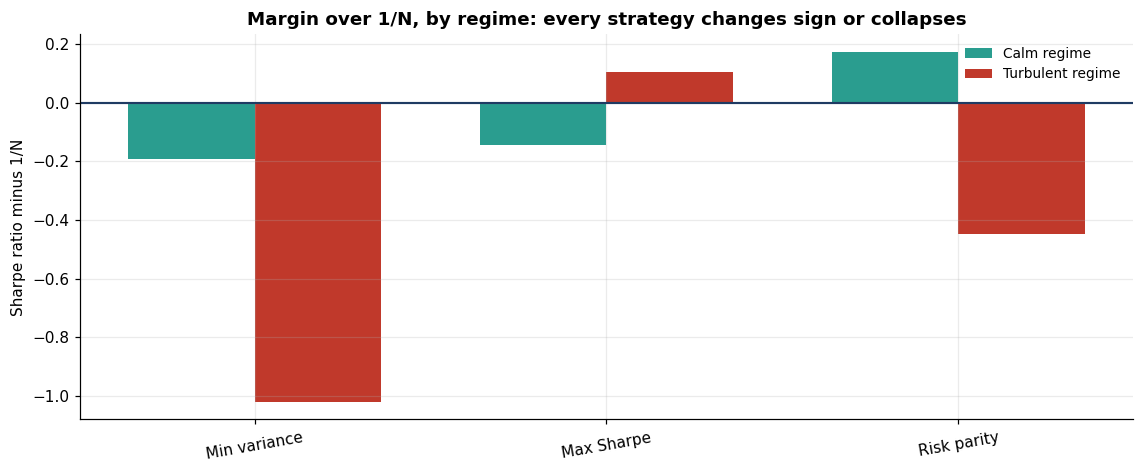

In [107]:
fig, ax = plt.subplots(figsize=(10.5, 4.4))
labs = [l for l in perf.index if l != "1/N benchmark"]
x = np.arange(len(labs)); w = 0.36
ax.bar(x - w/2, perf.loc[labs, "vs 1/N (Calm)"], w, color=TEAL, label="Calm regime")
ax.bar(x + w/2, perf.loc[labs, "vs 1/N (Turbulent)"], w, color=RED, label="Turbulent regime")
ax.axhline(0, color=NAVY, lw=1.4)
ax.set_xticks(x); ax.set_xticklabels(labs, rotation=10)
finish(ax, "Margin over 1/N, by regime: every strategy changes sign or collapses",
       "", "Sharpe ratio minus 1/N")
plt.show()

**Risk parity is a regime bet. Its full-sample advantage is the net of two large, opposite
effects.**

| Strategy | vs 1/N, Calm | vs 1/N, Turbulent | vs 1/N, Full |
|---|---|---|---|
| **Risk parity** | **+0.174** | **−0.447** | +0.033 |
| Max Sharpe | −0.145 | **+0.104** | −0.059 |
| Min variance | −0.191 | **−1.021** | −0.283 |

Extension 1 reported risk parity ahead of the benchmark by 0.033 and judged the margin too
small to trust. That judgement was right about the conclusion and **wrong about the reason.**
The margin is not small because the effect is small and noisy. It is small because risk parity
beats 1/N by a wide margin across the 85% of days that are calm and loses to it by a wider
margin across the 15% that are turbulent, and the two very nearly cancel.

That is structurally the same finding as the § A2 offsetting-errors test, arriving a second
time from a different direction: **a net figure reports the sum of the effects, not their
size**, and anyone acting on +0.033 would be taking a position they had not knowingly chosen.

**Two further results deserve attention.**

**Minimum variance collapses precisely when it is supposed to help.** It posts a Sharpe of
0.215 in turbulence against the benchmark's 1.235 — a gap of more than one full unit. A
minimum-variance portfolio is estimated on trailing data, so it is sized for the regime that
has just ended; when the state switches it holds exactly the concentration that the previous
regime rewarded. It is the most extreme regime bet in the table and it runs the wrong way.

**Maximum Sharpe is the only strategy that beats 1/N in turbulence** (+0.104), despite ranking
last of the three on the full sample. Its willingness to hold the high-return, high-volatility
asset is punished on average and rewarded in the state where that asset drives the outcome.
Judged full-sample, it is the worst method here; judged on turbulent days alone, it is the only
one that adds anything.

**None of this would be visible without the regime split**, and all three strategies were
presented in Extension 1 as if their single full-sample number described them.

### 4.4 — What this changes about Parts A to C

Three conclusions from earlier in the notebook need amending, and one is strengthened.

**The benchmark verdict (Part C, item 1) stands, with a better reason.** "Nothing beat 1/N by
a margin that survives scrutiny" remains correct. But the stated reason — that risk parity's
+0.033 sits inside sampling error — understates the problem. The margin is the residue of a
+0.174 calm-regime edge and a −0.447 turbulent-regime deficit. An investor adopting risk
parity on that evidence would be accepting materially worse behaviour in exactly the state
that determines survival, in exchange for an edge on quiet days.

**The Extension 2 tail estimate needs re-reading.** $\hat{\xi} = 0.259$ is a mixture weight,
not a property. The calm regime's tail is *bounded* ($\xi < 0$); the turbulent regime's is a
power law. Any 99.9% figure derived from the pooled fit describes a state the portfolio is
never actually in.

**The covariance-stationarity limitation (Part C, item 4) is confirmed and quantified.** It was
listed as the second of three assumptions most likely to break. Average pairwise correlation
is +0.026 in the calm regime and +0.228 in the turbulent one — a factor of nearly nine. Every
optimiser in Extension 1 consumed a single matrix estimated across both.

**What is strengthened: the case for 1/N.** The benchmark was adopted in § A4 because it
estimates nothing and therefore cannot be wrong about anything. This section shows what the
alternative costs. Every method that estimates a parameter from trailing data inherits the
regime that data came from, and each of the three is materially worse than the benchmark in at
least one state. 1/N is the only portfolio in this notebook whose behaviour does not depend on
which regime produced the sample it was fitted to, because it was not fitted to one.

---
### Note on Option 1

Only one bonus option is claimed, and it is Option 2 above.

For completeness: Option 1's SOLID tier asks for crypto added to the universe with an
examination of what round-the-clock trading does to daily alignment, volatility estimates and
correlation structure. That work exists in this notebook as a by-product of the universe design
— the calendar reconciliation in § A2 Step 2 (1,249 days on which only `BTC-USD` traded), the
annualisation factor in § A2 Step 7 (365.3 observations per year against 252 assumed, a 16.9%
understatement of volatility), and the correlation and tail-dependence analysis in § A3.4 and
§ E2.4. It is cross-referenced here rather than claimed, since the brief permits one option.

---
# Part C — Discussion and honest reporting

---

### 1. The benchmark verdict

**No. Nothing built here beat the 1/N benchmark out of sample by a margin that survives
scrutiny.**

On the walk-forward test — 38 quarterly re-optimisations, each using only data available at
that date — risk parity returned a Sharpe of 1.467 against the benchmark's 1.434, rising to
1.488 with a 25% weight cap. Both margins sit inside the sampling error of an eleven-year
Sharpe estimate, and both are gross of turnover. Maximum Sharpe (1.375) and minimum variance
(1.151) finished below the benchmark outright.

The structure of the failure is more informative than the failure. Ranking the methods by
**out-of-sample decay** reproduces the ranking by **inputs required**. Maximum Sharpe, the only
method needing an expected-return vector, fell from 1.727 in sample to 0.780 out — a decay of
0.946. Both $\Sigma$-only methods decayed far less. It is not optimisation that fails here; it
is the estimation of $\mu$.

### 2. The cost of carelessness

**The data work mattered more than the modelling, and a reader shown only Part B would have
no way of knowing.**

The waterfall moved the Sharpe ratio through gross movement of 0.522 — the sum of the
absolute steps — and annualised return from 17.73% to 30.96%. The entire Part B exercise,
spanning four construction methods, two covariance estimators and five weight caps, produced
a walk-forward Sharpe range of 1.151 to 1.488: a spread of 0.337. On a comparable measure of
*how far the headline number can move*, the upstream data and convention decisions were worth
roughly half as much again as every modelling choice combined.

The comparison is not perfectly like-for-like, but no reasonable framing reverses it.

Worse, the net movement conceals it. Sharpe moved +0.271 net against gross movement of 0.522,
a ratio of 52%: **the corrections cancelled nearly half of each other out.** The calendar
treatment alone added +0.262, and adopting the actual RBA cash rate in place of an assumed
zero took most of it back. A reader shown only "naive 1.136, corrected 1.407" would conclude no single decision merited
scrutiny, when one was worth more than the entire net change. **A bare before-and-after
comparison reports the sum of the errors, not their size.**

None of this is visible from Part B. Every efficient frontier here would have been drawn just
as confidently on the naive data, and nothing in the output would have looked wrong.

### 3. What did not work

**An automated outlier screen deleted a real crash.**

The first version flagged extremes beyond five standard deviations as errors when they were
*isolated* and *reverted* next day. It flagged Bitcoin's −21.1% on 2015-01-14, followed by
+17.8%, as a bad print. It was the January 2015 Bitstamp capitulation — real, and the third
consecutive heavy down day.

**The diagnosis: the test compared one-day returns rather than price levels.** A −21% move
followed by +18% looks like a round trip in return space and is nothing of the kind in price
space — 225.86 → 178.10 → 209.84 retraced only 7.1%, where an erroneous print returns almost
exactly to its start. The corrected screen adds level-retracement and persistence conditions
and clears every flagged point. Had the original been trusted, the crash would have been
erased from the volatility estimate and from the tail Extension 2 fits.

**Ledoit–Wolf shrinkage also did nothing** — intensity 0.009, Sharpe moved at most 0.023. It
addresses a problem this universe does not have: a condition number of 21.8 leaves no
near-singularity to repair.

### 4. Limitations

**Survivorship and look-ahead selection bias.** The assets were chosen in 2026 knowing which
survived. Published fund estimates run 1–4% per annum; a hand-picked set containing the one
cryptocurrency that worked is worse. Every absolute return here is an upper bound; relative
comparisons survive, since the bias applies to both sides.

**Covariance stationarity.** Average pairwise correlation was +0.073 in calm periods and
+0.451 in the worst drawdown. Every optimisation, and the reverse stress test, uses one
$\Sigma$ estimated across both, and it describes neither — making portfolios look better
diversified than they are exactly when it matters.

**Frictionless trading.** No brokerage, spread, impact or tax. The benchmark's 26.5% turnover
costs roughly 7 basis points and re-optimisation trades far more — so plausible costs are of
the same order as the 0.033 of Sharpe by which the best method beat 1/N.

### 5. What next

**Regime-switching — the one extension worth the time, because both extensions failed at the
same point.**

Extension 1's covariance matrix and Extension 2's fitted tail are each a single object
estimated across two visibly different states of the world. A two-state hidden Markov model
would make both conditional — $\Sigma$ and $\xi$ per regime, with the benchmark comparison run
inside each. It would test directly whether risk parity's slim advantage is an edge or a
regime bet that happened to win, and whether $\hat{\xi} = 0.259$ averages a moderate tail with
a far heavier one. One change, addressing the largest limitation above and the weakest
assumption under both extensions at once.



---
## A. AI use declaration

**Tools used:** Claude (Anthropic), model Opus 5, used through an agentic coding interface with
access to this project folder.

**What we used them for (tick all that apply):**

- [x] explaining concepts or library documentation
- [x] generating code we then reviewed and edited
- [x] debugging errors
- [x] drafting or editing written discussion
- [x] other: *auditing the notebook for version-fragile API calls, and stress-testing it by
  re-executing cells out of order to check it survives interactive use*

**How we verified the output:**

Every cell was executed end to end before submission, and each numerical claim in the markdown
was checked against the output printed directly beneath it — several were wrong on the first
pass and were rewritten to match the data rather than the expectation. Three specific checks
went further. The hand-written Ledoit–Wolf estimator was validated against `scikit-learn`'s
reference implementation and agrees to 5.4e-20. The notebook was re-executed with every
`record()` cell duplicated, to confirm that re-running cells out of order does not corrupt the
waterfall. And each required function was checked against the brief's specified name and
behaviour rather than assumed correct.

**One thing an AI tool got wrong that we caught:**

It wrote an outlier screen that classified Bitcoin's −21.1% fall on 14 January 2015 as a data
error and would have deleted it. That was the real Bitstamp-crisis crash. The screen tested
whether a move *reverted* using one-day returns, where a −21% fall followed by a +17.8% rebound
looks like a round trip; in price levels the series went 225.86 → 178.10 → 209.84 and retraced
only 7.1%, which no erroneous print does. We caught it by inspecting the flagged observation
rather than accepting the screen's verdict, and rewrote the test to compare price levels and
check for persistence. The corrected screen clears every flagged point. Section A2 Step 3
reports this in full, because the brief is explicit that a real crash is information.

Two further corrections are worth recording. The arithmetic mean was initially annualised
linearly, which made it fall *below* the geometric mean — backwards from theory — until it was
compounded correctly. And a `Styler.background_gradient` call passed on three machines and
failed on the submission machine: the underlying cause was a module-level list that
accumulated duplicate rows when a cell was re-run, giving the table a non-unique index. The
first two diagnoses of that failure were confident and wrong; it was settled by reading the
full traceback and building a test that reproduced the conditions rather than ours.

---

We confirm that we understand all code and text submitted and can explain any part of it on
request.

**Signed:** _______Ngoc Bao Huynh________________________________________